# **Experiment No. 4**
## **Complete Exploratory Data Analysis and Visualization of Social Media Data for Business**

### **Company: Nothing**
### **Platforms: Instagram and YouTube**

**Name:** ______________________________  
**Roll No.:** ___________________________  
**Division:** ___________________________  
**Group No.:** __________________________  
**Date of Performance:** ________________  
**Date of Submission:** _________________  
**Score:** ______________________________

---

This Google Colab notebook analyses:

- `synthetic_instagram_posts.csv`
- `synthetic_instagram_comments.csv`
- `synthetic_youtube_videos.csv` or `tested.csv`
- `synthetic_social_media_content.csv`

The files are synthetic educational data representing Nothing's social-media activity, not official company records.

## **Aim**

To perform comprehensive EDA on Nothing's Instagram and YouTube data, assess data quality, understand content and audience behaviour, analyze engagement and text, detect outliers, engineer features, perform statistical analysis, and derive practical business recommendations.

## **Coverage**

1. Import and load data  
2. Structure and feature understanding  
3. Missing values and data-quality issues  
4. Cleaning and imputation  
5. Summary statistics  
6. Univariate and bivariate analysis  
7. Pearson and Spearman correlation  
8. Outlier detection  
9. Transformations and scaling  
10. Feature engineering  
11. Distribution and normality tests  
12. Class imbalance  
13. Location analysis  
14. Text, hashtag, mention, and sentiment analysis  
15. Hyperlink and domain analysis  
16. Engagement and timing analysis  
17. Dashboard, insights, recommendations, and exports

## **1. Import Required Libraries**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
from pathlib import Path
from urllib.parse import urlparse
from collections import Counter
from math import ceil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
from scipy.stats import shapiro, zscore, probplot
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from IPython.display import display

try:
    from wordcloud import WordCloud, STOPWORDS
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    STOPWORDS = set()

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 110

# Set False for a faster run. True produces all pair plots and QQ-plot pages.
RUN_HEAVY_PLOTS = True

print('Libraries imported successfully.')
print('WordCloud available:', WORDCLOUD_AVAILABLE)

Libraries imported successfully.
WordCloud available: True


## **2. Load the Datasets**

The loader accepts `tested.csv` as the YouTube dataset. If it is not present, it uses `synthetic_youtube_videos.csv`. In Colab, missing files are requested through the upload dialog.

In [2]:
def resolve_file(candidate_names):
    search_dirs = [Path('/content'), Path('/mnt/data'), Path.cwd()]
    for directory in search_dirs:
        for name in candidate_names:
            candidate = directory / name
            if candidate.exists():
                print('Found:', candidate)
                return candidate

    try:
        from google.colab import files
        print('Upload one of:', candidate_names)
        uploaded = files.upload()
        for name in candidate_names:
            if name in uploaded:
                return Path('/content') / name
    except ImportError:
        pass

    raise FileNotFoundError(f'Could not find any of: {candidate_names}')

instagram_posts_path = resolve_file(['synthetic_instagram_posts.csv'])
instagram_comments_path = resolve_file(['synthetic_instagram_comments.csv'])
youtube_path = resolve_file(['tested.csv', 'synthetic_youtube_videos.csv'])
social_content_path = resolve_file(['synthetic_social_media_content.csv'])

instagram_posts_raw = pd.read_csv(instagram_posts_path)
instagram_comments_raw = pd.read_csv(instagram_comments_path)
youtube_raw = pd.read_csv(youtube_path)
social_content_raw = pd.read_csv(social_content_path)

raw_datasets = {
    'Instagram Posts': instagram_posts_raw,
    'Instagram Comments': instagram_comments_raw,
    'YouTube Videos': youtube_raw,
    'Combined Social Content': social_content_raw
}

for name, df in raw_datasets.items():
    print(f'{name}: {df.shape[0]:,} rows x {df.shape[1]} columns')

Upload one of: ['synthetic_instagram_posts.csv']


Saving synthetic_instagram_comments.csv to synthetic_instagram_comments.csv
Saving synthetic_instagram_posts.csv to synthetic_instagram_posts.csv
Saving synthetic_social_media_content.csv to synthetic_social_media_content.csv
Saving synthetic_youtube_videos.csv to synthetic_youtube_videos.csv
Found: /content/synthetic_instagram_comments.csv
Found: /content/synthetic_youtube_videos.csv
Found: /content/synthetic_social_media_content.csv
Instagram Posts: 2,500 rows x 45 columns
Instagram Comments: 3,000 rows x 35 columns
YouTube Videos: 2,500 rows x 50 columns
Combined Social Content: 5,000 rows x 45 columns


## **3. Initial Inspection: Head, Tail, Shape, Columns, Types, and Memory**

In [3]:
def inspect_dataset(name, df):
    print('=' * 105)
    print(name.upper())
    print('=' * 105)
    print('\nFirst five rows:')
    display(df.head())
    print('\nLast five rows:')
    display(df.tail())
    print(f'\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns')
    print('\nColumn names:')
    print(df.columns.tolist())
    print('\nData types:')
    display(df.dtypes.astype(str).rename('Data_Type').to_frame())
    memory_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f'\nMemory usage: {memory_mb:.3f} MB')

for dataset_name, dataframe in raw_datasets.items():
    inspect_dataset(dataset_name, dataframe)

INSTAGRAM POSTS

First five rows:


,post_id,post_datetime,media_type,likes,comments,shares,saves,reach,impressions,engagement_rate,caption,campaign,product,hashtags_used,caption_length,sentiment_score,audience_region,posting_hour,weekday,is_promoted,viral_score,short_code,post_url,published_at,raw_content_type,product_type,caption_original,likes_count,comments_count,video_view_count,video_play_count,video_duration_seconds,thumbnail_url,audio_url,account_id,account_username,location_name,is_paid_partnership,caption_clean,content_type,hashtags,mentions,hashtag_count,mention_count,caption_character_count
0,NP100000,2026-11-17 03:00:52.657354,Reel,1596,27,79,87,18417,27807,9.710,Discover the latest Ear (2)! Behind the Scenes...,Giveaway,CMF Phone,6,80,0.756,South,3,Tuesday,0,13.800,DZFFP39BlQM,https://www.instagram.com/p/DYZNUKKBVJw/,2025-02-17 10:01:37+00:00,Video,feed,"A study of touch, material, and restraint.\n\n...","1,384.000",208.000,"52,502.000","1,166,207.000",20.386,https://instagram.fpoz4-1.fna.fbcdn.net/v/t51....,https://instagram.fntr5-1.fna.fbcdn.net/o1/v/t...,12549331383,rashmika_mandanna,antiSOCIAL,False,A colourful new unibody. All eyes on you. Phon...,Other,internationalcatday,"superkicksindia, beebomco",6,1,205
1,NP100001,2025-11-13 04:55:26.011230,Image,2426,88,181,95,32496,43174,8.590,Discover the latest Phone (3a)! Photography wi...,Photography,Nothing OS,6,77,0.698,East,4,Thursday,0,24.900,Da2qCMNBPib,https://www.instagram.com/p/DSCzknIDb5D/,2024-11-24 12:40:45+00:00,Video,clips,"In May 2024, our community member @andresmateo...","1,041.000",19.000,"688,082.000","136,324.000",11.666,https://scontent-yyz1-1.cdninstagram.com/v/t51...,https://instagram.fmad6-1.fna.fbcdn.net/o1/v/t...,1381101303,superkicksindia,antiSOCIAL,False,Intricate. From the inside-out. Get Closer | 4...,Other,withnothing,"snapdragon_in, arakucoffeein",0,14,75
2,NP100002,2027-02-18 07:35:29.168658,Carousel,4464,40,168,277,70383,87070,7.030,Discover the latest CMF Phone! Photography wit...,Giveaway,Ear (2),7,74,0.534,East,7,Thursday,0,25.300,DJGi76JNvem,https://www.instagram.com/p/DFh0VH5Pixq/,2025-02-20 15:27:45+00:00,Image,clips,Nothing | Amit Aggarwal at the 25th Lakme Fash...,"2,357.000",131.000,"27,794.000","136,471.000",12.466,https://instagram.fyto1-2.fna.fbcdn.net/v/t51....,https://scontent-itm1-1.cdninstagram.com/o1/v/...,43813467012,nothing,antiSOCIAL,False,Do I smell food? #withNothing on Phone (3a) Se...,Other,iykyk,"bhumipednekar, amitaggarwalofficial, lakmefash...",1,0,174
3,NP100003,2026-08-24 19:15:10.079513,Carousel,2272,64,175,125,35348,50351,7.460,Discover the latest Phone (3a)! Feature Highli...,Software Update,Nothing OS,2,83,0.739,Central,19,Monday,1,17.000,DDHjodLh2H0,https://www.instagram.com/p/DJDykHcB397/,2025-04-30 05:38:49+00:00,Video,carousel_container,Lights - The soul of Diwali.\nGlyphs - The sou...,"5,153.000",11.000,"12,281.000","83,972.000",64.879,https://scontent-ams2-1.cdninstagram.com/v/t51...,https://instagram.fymq3-1.fna.fbcdn.net/o1/v/t...,45192723962,nothing,antiSOCIAL,False,Just one piece of the puzzle. Flagship store. ...,Other,internationalcatday,skaterladki,0,2,37
4,NP100004,2024-10-29 16:32:32.066100,Reel,2954,109,75,351,16660,19163,20.940,Discover the latest Ear! Photography with Noth...,Photography,Phone (3a),3,65,0.858,South,16,Tuesday,0,46.500,DMNfXoDBPw8,https://www.instagram.com/p/DZ2T26PB2oN/,2026-07-18 09:34:21+00:00,Sidecar,clips,Counter by Paul Gesekus. Come to play.,"67,863.000",60.000,"9,588.000","163,060.000",12.466,https://scontent-dfw6-1.cdninstagram.com/v/t51...,https://scontent-sjc3-1.cdninstagram.com/o1/v/...,45192723962,superkicksindia,antiSOCIAL,False,What inspires you from the everyday?,Other,withnothing,mkbhd,0,4,26



Last five rows:


,post_id,post_datetime,media_type,likes,comments,shares,saves,reach,impressions,engagement_rate,caption,campaign,product,hashtags_used,caption_length,sentiment_score,audience_region,posting_hour,weekday,is_promoted,viral_score,short_code,post_url,published_at,raw_content_type,product_type,caption_original,likes_count,comments_count,video_view_count,video_play_count,video_duration_seconds,thumbnail_url,audio_url,account_id,account_username,location_name,is_paid_partnership,caption_clean,content_type,hashtags,mentions,hashtag_count,mention_count,caption_character_count
2495,NP102495,2026-02-12 21:03:56.163782,Reel,3122,122,87,97,41633,74447,8.230,Discover the latest Phone (3)! Feature Highlig...,Behind the Scenes,Ear (2),7,82,0.770,North,21,Thursday,0,19.100,C9jwOMdul8i,https://www.instagram.com/p/DDHjodLh2H0/,2025-09-19 12:48:05+00:00,Video,clips,Do you have the 🪰 emoji? \n\n#withnothing \n\n...,"3,741.000",27.000,"104,912.000","32,625.000",18.157,https://instagram.fvsa2-1.fna.fbcdn.net/v/t51....,https://instagram.fadl3-1.fna.fbcdn.net/o1/v/t...,58394492547,thedirtymagazine,antiSOCIAL,False,"A study of touch, material, and restraint. Han...",Other,withnothing,pavangundarapu,0,4,174
2496,NP102496,2026-03-18 00:44:11.227092,Reel,2112,76,60,104,13132,21884,17.910,Discover the latest CMF Phone! Feature Highlig...,Giveaway,Phone (3a),3,77,0.844,North,0,Wednesday,0,35.400,DaA6sCkjX4q,https://www.instagram.com/p/DABJwhTN7hj/,2025-05-05 05:19:30+00:00,Sidecar,feed,Out in the open. A new arrival is landing soon.,"3,842.000",116.000,"1,594,963.000","69,428.000",26.200,https://instagram.fmxl1-2.fna.fbcdn.net/v/t51....,https://scontent-ber1-1.cdninstagram.com/o1/v/...,58394492547,nothing,antiSOCIAL,False,Get Closer. Phone (3a) and Phone (3a) Pro. Two...,Other,"underthelid, underthelight, superkicksindia, n...","kshitijkankaria, varun.kanakia, mistiicaaa, an...",0,4,73
2497,NP102497,2025-03-08 03:02:48.839123,Reel,1638,38,55,192,25441,27559,7.560,Discover the latest Ear! Feature Highlight wit...,Festival,Ear (2),2,77,0.835,West,3,Saturday,0,15.100,DSANUmaDZP8,https://www.instagram.com/p/DBI-rtFBzV9/,2026-06-16 12:51:13+00:00,Sidecar,carousel_container,Dial by Frank. Come to play.,"6,661.000",40.000,"23,565.000","84,232.000",7.080,https://instagram.fyyz1-2.fna.fbcdn.net/v/t51....,https://scontent-yyz1-1.cdninstagram.com/o1/v/...,1381101303,thedirtymagazine,antiSOCIAL,False,#withNothing Phone (4b) by @santhoshananthsk,Other,internationalcatday,cmf.tech,1,14,38
2498,NP102498,2027-01-06 05:10:00.352241,Reel,894,30,55,66,14692,15468,7.110,Discover the latest Accessories! Photography w...,Launch,Ear (2),4,78,0.904,Central,5,Wednesday,0,10.800,DFU3iPchTnh,https://www.instagram.com/p/Da7d7JbhrF5/,2024-10-30 11:35:37+00:00,Sidecar,carousel_container,"Friday night was all about tech, fun, and frie...","7,929.000",77.000,"48,928.000","126,727.000",12.120,https://instagram.fvlc10-1.fna.fbcdn.net/v/t51...,https://scontent-nrt6-1.cdninstagram.com/o1/v/...,6157440093,rashmika_mandanna,antiSOCIAL,False,Nothing X Snapdragon X Phone (3a) Series Commu...,Other,partnership,jithinjayachandran_,1,6,117
2499,NP102499,2026-01-17 23:00:26.692105,Image,1326,13,100,49,17259,18391,8.620,Discover the latest Nothing OS! Launch with No...,Launch,Phone (3),4,67,0.719,South,23,Saturday,0,23.600,DFm0cz3Nr0e,https://www.instagram.com/p/DH1Eaa1PlQq/,2025-06-03 12:15:49+00:00,Image,clips,A little closer to Holi,"6,661.000",34.000,"10,279.000","69,428.000",11.240,https://instagram.fbne9-1.fna.fbcdn.net/v/t51....,https://instagram.fbne4-2.fna.fbcdn.net/o1/v/t...,6157440093,nothing,antiSOCIAL,False,Bengaluru sure knows how to show up. Phone (3a...,Other,iykyk,souptik_manna,1,14,13



Shape: 2,500 rows x 45 columns

Column names:
['post_id', 'post_datetime', 'media_type', 'likes', 'comments', 'shares', 'saves', 'reach', 'impressions', 'engagement_rate', 'caption', 'campaign', 'product', 'hashtags_used', 'caption_length', 'sentiment_score', 'audience_region', 'posting_hour', 'weekday', 'is_promoted', 'viral_score', 'short_code', 'post_url', 'published_at', 'raw_content_type', 'product_type', 'caption_original', 'likes_count', 'comments_count', 'video_view_count', 'video_play_count', 'video_duration_seconds', 'thumbnail_url', 'audio_url', 'account_id', 'account_username', 'location_name', 'is_paid_partnership', 'caption_clean', 'content_type', 'hashtags', 'mentions', 'hashtag_count', 'mention_count', 'caption_character_count']

Data types:


...


Last five rows:


,content_id,platform,content_type,campaign,product,publish_datetime,reach,impressions,likes,comments,shares,saves,engagement_rate,sentiment,sentiment_score,trend_score,popularity_index,organic_paid,marketing_funnel,audience_region,followers_at_post,profile_visits,click_through_rate,posting_hour,weekday,month,quarter,is_weekend,hashtag_count,caption_length,estimated_watch_time_sec,viral_score,audience_age_group,audience_gender,device,country,brand,content_url,published_at,title,text,likes_count,comments_count,views_count,plays_count
4995,SM004996,Facebook,Video,Behind the Scenes,Phone (3a),2025-05-09 00:05:00,43970,63649,4940,453,1074,1522,18.170,Negative,-0.361,72.200,69.000,Organic,Conversion,Central,1023605,458,11.520,0,Friday,May,Q2,False,3,89,2246369,82.000,35-44,Female,Android,India,Nothing India,https://www.youtube.com/shorts/YinBSLe7__k,2024-10-15 08:12:42+00:00,ASMR ft. free deep clean of your phone every 2...,"Eye candy. Phone (4b). 7 July, 3:30 PM.","6,198.000",80.000,"3,094.000","181,052.000"
4996,SM004997,YouTube,Carousel,Photography,Ear (2),2024-03-22 23:19:00,70905,139569,4776,499,778,488,9.230,Positive,0.617,55.200,48.900,Organic,Awareness,East,2788092,4739,11.220,23,Friday,March,Q1,False,6,121,598337,51.800,45+,Male,Android,India,Nothing India,https://www.instagram.com/p/DHJQbQ6h-Qj/,2025-01-24 14:08:35+00:00,Love charger,Shot by @creationbyarijit CMF Phone 2 Pro.,"4,177.000",11.000,"33,929.000","129,065.000"
4997,SM004998,YouTube,Reel,Giveaway,CMF Phone,2024-11-13 23:11:00,56128,98947,6521,670,1595,1485,18.300,Positive,0.303,84.500,75.000,Organic,Retention,East,1268459,1252,3.570,23,Wednesday,November,Q4,False,5,255,2037991,76.400,25-34,Male,Desktop,India,Nothing India,https://www.instagram.com/p/DI8iWX6BQXP/,2026-05-27 07:00:10+00:00,Nothing CEO: The Problem with Every Smartphone,Shot by Kuldeep Das Phone (3a) Lite.,11.000,200.000,"3,432.000","132,463.000"
4998,SM004999,YouTube,Carousel,Festival,Phone (3),2024-10-01 16:06:00,24085,39393,1832,205,144,629,11.670,Negative,-0.537,42.700,56.600,Paid,Retention,Central,1032259,1700,7.680,16,Tuesday,October,Q4,False,2,84,688194,54.100,35-44,Male,Android,India,Nothing India,https://www.instagram.com/p/DGxjDtphKtG/,2026-02-01 13:30:18+00:00,Please stop asking us for free phones. It just...,Phone (4b) White. Unboxed.,"42,000.000",134.000,"56,457.000","83,042.000"
4999,SM005000,Instagram,Image,Product Teaser,Accessories,2024-03-09 21:59:00,33758,49256,2439,81,415,382,9.830,Positive,0.777,52.500,43.400,Organic,Consideration,West,1656422,2039,7.040,21,Saturday,March,Q1,True,6,115,1111205,33.600,25-34,Male,Desktop,India,Nothing India,https://www.instagram.com/p/DI8iWX6BQXP/,2025-10-09 13:42:44+00:00,Nothing Phone (3) ⚡️ Macro Camera,Phone (4b) Blue. Unboxed. Make our new eye can...,"1,481.000",254.000,"2,111.000","58,706.000"



Shape: 5,000 rows x 45 columns

Column names:
['content_id', 'platform', 'content_type', 'campaign', 'product', 'publish_datetime', 'reach', 'impressions', 'likes', 'comments', 'shares', 'saves', 'engagement_rate', 'sentiment', 'sentiment_score', 'trend_score', 'popularity_index', 'organic_paid', 'marketing_funnel', 'audience_region', 'followers_at_post', 'profile_visits', 'click_through_rate', 'posting_hour', 'weekday', 'month', 'quarter', 'is_weekend', 'hashtag_count', 'caption_length', 'estimated_watch_time_sec', 'viral_score', 'audience_age_group', 'audience_gender', 'device', 'country', 'brand', 'content_url', 'published_at', 'title', 'text', 'likes_count', 'comments_count', 'views_count', 'plays_count']

Data types:


,Data_Type
content_id,object
platform,object
content_type,object
campaign,object
product,object
publish_datetime,object
reach,int64
impressions,int64
likes,int64
comments,int64



Memory usage: 8.094 MB


## **4. Feature Understanding and Column Classification**

In [4]:
FEATURE_DESCRIPTIONS = {
    'post_id': 'Unique Instagram post identifier.',
    'comment_id': 'Unique Instagram comment identifier.',
    'video_id': 'Unique YouTube video identifier.',
    'content_id': 'Unique cross-platform content identifier.',
    'post_datetime': 'Instagram post publication timestamp.',
    'comment_datetime': 'Comment timestamp.',
    'upload_datetime': 'YouTube upload timestamp.',
    'publish_datetime': 'Cross-platform content publication timestamp.',
    'media_type': 'Instagram format such as Reel, Image, or Carousel.',
    'category': 'YouTube content category.',
    'content_type': 'Content format.',
    'campaign': 'Marketing campaign.',
    'product': 'Nothing product featured.',
    'reach': 'Estimated unique accounts reached.',
    'impressions': 'Total displays of content.',
    'views': 'YouTube views.',
    'likes': 'Likes received.',
    'comments': 'Comment count.',
    'shares': 'Share count.',
    'saves': 'Save count.',
    'engagement_rate': 'Engagement percentage supplied in the data.',
    'click_through_rate': 'Click-through rate percentage.',
    'subscriber_gain': 'Subscribers gained from a video.',
    'estimated_revenue_usd': 'Estimated YouTube revenue in USD.',
    'audience_retention_percent': 'Average audience retention percentage.',
    'watch_time_seconds': 'Accumulated watch time in seconds.',
    'traffic_source': 'Primary YouTube traffic source.',
    'sentiment': 'Positive, Neutral, or Negative sentiment.',
    'sentiment_score': 'Numerical sentiment score.',
    'emotion': 'Dominant comment emotion.',
    'topic': 'Comment topic.',
    'purchase_intent': 'Estimated purchase-intent class.',
    'complaint_category': 'Complaint type where applicable.',
    'country': 'Audience country.',
    'region': 'Comment audience region.',
    'audience_region': 'Content audience region.',
    'location_name': 'Named source location.',
    'posting_hour': 'Instagram posting hour.',
    'upload_hour': 'YouTube upload hour.',
    'weekday': 'Day of week.',
    'caption': 'Instagram caption.',
    'comment_text': 'Instagram comment text.',
    'combined_text': 'Combined YouTube text.',
    'hashtags': 'Extracted Instagram hashtags.',
    'mentions': 'Mentioned Instagram accounts.',
    'post_url': 'Instagram post URL.',
    'video_url': 'YouTube video URL.',
    'content_url': 'Content URL.'
}

def infer_description(column):
    if column in FEATURE_DESCRIPTIONS:
        return FEATURE_DESCRIPTIONS[column]
    label = column.replace('_', ' ').title()
    if column.endswith('_count'):
        return f'Count associated with {label.replace(" Count", "").lower()}.'
    if column.endswith('_score'):
        return f'Calculated score for {label.replace(" Score", "").lower()}.'
    if any(token in column for token in ['rate', 'pct', 'percent']):
        return f'Rate or percentage for {label.lower()}.'
    if 'url' in column:
        return f'URL associated with {label.lower()}.'
    if any(token in column for token in ['date', 'time', 'published', 'timestamp']):
        return f'Date/time information for {label.lower()}.'
    return f'Dataset feature: {label}.'

def classify_columns(df):
    numerical = df.select_dtypes(include=np.number).columns.tolist()
    categorical = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    boolean = df.select_dtypes(include='bool').columns.tolist()
    dates = [c for c in df.columns if any(t in c.lower() for t in ['date', 'time', 'published', 'timestamp'])]
    ids = []
    for c in df.columns:
        ratio = df[c].nunique(dropna=False) / max(len(df), 1)
        if c.lower().endswith('_id') or c == 'short_code' or ratio >= 0.98:
            ids.append(c)
    return numerical, categorical, boolean, dates, ids

for dataset_name, df in raw_datasets.items():
    numerical, categorical, boolean, dates, ids = classify_columns(df)
    print('=' * 100)
    print(dataset_name)
    print('=' * 100)
    print('Numerical columns:', numerical)
    print('Categorical columns:', categorical)
    print('Boolean columns:', boolean)
    print('Potential date/time columns:', dates)
    print('Potential identifiers:', ids)
    print('Duplicate rows:', df.duplicated().sum())
    dictionary = pd.DataFrame({
        'Feature': df.columns,
        'Data_Type': df.dtypes.astype(str).values,
        'Unique_Values': [df[c].nunique(dropna=True) for c in df.columns],
        'Description': [infer_description(c) for c in df.columns]
    })
    display(dictionary)

Instagram Posts
Numerical columns: ['likes', 'comments', 'shares', 'saves', 'reach', 'impressions', 'engagement_rate', 'hashtags_used', 'caption_length', 'sentiment_score', 'posting_hour', 'is_promoted', 'viral_score', 'likes_count', 'comments_count', 'video_view_count', 'video_play_count', 'video_duration_seconds', 'account_id', 'hashtag_count', 'mention_count', 'caption_character_count']
Categorical columns: ['post_id', 'post_datetime', 'media_type', 'caption', 'campaign', 'product', 'audience_region', 'weekday', 'short_code', 'post_url', 'published_at', 'raw_content_type', 'product_type', 'caption_original', 'thumbnail_url', 'audio_url', 'account_username', 'location_name', 'caption_clean', 'content_type', 'hashtags', 'mentions']
Boolean columns: ['is_paid_partnership']
Potential date/time columns: ['post_datetime', 'sentiment_score', 'published_at']
Potential identifiers: ['post_id', 'post_datetime', 'reach', 'impressions', 'short_code', 'account_id']
Duplicate rows: 0


,Feature,Data_Type,Unique_Values,Description
0,post_id,object,2500,Unique Instagram post identifier.
1,post_datetime,object,2500,Instagram post publication timestamp.
2,media_type,object,3,"Instagram format such as Reel, Image, or Carou..."
3,likes,int64,2181,Likes received.
4,comments,int64,415,Comment count.
5,shares,int64,648,Share count.
6,saves,int64,832,Save count.
7,reach,int64,2472,Estimated unique accounts reached.
8,impressions,int64,2482,Total displays of content.
9,engagement_rate,float64,1136,Engagement percentage supplied in the data.


Instagram Comments
Numerical columns: ['comment_length', 'likes', 'replies', 'sentiment_score', 'user_verified', 'reply_received', 'spam_probability', 'toxicity_score', 'posting_hour', 'comment_likes_count', 'reply_count', 'comment_word_count', 'emoji_count', 'anonymous_user_id']
Categorical columns: ['comment_id', 'post_id', 'comment_datetime', 'comment_text', 'sentiment', 'emotion', 'topic', 'product', 'language', 'region', 'purchase_intent', 'complaint_category', 'weekday', 'post_url', 'comment_text_original', 'comment_text_clean', 'comment_timestamp', 'platform', 'brand']
Boolean columns: ['author_is_verified', 'contains_question']
Potential date/time columns: ['comment_datetime', 'sentiment', 'sentiment_score', 'comment_timestamp']
Potential identifiers: ['comment_id', 'post_id', 'comment_datetime', 'anonymous_user_id']
Duplicate rows: 0


,Feature,Data_Type,Unique_Values,Description
0,comment_id,object,3000,Unique Instagram comment identifier.
1,post_id,object,1756,Unique Instagram post identifier.
2,comment_datetime,object,2999,Comment timestamp.
3,comment_text,object,16,Instagram comment text.
4,comment_length,int64,9,Dataset feature: Comment Length.
5,likes,int64,20,Likes received.
6,replies,int64,10,Dataset feature: Replies.
7,sentiment,object,3,"Positive, Neutral, or Negative sentiment."
8,sentiment_score,float64,1194,Numerical sentiment score.
9,emotion,object,5,Dominant comment emotion.


YouTube Videos
Numerical columns: ['duration_seconds', 'views', 'likes', 'comments', 'shares', 'watch_time_seconds', 'average_view_duration', 'audience_retention_percent', 'click_through_rate', 'subscriber_gain', 'estimated_revenue_usd', 'seo_score', 'engagement_rate', 'viral_score', 'upload_hour', 'view_count', 'likes_count', 'comments_count', 'subscriber_count', 'channel_total_videos', 'channel_total_views', 'is_monetized']
Categorical columns: ['video_id', 'title', 'upload_datetime', 'category', 'product', 'traffic_source', 'device', 'country', 'weekday', 'video_url', 'title_original', 'description_original', 'translated_title', 'translated_description', 'published_at', 'raw_content_type', 'thumbnail_url', 'account_id', 'channel_name', 'account_username', 'channel_url', 'location_name', 'title_clean', 'description_clean', 'combined_text']
Boolean columns: ['is_channel_verified', 'is_paid_content', 'is_members_only']
Potential date/time columns: ['upload_datetime', 'watch_time_second

,Feature,Data_Type,Unique_Values,Description
0,video_id,object,2500,Unique YouTube video identifier.
1,title,object,48,Dataset feature: Title.
2,upload_datetime,object,2352,YouTube upload timestamp.
3,category,object,8,YouTube content category.
4,product,object,6,Nothing product featured.
5,duration_seconds,int64,810,Dataset feature: Duration Seconds.
6,views,int64,2481,YouTube views.
7,likes,int64,2187,Likes received.
8,comments,int64,990,Comment count.
9,shares,int64,1286,Share count.


Combined Social Content
Numerical columns: ['reach', 'impressions', 'likes', 'comments', 'shares', 'saves', 'engagement_rate', 'sentiment_score', 'trend_score', 'popularity_index', 'followers_at_post', 'profile_visits', 'click_through_rate', 'posting_hour', 'hashtag_count', 'caption_length', 'estimated_watch_time_sec', 'viral_score', 'likes_count', 'comments_count', 'views_count', 'plays_count']
Categorical columns: ['content_id', 'platform', 'content_type', 'campaign', 'product', 'publish_datetime', 'sentiment', 'organic_paid', 'marketing_funnel', 'audience_region', 'weekday', 'month', 'quarter', 'audience_age_group', 'audience_gender', 'device', 'country', 'brand', 'content_url', 'published_at', 'title', 'text']
Boolean columns: ['is_weekend']
Potential date/time columns: ['publish_datetime', 'sentiment', 'sentiment_score', 'estimated_watch_time_sec', 'published_at']
Potential identifiers: ['content_id', 'publish_datetime', 'impressions', 'followers_at_post', 'estimated_watch_time_se

,Feature,Data_Type,Unique_Values,Description
0,content_id,object,5000,Unique cross-platform content identifier.
1,platform,object,4,Dataset feature: Platform.
2,content_type,object,6,Content format.
3,campaign,object,8,Marketing campaign.
4,product,object,6,Nothing product featured.
5,publish_datetime,object,4987,Cross-platform content publication timestamp.
6,reach,int64,4844,Estimated unique accounts reached.
7,impressions,int64,4902,Total displays of content.
8,likes,int64,3878,Likes received.
9,comments,int64,1137,Comment count.


## **5. Data Quality Assessment**

In [5]:
def mixed_type_count(series):
    values = series.dropna()
    return 0 if values.empty else values.map(lambda x: type(x).__name__).nunique()

def quality_report(df):
    result = pd.DataFrame(index=df.columns)
    result['Data_Type'] = df.dtypes.astype(str)
    result['Missing_Count'] = df.isna().sum()
    result['Missing_Percentage'] = (df.isna().mean() * 100).round(3)
    result['Unique_Count'] = df.nunique(dropna=True)
    result['Empty_String_Count'] = [
        df[c].astype('string').str.strip().eq('').sum() if df[c].dtype == 'object' else 0
        for c in df.columns
    ]
    result['Extra_Whitespace_Count'] = [
        (df[c].astype('string') != df[c].astype('string').str.strip()).sum() if df[c].dtype == 'object' else 0
        for c in df.columns
    ]
    result['Python_Type_Count'] = [mixed_type_count(df[c]) for c in df.columns]
    return result.sort_values(['Missing_Percentage', 'Extra_Whitespace_Count'], ascending=False)

def invalid_checks(df):
    checks = {}
    numeric = df.select_dtypes(include=np.number).columns
    if len(numeric):
        checks['Rows containing infinity'] = int(np.isinf(df[numeric].astype(float)).any(axis=1).sum())
    for c in numeric:
        if any(k in c.lower() for k in ['likes','comments','shares','saves','reach','impressions','views','duration','watch_time','replies','subscriber','revenue','count','plays','visits']):
            checks[f'Negative values in {c}'] = int((df[c] < 0).sum())
        if any(k in c.lower() for k in ['rate','percent','pct']):
            checks[f'{c} outside 0-100'] = int(((df[c] < 0) | (df[c] > 100)).sum())
        if 'hour' in c.lower():
            checks[f'{c} outside 0-23'] = int(((df[c] < 0) | (df[c] > 23)).sum())
    if {'reach','impressions'}.issubset(df.columns):
        checks['Reach greater than impressions'] = int((df['reach'] > df['impressions']).sum())
    if {'average_view_duration','duration_seconds'}.issubset(df.columns):
        checks['Average view duration greater than duration'] = int((df['average_view_duration'] > df['duration_seconds']).sum())
    if 'sentiment_score' in df.columns:
        checks['Sentiment score outside -1 to 1'] = int(((df['sentiment_score'] < -1) | (df['sentiment_score'] > 1)).sum())
    if 'spam_probability' in df.columns:
        checks['Spam probability outside 0-1'] = int(((df['spam_probability'] < 0) | (df['spam_probability'] > 1)).sum())
    if 'toxicity_score' in df.columns:
        checks['Toxicity score outside 0-1'] = int(((df['toxicity_score'] < 0) | (df['toxicity_score'] > 1)).sum())
    now = pd.Timestamp.now(tz='UTC')
    for c in [x for x in df.columns if any(t in x.lower() for t in ['date','published','timestamp'])]:
        converted = pd.to_datetime(df[c], errors='coerce', utc=True)
        checks[f'Invalid dates in {c}'] = int(converted.isna().sum())
        checks[f'Future dates in {c}'] = int((converted > now).sum())
    return pd.Series(checks, name='Issue_Count').sort_values(ascending=False)

quality_reports = {}
invalid_reports = {}
for dataset_name, df in raw_datasets.items():
    print('=' * 105)
    print(dataset_name.upper())
    print('=' * 105)
    quality_reports[dataset_name] = quality_report(df)
    invalid_reports[dataset_name] = invalid_checks(df)
    display(quality_reports[dataset_name])
    print('Exact duplicates:', df.duplicated().sum())
    display(invalid_reports[dataset_name].to_frame())

INSTAGRAM POSTS


,Data_Type,Missing_Count,Missing_Percentage,Unique_Count,Empty_String_Count,Extra_Whitespace_Count,Python_Type_Count
post_id,object,0,0.000,2500,0,0,1
post_datetime,object,0,0.000,2500,0,0,1
media_type,object,0,0.000,3,0,0,1
likes,int64,0,0.000,2181,0,0,1
comments,int64,0,0.000,415,0,0,1
shares,int64,0,0.000,648,0,0,1
saves,int64,0,0.000,832,0,0,1
reach,int64,0,0.000,2472,0,0,1
impressions,int64,0,0.000,2482,0,0,1
engagement_rate,float64,0,0.000,1136,0,0,1


Exact duplicates: 0


,Issue_Count
Future dates in post_datetime,803
Rows containing infinity,0
Negative values in comments,0
Negative values in likes,0
Negative values in saves,0
Negative values in reach,0
Negative values in impressions,0
Negative values in shares,0
engagement_rate outside 0-100,0
posting_hour outside 0-23,0


INSTAGRAM COMMENTS


...

,Issue_Count
Rows containing infinity,0
Negative values in duration_seconds,0
Negative values in views,0
Negative values in likes,0
Negative values in comments,0
Negative values in shares,0
Negative values in watch_time_seconds,0
Negative values in average_view_duration,0
audience_retention_percent outside 0-100,0
click_through_rate outside 0-100,0


COMBINED SOCIAL CONTENT


,Data_Type,Missing_Count,Missing_Percentage,Unique_Count,Empty_String_Count,Extra_Whitespace_Count,Python_Type_Count
content_id,object,0,0.000,5000,0,0,1
platform,object,0,0.000,4,0,0,1
content_type,object,0,0.000,6,0,0,1
campaign,object,0,0.000,8,0,0,1
product,object,0,0.000,6,0,0,1
publish_datetime,object,0,0.000,4987,0,0,1
reach,int64,0,0.000,4844,0,0,1
impressions,int64,0,0.000,4902,0,0,1
likes,int64,0,0.000,3878,0,0,1
comments,int64,0,0.000,1137,0,0,1


Exact duplicates: 0


,Issue_Count
Sentiment score outside -1 to 1,43
Negative values in reach,0
Rows containing infinity,0
Negative values in likes,0
Negative values in comments,0
Negative values in shares,0
Negative values in impressions,0
Negative values in saves,0
engagement_rate outside 0-100,0
click_through_rate outside 0-100,0


### **Detected Data-Quality Issues**

- `Instagram Comments.reply_count` is fully missing, but the usable `replies` field is populated.
- `Instagram Comments.complaint_category` is absent for many non-complaint comments; this is structural missingness.
- `YouTube Videos.is_monetized` is fully missing and cannot be statistically inferred.
- Duplicate source fields such as `likes` and `likes_count` should be reconciled before modelling.
- Synthetic timestamp fields may contain dates later than the notebook run date; these should be reviewed rather than silently removed.
- All rate, probability, hour, and non-negative count fields are checked against domain rules.

## **6. Missing-Value Count, Percentage, Heatmap, and Pattern**

Instagram Posts
No missing values detected.
Instagram Comments


,Missing_Count,Missing_Percentage
reply_count,3000,100.000
complaint_category,2141,71.367


,Pattern_1_Missing_0_Observed,Count
0,11,2141
1,01,859


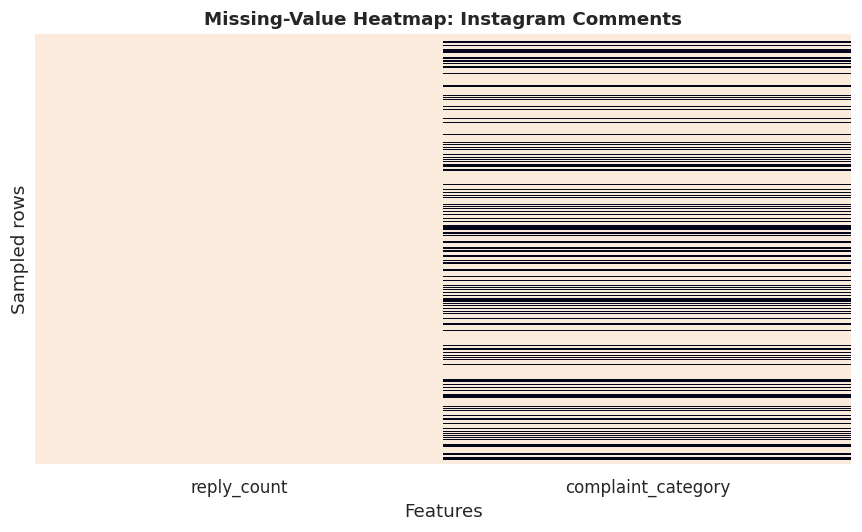

YouTube Videos


,Missing_Count,Missing_Percentage
is_monetized,2500,100.000


,Pattern_1_Missing_0_Observed,Count
0,1,2500


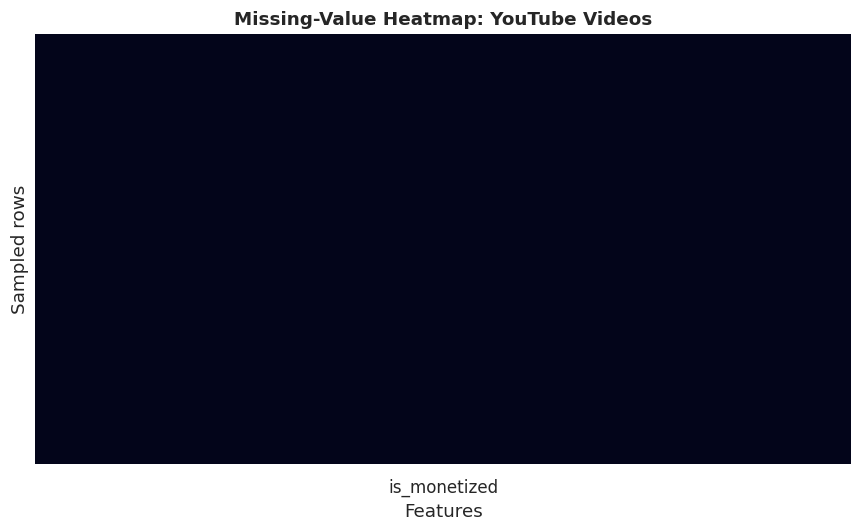

Combined Social Content
No missing values detected.


In [6]:
def missing_table(df):
    table = pd.DataFrame({
        'Missing_Count': df.isna().sum(),
        'Missing_Percentage': (df.isna().mean() * 100).round(3)
    })
    return table[table['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

def missing_patterns(df, top_n=15):
    columns = df.columns[df.isna().any()].tolist()
    if not columns:
        return pd.DataFrame({'Pattern': ['No missing values'], 'Count': [len(df)]})
    pattern = df[columns].isna().astype(int).astype(str).agg(''.join, axis=1)
    return pattern.value_counts().head(top_n).rename_axis('Pattern_1_Missing_0_Observed').reset_index(name='Count')

for dataset_name, df in raw_datasets.items():
    print('=' * 100)
    print(dataset_name)
    print('=' * 100)
    table = missing_table(df)
    if table.empty:
        print('No missing values detected.')
        continue
    display(table)
    display(missing_patterns(df))
    columns = table.index.tolist()
    sampled = df[columns].sample(min(600, len(df)), random_state=RANDOM_SEED)
    plt.figure(figsize=(max(8, len(columns) * 1.5), 5))
    sns.heatmap(sampled.isna(), cbar=False, yticklabels=False)
    plt.title(f'Missing-Value Heatmap: {dataset_name}')
    plt.xlabel('Features')
    plt.ylabel('Sampled rows')
    plt.tight_layout()
    plt.show()

### **MCAR, MAR, MNAR, and Imputation Choice**

Missingness cannot be proven to be MCAR, MAR, or MNAR from EDA alone; collection knowledge is required.

- **MCAR:** unrelated to observed and unobserved values.
- **MAR:** related to other observed variables.
- **MNAR:** related to the missing value or the reason it was not recorded.
- `complaint_category` is structural/MNAR-like because it applies only to complaint comments.
- `reply_count` is redundant because `replies` contains the values.
- `is_monetized` is completely unobserved and should be `Unknown` or excluded.

**Mean** is suitable for symmetric numerical data, **median** for skewed/outlier-prone numerical data, **mode** for categorical data, **forward/backward fill** for logically ordered time series, and **constant replacement** for structural labels such as `Not Applicable` or `Unknown`. The final cleaning applies only defensible methods.

## **7. Cleaning and Suitable Imputation**

In [7]:
instagram_posts = instagram_posts_raw.copy()
instagram_comments = instagram_comments_raw.copy()
youtube = youtube_raw.copy()
social_content = social_content_raw.copy()

for df in [instagram_posts, instagram_comments, youtube, social_content]:
    df.drop_duplicates(inplace=True)
    for c in df.select_dtypes(include=['object', 'string']).columns:
        df[c] = df[c].astype('string').str.strip()

date_map = {
    'Instagram Posts': (instagram_posts, ['post_datetime','published_at']),
    'Instagram Comments': (instagram_comments, ['comment_datetime','comment_timestamp']),
    'YouTube Videos': (youtube, ['upload_datetime','published_at']),
    'Combined Social Content': (social_content, ['publish_datetime','published_at'])
}
for _, (df, columns) in date_map.items():
    for c in columns:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce', utc=True)

instagram_comments['complaint_category'] = instagram_comments['complaint_category'].fillna('Not Applicable')
if 'reply_count' in instagram_comments and instagram_comments['reply_count'].isna().all():
    instagram_comments['reply_count'] = instagram_comments['replies']
if 'is_monetized' in youtube:
    youtube['is_monetized'] = youtube['is_monetized'].astype('string').fillna('Unknown')

# Examples, applied only when logically suitable:
# df['symmetric_numeric'] = df['symmetric_numeric'].fillna(df['symmetric_numeric'].mean())
# df['skewed_numeric'] = df['skewed_numeric'].fillna(df['skewed_numeric'].median())
# df['category'] = df['category'].fillna(df['category'].mode().iloc[0])
# df = df.sort_values('date')
# df['time_value'] = df['time_value'].ffill().bfill()

cleaned_datasets = {
    'Instagram Posts': instagram_posts,
    'Instagram Comments': instagram_comments,
    'YouTube Videos': youtube,
    'Combined Social Content': social_content
}

for name, df in cleaned_datasets.items():
    print(name, '- remaining missing cells:', int(df.isna().sum().sum()))
    display(missing_table(df))

Instagram Posts - remaining missing cells: 0


,Missing_Count,Missing_Percentage


Instagram Comments - remaining missing cells: 0


,Missing_Count,Missing_Percentage


YouTube Videos - remaining missing cells: 0


,Missing_Count,Missing_Percentage


Combined Social Content - remaining missing cells: 0


,Missing_Count,Missing_Percentage


## **8. Feature Engineering**

In [8]:
def safe_divide(numerator, denominator, multiplier=1.0):
    return numerator / denominator.replace(0, np.nan) * multiplier

instagram_posts['total_engagement'] = instagram_posts[['likes','comments','shares','saves']].sum(axis=1)
instagram_posts['engagement_rate_calculated'] = safe_divide(instagram_posts['total_engagement'], instagram_posts['reach'], 100)
instagram_posts['reach_to_impression_pct'] = safe_divide(instagram_posts['reach'], instagram_posts['impressions'], 100)
instagram_posts['share_rate_pct'] = safe_divide(instagram_posts['shares'], instagram_posts['reach'], 100)
instagram_posts['save_rate_pct'] = safe_divide(instagram_posts['saves'], instagram_posts['reach'], 100)
instagram_posts['comment_to_like_ratio'] = safe_divide(instagram_posts['comments'], instagram_posts['likes'])
instagram_posts['caption_word_count_calculated'] = instagram_posts['caption_clean'].fillna('').str.split().str.len()
instagram_posts['post_year'] = instagram_posts['post_datetime'].dt.year
instagram_posts['post_month'] = instagram_posts['post_datetime'].dt.month
instagram_posts['is_weekend_calculated'] = instagram_posts['post_datetime'].dt.dayofweek >= 5
instagram_posts['sentiment_label'] = pd.cut(instagram_posts['sentiment_score'], [-np.inf,-0.2,0.2,np.inf], labels=['Negative','Neutral','Positive']).astype('string')

instagram_comments['comment_character_count_calculated'] = instagram_comments['comment_text_clean'].fillna('').str.len()
instagram_comments['comment_word_count_calculated'] = instagram_comments['comment_text_clean'].fillna('').str.split().str.len()
instagram_comments['question_mark_present'] = instagram_comments['comment_text_clean'].fillna('').str.contains(r'\?')
instagram_comments['url_count'] = instagram_comments['comment_text_clean'].fillna('').str.count(r'https?://\S+|www\.\S+')
instagram_comments['comment_year'] = instagram_comments['comment_datetime'].dt.year
instagram_comments['comment_month'] = instagram_comments['comment_datetime'].dt.month
instagram_comments['is_weekend_calculated'] = instagram_comments['comment_datetime'].dt.dayofweek >= 5

youtube['total_engagement'] = youtube[['likes','comments','shares']].sum(axis=1)
youtube['engagement_rate_calculated'] = safe_divide(youtube['total_engagement'], youtube['views'], 100)
youtube['likes_per_1000_views'] = safe_divide(youtube['likes'], youtube['views'], 1000)
youtube['comments_per_1000_views'] = safe_divide(youtube['comments'], youtube['views'], 1000)
youtube['shares_per_1000_views'] = safe_divide(youtube['shares'], youtube['views'], 1000)
youtube['subscriber_gain_per_1000_views'] = safe_divide(youtube['subscriber_gain'], youtube['views'], 1000)
youtube['revenue_per_1000_views'] = safe_divide(youtube['estimated_revenue_usd'], youtube['views'], 1000)
youtube['average_percentage_viewed_calculated'] = safe_divide(youtube['average_view_duration'], youtube['duration_seconds'], 100)
youtube['title_word_count'] = youtube['title_clean'].fillna('').str.split().str.len()
youtube['description_word_count'] = youtube['description_clean'].fillna('').str.split().str.len()
youtube['upload_year'] = youtube['upload_datetime'].dt.year
youtube['upload_month'] = youtube['upload_datetime'].dt.month
youtube['is_weekend_calculated'] = youtube['upload_datetime'].dt.dayofweek >= 5

social_content['total_engagement'] = social_content[['likes','comments','shares','saves']].sum(axis=1)
social_content['engagement_rate_calculated'] = safe_divide(social_content['total_engagement'], social_content['reach'], 100)
social_content['reach_to_impression_pct'] = safe_divide(social_content['reach'], social_content['impressions'], 100)

instagram_standardized = pd.DataFrame({
    'platform': 'Instagram',
    'content_id': instagram_posts['post_id'],
    'publish_datetime': instagram_posts['post_datetime'],
    'content_type': instagram_posts['media_type'],
    'category_campaign': instagram_posts['campaign'],
    'product': instagram_posts['product'],
    'title_or_text': instagram_posts['caption_clean'],
    'views_or_reach': instagram_posts['reach'],
    'impressions': instagram_posts['impressions'],
    'likes': instagram_posts['likes'],
    'comments': instagram_posts['comments'],
    'shares': instagram_posts['shares'],
    'saves': instagram_posts['saves'],
    'total_engagement': instagram_posts['total_engagement'],
    'engagement_rate_pct': instagram_posts['engagement_rate_calculated'],
    'viral_score': instagram_posts['viral_score'],
    'posting_hour': instagram_posts['posting_hour'],
    'weekday': instagram_posts['weekday'],
    'location': instagram_posts['audience_region'],
    'url': instagram_posts['post_url']
})

youtube_standardized = pd.DataFrame({
    'platform': 'YouTube',
    'content_id': youtube['video_id'],
    'publish_datetime': youtube['upload_datetime'],
    'content_type': youtube['raw_content_type'],
    'category_campaign': youtube['category'],
    'product': youtube['product'],
    'title_or_text': youtube['combined_text'],
    'views_or_reach': youtube['views'],
    'impressions': np.nan,
    'likes': youtube['likes'],
    'comments': youtube['comments'],
    'shares': youtube['shares'],
    'saves': 0,
    'total_engagement': youtube['total_engagement'],
    'engagement_rate_pct': youtube['engagement_rate_calculated'],
    'viral_score': youtube['viral_score'],
    'posting_hour': youtube['upload_hour'],
    'weekday': youtube['weekday'],
    'location': youtube['country'],
    'url': youtube['video_url']
})

instagram_youtube_combined = pd.concat([instagram_standardized, youtube_standardized], ignore_index=True)
print('Instagram engineered data:')
display(instagram_posts.head())
print('YouTube engineered data:')
display(youtube.head())
print('Standardized combined data:')
display(instagram_youtube_combined.head())

Instagram engineered data:


,post_id,post_datetime,media_type,likes,comments,shares,saves,reach,impressions,engagement_rate,caption,campaign,product,hashtags_used,caption_length,sentiment_score,audience_region,posting_hour,weekday,is_promoted,viral_score,short_code,post_url,published_at,raw_content_type,product_type,caption_original,likes_count,comments_count,video_view_count,video_play_count,video_duration_seconds,thumbnail_url,audio_url,account_id,account_username,location_name,is_paid_partnership,caption_clean,content_type,hashtags,mentions,hashtag_count,mention_count,caption_character_count,total_engagement,engagement_rate_calculated,reach_to_impression_pct,share_rate_pct,save_rate_pct,comment_to_like_ratio,caption_word_count_calculated,post_year,post_month,is_weekend_calculated,sentiment_label
0,NP100000,2026-11-17 03:00:52.657354+00:00,Reel,1596,27,79,87,18417,27807,9.710,Discover the latest Ear (2)! Behind the Scenes...,Giveaway,CMF Phone,6,80,0.756,South,3,Tuesday,0,13.800,DZFFP39BlQM,https://www.instagram.com/p/DYZNUKKBVJw/,2025-02-17 10:01:37+00:00,Video,feed,"A study of touch, material, and restraint. Ha...","1,384.000",208.000,"52,502.000","1,166,207.000",20.386,https://instagram.fpoz4-1.fna.fbcdn.net/v/t51....,https://instagram.fntr5-1.fna.fbcdn.net/o1/v/t...,12549331383,rashmika_mandanna,antiSOCIAL,False,A colourful new unibody. All eyes on you. Phon...,Other,internationalcatday,"superkicksindia, beebomco",6,1,205,1789,9.714,66.232,0.429,0.472,0.017,10,2026,11,False,Positive
1,NP100001,2025-11-13 04:55:26.011230+00:00,Image,2426,88,181,95,32496,43174,8.590,Discover the latest Phone (3a)! Photography wi...,Photography,Nothing OS,6,77,0.698,East,4,Thursday,0,24.900,Da2qCMNBPib,https://www.instagram.com/p/DSCzknIDb5D/,2024-11-24 12:40:45+00:00,Video,clips,"In May 2024, our community member @andresmateo...","1,041.000",19.000,"688,082.000","136,324.000",11.666,https://scontent-yyz1-1.cdninstagram.com/v/t51...,https://instagram.fmad6-1.fna.fbcdn.net/o1/v/t...,1381101303,superkicksindia,antiSOCIAL,False,Intricate. From the inside-out. Get Closer | 4...,Other,withnothing,"snapdragon_in, arakucoffeein",0,14,75,2790,8.586,75.268,0.557,0.292,0.036,11,2025,11,False,Positive
2,NP100002,2027-02-18 07:35:29.168658+00:00,Carousel,4464,40,168,277,70383,87070,7.030,Discover the latest CMF Phone! Photography wit...,Giveaway,Ear (2),7,74,0.534,East,7,Thursday,0,25.300,DJGi76JNvem,https://www.instagram.com/p/DFh0VH5Pixq/,2025-02-20 15:27:45+00:00,Image,clips,Nothing | Amit Aggarwal at the 25th Lakme Fash...,"2,357.000",131.000,"27,794.000","136,471.000",12.466,https://instagram.fyto1-2.fna.fbcdn.net/v/t51....,https://scontent-itm1-1.cdninstagram.com/o1/v/...,43813467012,nothing,antiSOCIAL,False,Do I smell food? #withNothing on Phone (3a) Se...,Other,iykyk,"bhumipednekar, amitaggarwalofficial, lakmefash...",1,0,174,4949,7.032,80.835,0.239,0.394,0.009,9,2027,2,False,Positive
3,NP100003,2026-08-24 19:15:10.079513+00:00,Carousel,2272,64,175,125,35348,50351,7.460,Discover the latest Phone (3a)! Feature Highli...,Software Update,Nothing OS,2,83,0.739,Central,19,Monday,1,17.000,DDHjodLh2H0,https://www.instagram.com/p/DJDykHcB397/,2025-04-30 05:38:49+00:00,Video,carousel_container,Lights - The soul of Diwali. Glyphs - The soul...,"5,153.000",11.000,"12,281.000","83,972.000",64.879,https://scontent-ams2-1.cdninstagram.com/v/t51...,https://instagram.fymq3-1.fna.fbcdn.net/o1/v/t...,45192723962,nothing,antiSOCIAL,False,Just one piece of the puzzle. Flagship store. ...,Other,internationalcatday,skaterladki,0,2,37,2636,7.457,70.203,0.495,0.354,0.028,11,2026,8,False,Positive
4,NP100004,2024-10-29 16:32:32.066100+00:00,Reel,2954,109,75,351,16660,19163,20.940,Discover the latest Ear! Photography with Noth...,Photography,Phone (3a),3,65,0.858,South,16,Tuesday,0,46.500,DMNfXoDBPw8,https://www.instagram.com/p/DZ2T26PB2oN/,2026-07-18 09:34:21+00:00,Sidecar,clips,Counter by Paul Gesekus. Come to play.,"67,863.000",60.000,"9,588.000","163,060.000",12.466,https://scontent-dfw6-1.cdni

YouTube engineered data:


,video_id,title,upload_datetime,category,product,duration_seconds,views,likes,comments,shares,watch_time_seconds,average_view_duration,audience_retention_percent,click_through_rate,subscriber_gain,estimated_revenue_usd,traffic_source,device,country,seo_score,engagement_rate,viral_score,weekday,upload_hour,video_url,title_original,description_original,translated_title,translated_description,published_at,raw_content_type,view_count,likes_count,comments_count,thumbnail_url,account_id,channel_name,account_username,channel_url,subscriber_count,channel_total_videos,channel_total_views,is_channel_verified,is_paid_content,is_members_only,is_monetized,location_name,title_clean,description_clean,combined_text,total_engagement,engagement_rate_calculated,likes_per_1000_views,comments_per_1000_views,shares_per_1000_views,subscriber_gain_per_1000_views,revenue_per_1000_views,average_percentage_viewed_calculated,title_word_count,description_word_count,upload_year,upload_month,is_weekend_calculated
0,YT300000,Ear (2) - Camera,2024-09-14 11:00:00+00:00,Shorts,CMF Phone,480,13370,1047,41,116,2526930,189,65.740,3.740,86,46.070,External,Tablet,USA,65.200,9.010,37.900,Saturday,11,https://www.youtube.com/shorts/l3OChf8ljqo,"Nothing Phone (3) ⚡ Macro Shots, Camera Samples",Shot by Ayan Samantha Phone (3).,Our Co-founder Akis raced ‪@TechnicalGuruji‬ ...,Macro world by ‪@creationbyarijit‬ Phone (3)....,2025-03-17 03:30:11+00:00,shorts,356.000,306.000,2.000,https://i.ytimg.com/vi/OXpgqAeV8ls/maxresdefau...,UC5OpwwqJD9bOpys7Fr5HcQw,Nothing India,nothing_india,https://www.youtube.com/channel/UC5OpwwqJD9bOp...,"57,300.000",212.000,"95,143,387.000",False,False,False,Unknown,BENGALURU,Nothing Phone (3a) Lite: Light up the everyday,Shot by Harikrishnan Phone (3).,What's your guess?,1204,9.005,78.310,3.067,8.676,6.432,3.446,39.375,8,5,2024,9,True
1,YT300001,Nothing OS - Camera,2025-01-19 10:00:00+00:00,Tips,Phone (3a),488,322771,22091,1628,1883,95862987,297,44.910,7.970,2044,419.110,Search,TV,UAE,55.400,7.930,33.400,Sunday,10,https://www.youtube.com/shorts/mNjPmVAtK_U,Nothing Phone (3a) Community Edition,➤ Our website: https://nothing.tech/ ➤ Join ...,Our Co-founder Akis raced ‪@TechnicalGuruji‬ ...,Shot by ‪@JithinJayachandran1‬ CMF Phone 2 Pro.,2025-05-09 15:41:27+00:00,video,"9,629.000",20.000,10.000,https://i.ytimg.com/vi/q1gBKr8pbFc/maxresdefau...,UC5OpwwqJD9bOpys7Fr5HcQw,Nothing India,nothing_india,https://www.youtube.com/channel/UC5OpwwqJD9bOp...,"57,300.000",212.000,"95,143,387.000",False,False,False,Unknown,BENGALURU,⚠️MISSING ⚠️,"7 July. Doors open at 4 PM. Nothing Store, Ben...",Nothing Phone (3a) Lite 🔵 India Phone (3a) Lit...,25602,7.932,68.442,5.044,5.834,6.333,1.298,60.861,2,23,2025,1,True
2,YT300002,Nothing OS - Behind the Scenes,2025-11-14 15:00:00+00:00,Tips,Ear (2),720,82993,4115,442,1003,27387690,330,46.800,7.590,262,223.080,Notifications,Mobile,UK,71.500,6.700,24.500,Friday,15,https://www.youtube.com/shorts/SxED5EfAj_E,Nothing Co-Founder India Quiz (Part 5),Shot by stkchs Phone (3),Our Co-founder Akis raced ‪@TechnicalGuruji‬ ...,shot by ‪@JithinJayachandran1‬ Phone (3).,2025-05-07 10:12:45+00:00,shorts,375.000,72.000,33.000,https://i.ytimg.com/vi/s1pemQ-Y9XA/maxres2.jpg...,UC5OpwwqJD9bOpys7Fr5HcQw,Nothing India,nothing_india,https://www.youtube.com/channel/UC5OpwwqJD9bOp...,"57,300.000",212.000,"95,143,387.000",False,False,False,Unknown,BENGALURU,Nothing Phone (3a) ⚡ Drop Test,Shot by @ajeeshajayakhosh Phone (3a) Pro.,"Up close, thanks to the sharp eyes of our comm...",5560,6.699,49.582,5.326,12.085,3.157,2.688,45.833,6,6,2025,11,False
3,YT300003,Phone (3) - Behind the Scenes,2024-01-17 23:00:00+00:00,Behind the Scenes,Accessories,864,64921,3846,242,497,18827090,290,50.590,5.110,391,130.410,Notifications,Mobile,USA,66.600,7.060,31.700,Wednesday,23,https://www.youtube.com/shorts/DD-UjtJpeGQ,Nothing Co-Founder India Quiz (Part 3),A few members of the Nothing Community react t...,Our Co-founder Akis raced ‪@TechnicalGuruji‬ ...,One Choice.

Standardized combined data:


,platform,content_id,publish_datetime,content_type,category_campaign,product,title_or_text,views_or_reach,impressions,likes,comments,shares,saves,total_engagement,engagement_rate_pct,viral_score,posting_hour,weekday,location,url
0,Instagram,NP100000,2026-11-17 03:00:52.657354+00:00,Reel,Giveaway,CMF Phone,A colourful new unibody. All eyes on you. Phon...,18417,"27,807.000",1596,27,79,87,1789,9.714,13.800,3,Tuesday,South,https://www.instagram.com/p/DYZNUKKBVJw/
1,Instagram,NP100001,2025-11-13 04:55:26.011230+00:00,Image,Photography,Nothing OS,Intricate. From the inside-out. Get Closer | 4...,32496,"43,174.000",2426,88,181,95,2790,8.586,24.900,4,Thursday,East,https://www.instagram.com/p/DSCzknIDb5D/
2,Instagram,NP100002,2027-02-18 07:35:29.168658+00:00,Carousel,Giveaway,Ear (2),Do I smell food? #withNothing on Phone (3a) Se...,70383,"87,070.000",4464,40,168,277,4949,7.032,25.300,7,Thursday,East,https://www.instagram.com/p/DFh0VH5Pixq/
3,Instagram,NP100003,2026-08-24 19:15:10.079513+00:00,Carousel,Software Update,Nothing OS,Just one piece of the puzzle. Flagship store. ...,35348,"50,351.000",2272,64,175,125,2636,7.457,17.000,19,Monday,Central,https://www.instagram.com/p/DJDykHcB397/
4,Instagram,NP100004,2024-10-29 16:32:32.066100+00:00,Reel,Photography,Phone (3a),What inspires you from the everyday?,16660,"19,163.000",2954,109,75,351,3489,20.942,46.500,16,Tuesday,South,https://www.instagram.com/p/DZ2T26PB2oN/


## **9. Numerical and Categorical Summary Statistics**

In [9]:
def numerical_summary(df):
    rows = []
    for c in df.select_dtypes(include=np.number).columns:
        v = df[c].dropna()
        if v.empty:
            continue
        q1, q3 = v.quantile([0.25,0.75])
        mode = v.mode().iloc[0] if not v.mode().empty else np.nan
        rows.append({
            'Feature': c, 'Count': v.count(), 'Mean': v.mean(), 'Median': v.median(), 'Mode': mode,
            'Std_Dev': v.std(), 'Variance': v.var(), 'Min': v.min(), 'Q1': q1, 'Q2': v.median(),
            'Q3': q3, 'Max': v.max(), 'Range': v.max()-v.min(), 'IQR': q3-q1,
            'Skewness': v.skew(), 'Kurtosis': v.kurtosis()
        })
    return pd.DataFrame(rows).set_index('Feature')

def categorical_tables(df, top_n=10):
    result = {}
    for c in df.select_dtypes(include=['object','string','category','bool']).columns:
        counts = df[c].value_counts(dropna=False).head(top_n)
        pct = df[c].value_counts(dropna=False, normalize=True).head(top_n) * 100
        result[c] = pd.DataFrame({'Count': counts, 'Percentage': pct.round(3)})
    return result

numerical_summaries = {}
for name, df in cleaned_datasets.items():
    print('=' * 100)
    print(name.upper())
    print('=' * 100)
    numerical_summaries[name] = numerical_summary(df)
    display(numerical_summaries[name])
    cat = categorical_tables(df)
    for c in list(cat)[:8]:
        print('\nFrequency table:', c)
        display(cat[c])

INSTAGRAM POSTS


,Count,Mean,Median,Mode,Std_Dev,Variance,Min,Q1,Q2,Q3,Max,Range,IQR,Skewness,Kurtosis
Feature,,,,,,,,,,,,,,,
likes,2500,"4,945.008","3,654.500","1,222.000","4,258.684","18,136,388.031",200.000,"2,249.500","3,654.500","6,203.000","43,061.000","42,861.000","3,953.500",2.814,13.584
comments,2500,119.218,84.500,42.000,118.780,"14,108.590",1.000,45.000,84.500,152.000,"1,429.000","1,428.000",107.000,3.050,15.821
shares,2500,223.425,149.000,46.000,236.991,"56,164.510",5.000,77.000,149.000,277.000,"2,717.000","2,712.000",200.000,3.371,20.161
saves,2500,348.176,244.500,246.000,352.461,"124,228.438",4.000,132.000,244.500,436.000,"4,776.000","4,772.000",304.000,3.601,24.393
reach,2500,"56,597.529","40,100.000","6,559.000","52,921.020","2,800,634,338.493","1,845.000","22,627.500","40,100.000","72,656.750","615,783.000","613,938.000","50,029.250",2.885,14.697
impressions,2500,"81,254.309","56,376.500","13,304.000","78,749.481","6,201,480,806.555","2,765.000","31,583.000","56,376.500","102,564.250","963,870.000","961,105.000","70,981.250",3.071,16.667
engagement_rate,2500,11.265,9.810,6.740,4.382,19.201,5.930,7.688,9.810,13.950,24.060,18.130,6.262,0.913,-0.188
hashtags_used,2500,4.930,5.000,5.000,1.973,3.891,2.000,3.000,5.000,7.000,8.000,6.000,4.000,0.035,-1.214
caption_length,2500,73.165,74.000,74.000,5.758,33.151,57.000,69.000,74.000,77.000,85.000,28.000,8.000,-0.141,-0.431



Frequency table: post_id


,Count,Percentage
post_id,,
NP100004,1,0.040
NP102499,1,0.040
NP100000,1,0.040
NP100001,1,0.040
NP102484,1,0.040
NP102485,1,0.040
NP102486,1,0.040
NP102487,1,0.040
NP102488,1,0.040



Frequency table: media_type


...

,Count,Percentage
sentiment,,
Positive,3100,62.000
Neutral,1148,22.960
Negative,752,15.040



Frequency table: organic_paid


,Count,Percentage
organic_paid,,
Organic,4239,84.780
Paid,761,15.220



Frequency table: marketing_funnel


,Count,Percentage
marketing_funnel,,
Awareness,2267,45.340
Consideration,1398,27.960
Conversion,731,14.620
Retention,604,12.080


## **10. Univariate Analysis**

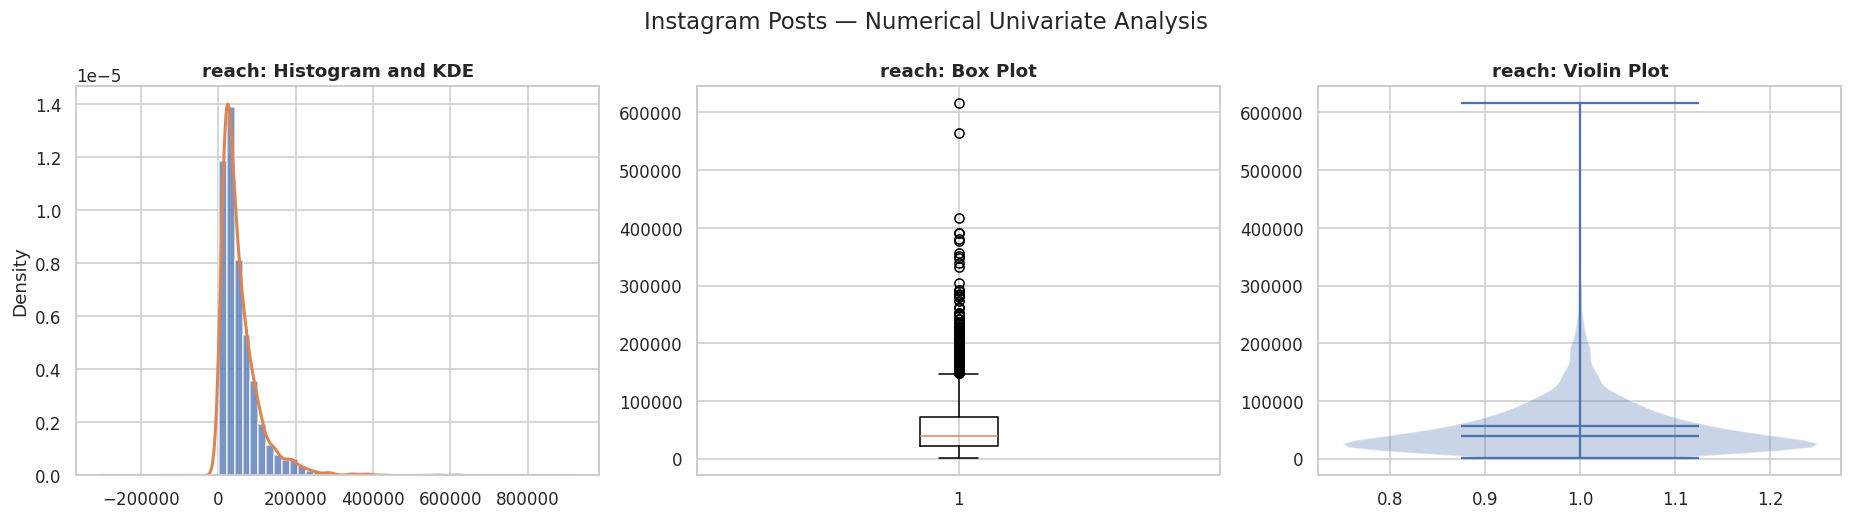

reach: skew=2.885, std=52921.020, IQR=50029.250


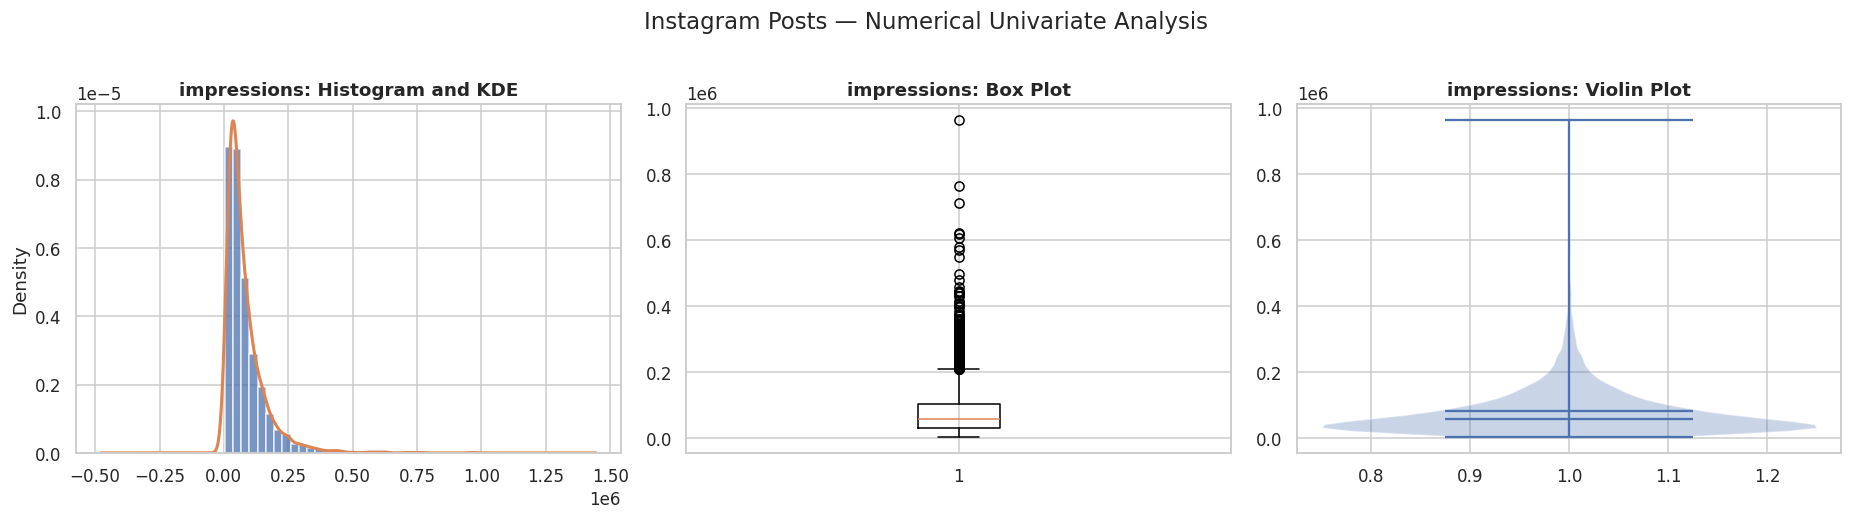

impressions: skew=3.071, std=78749.481, IQR=70981.250


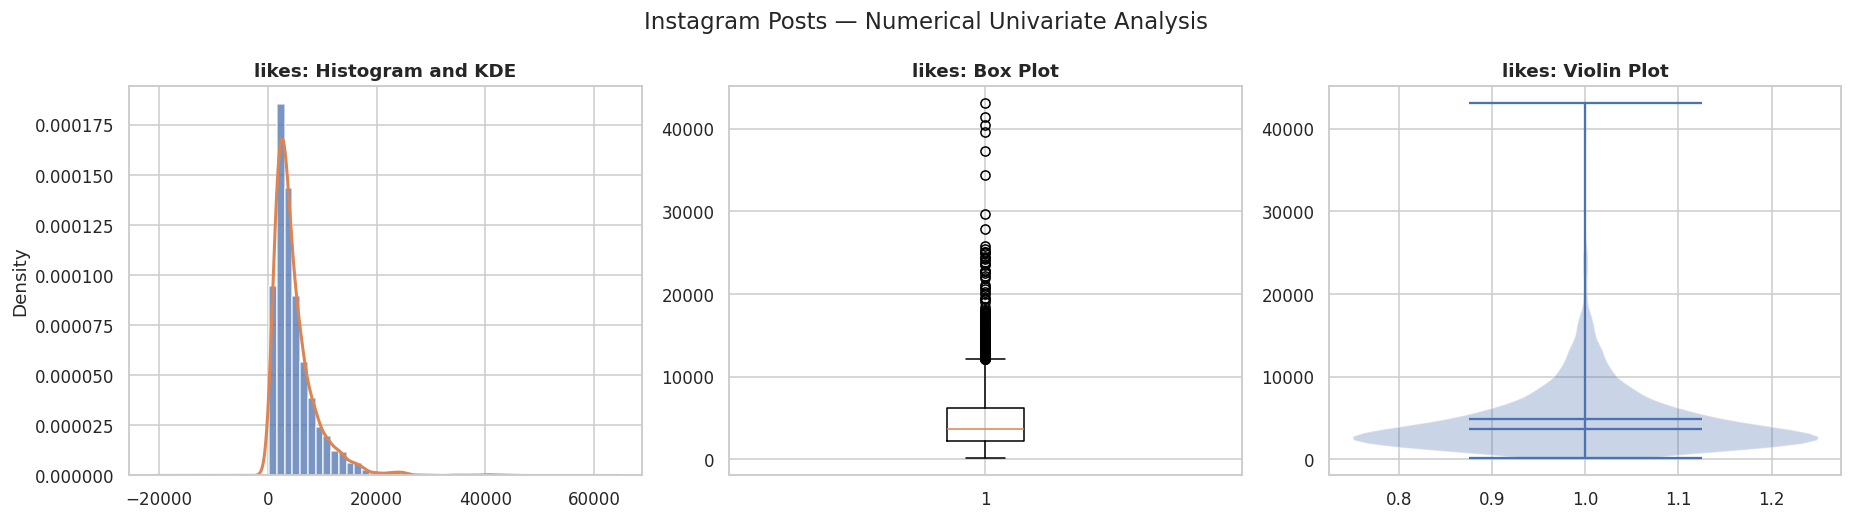

likes: skew=2.814, std=4258.684, IQR=3953.500


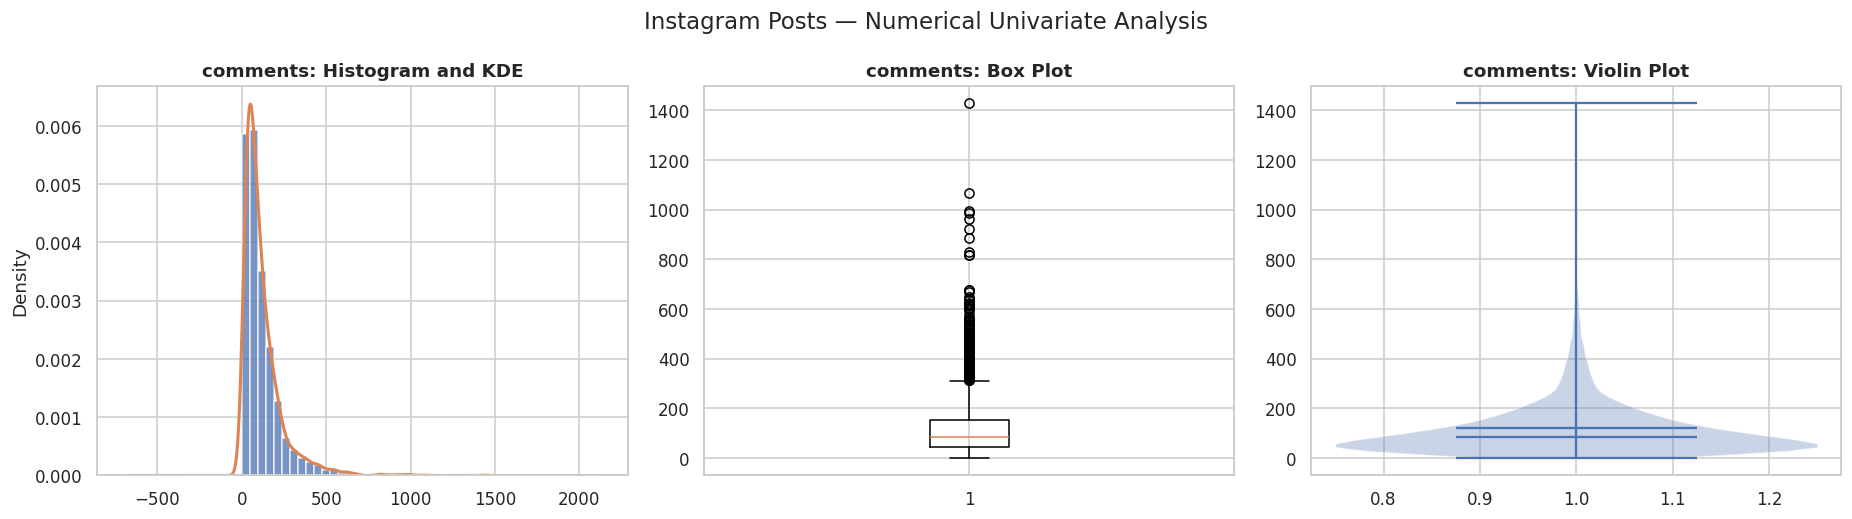

comments: skew=3.050, std=118.780, IQR=107.000


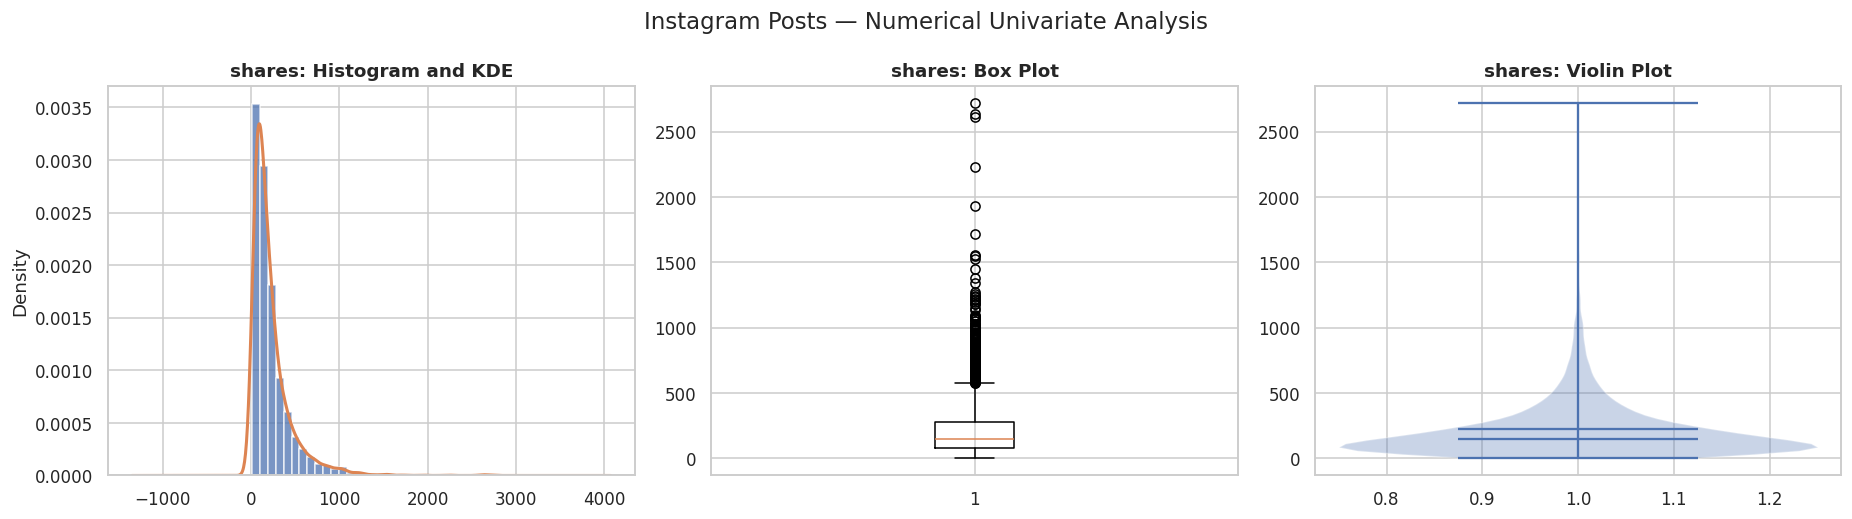

shares: skew=3.371, std=236.991, IQR=200.000


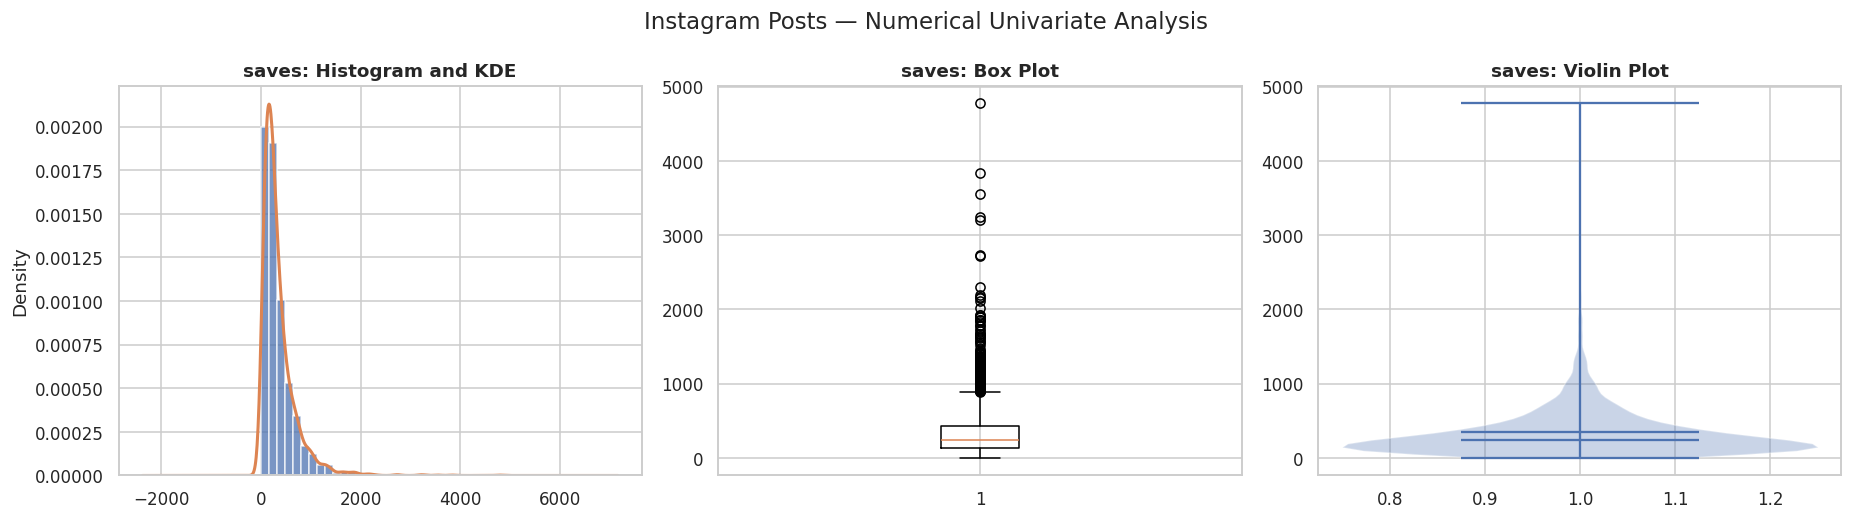

saves: skew=3.601, std=352.461, IQR=304.000


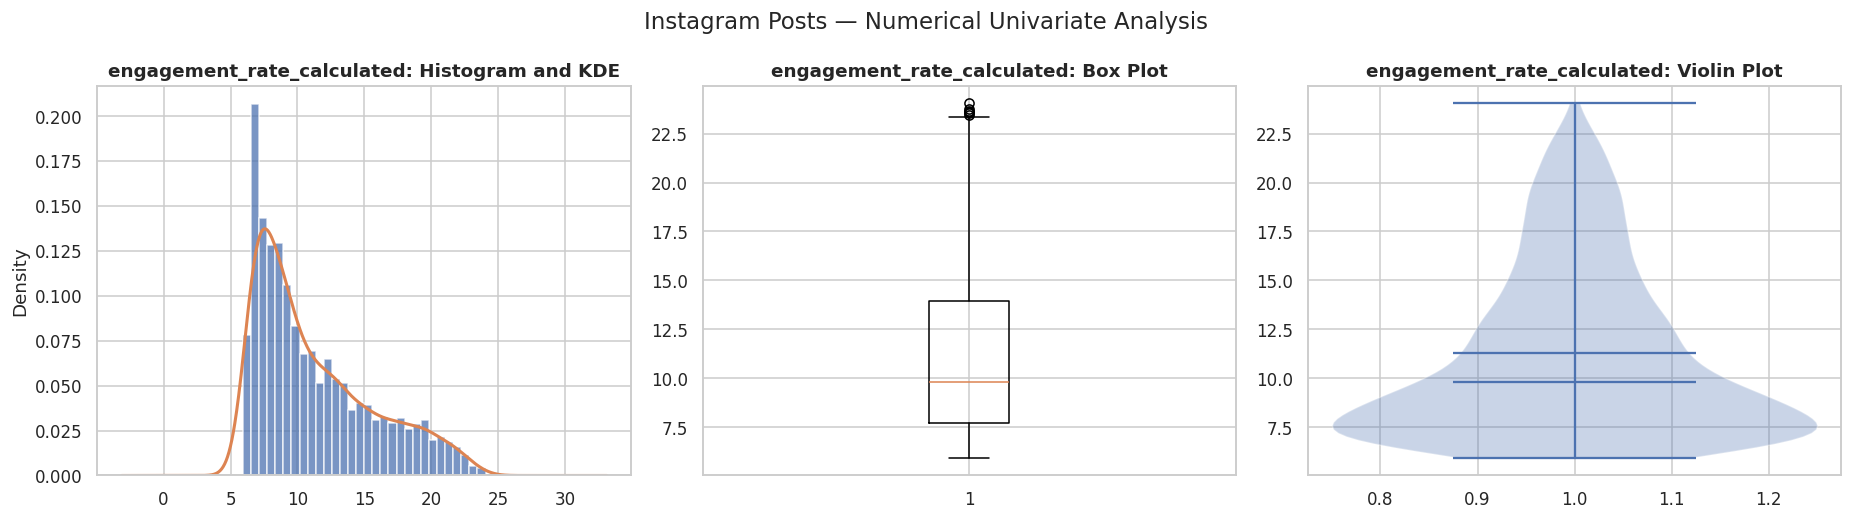

engagement_rate_calculated: skew=0.913, std=4.382, IQR=6.265


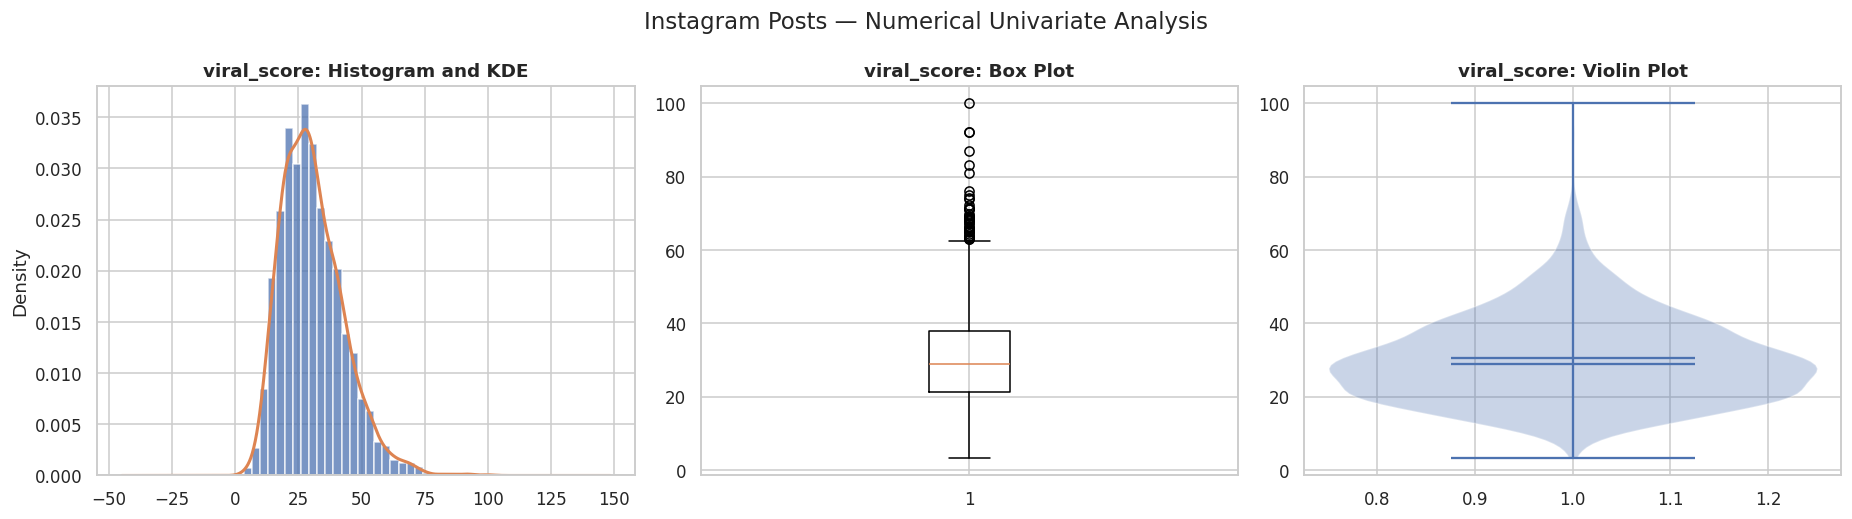

viral_score: skew=0.877, std=12.363, IQR=16.600


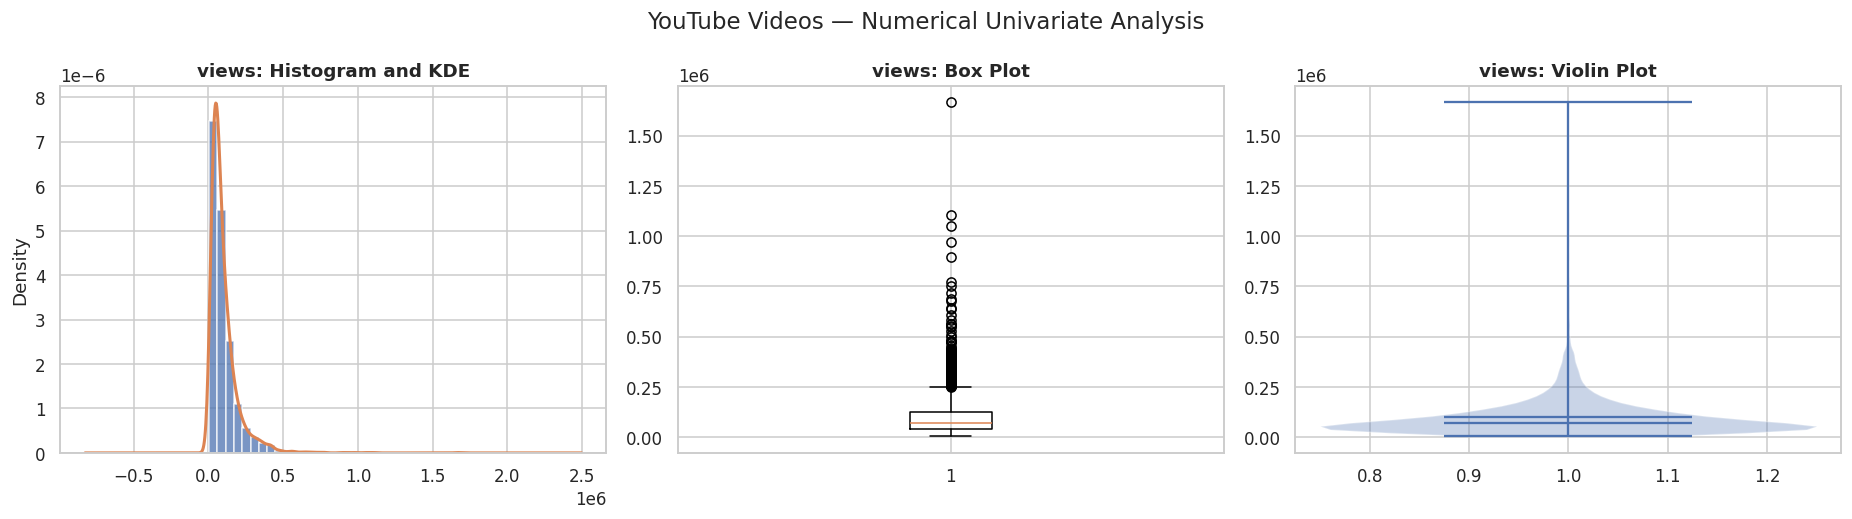

views: skew=4.264, std=102126.869, IQR=83122.500


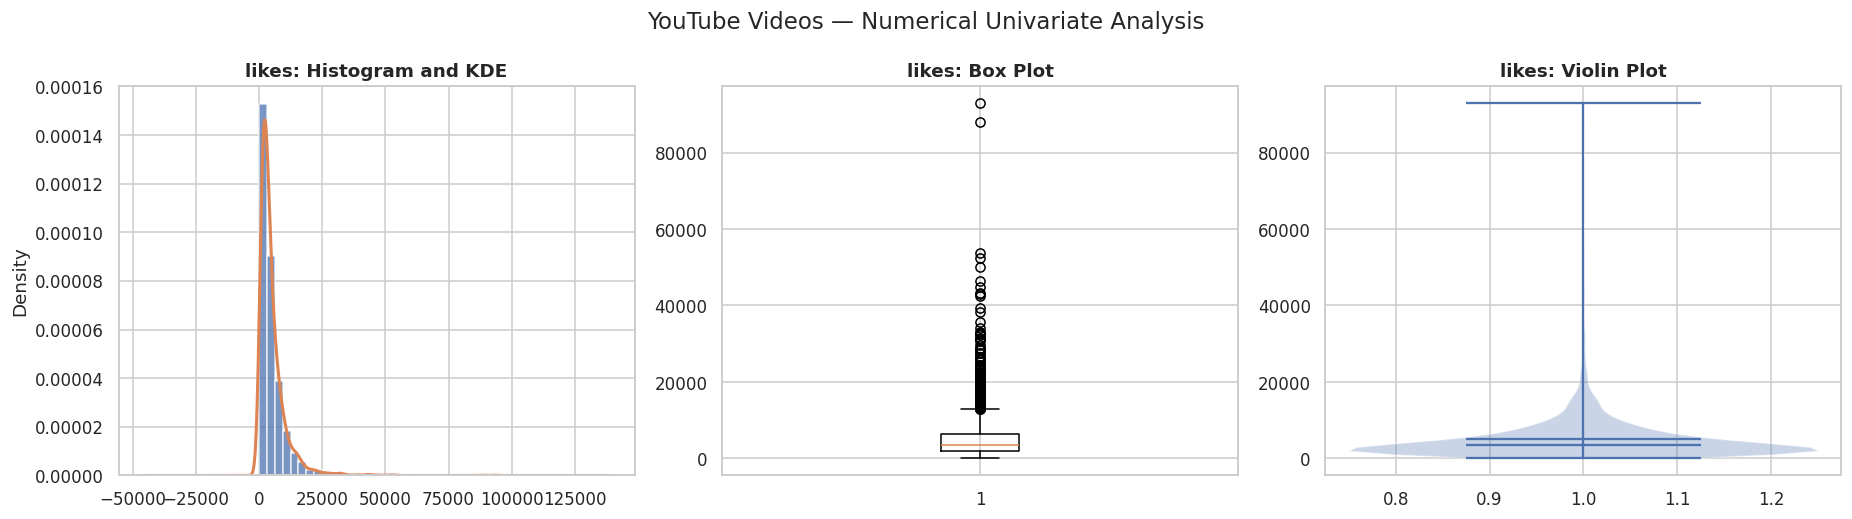

likes: skew=4.949, std=5884.877, IQR=4440.250


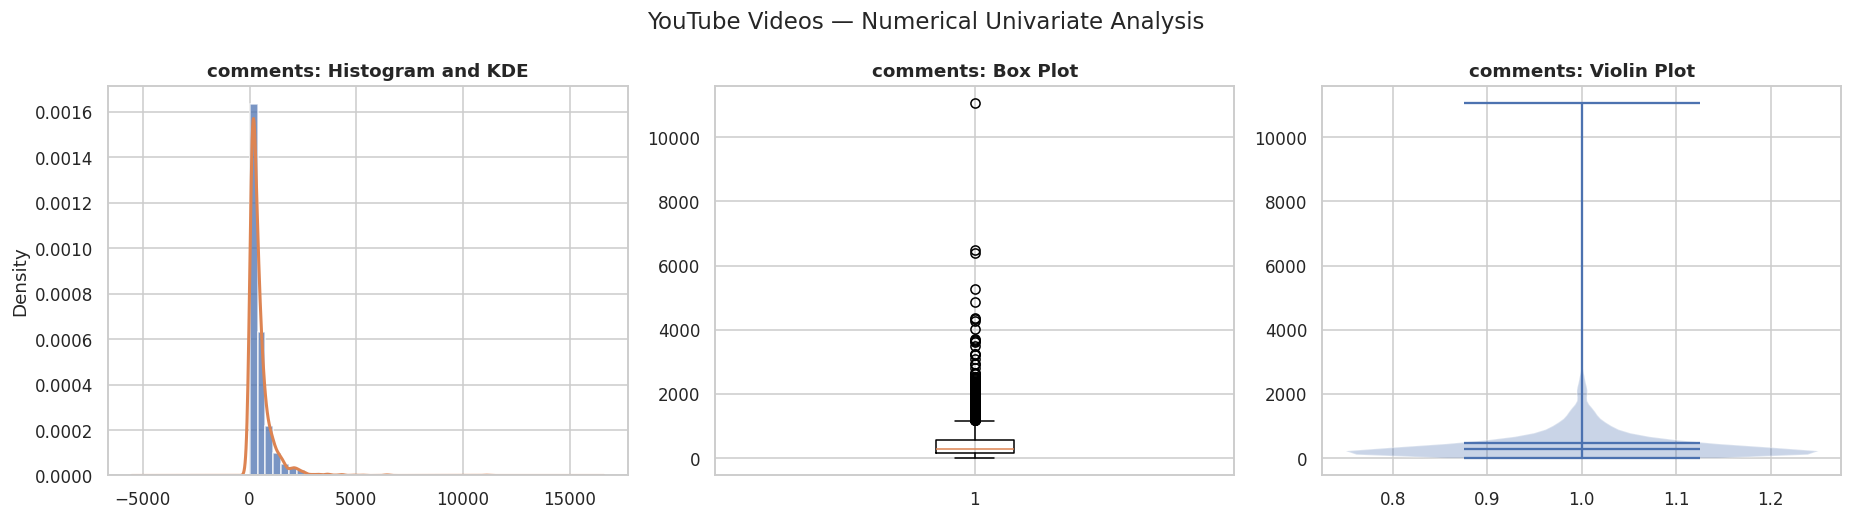

comments: skew=5.411, std=585.526, IQR=411.500


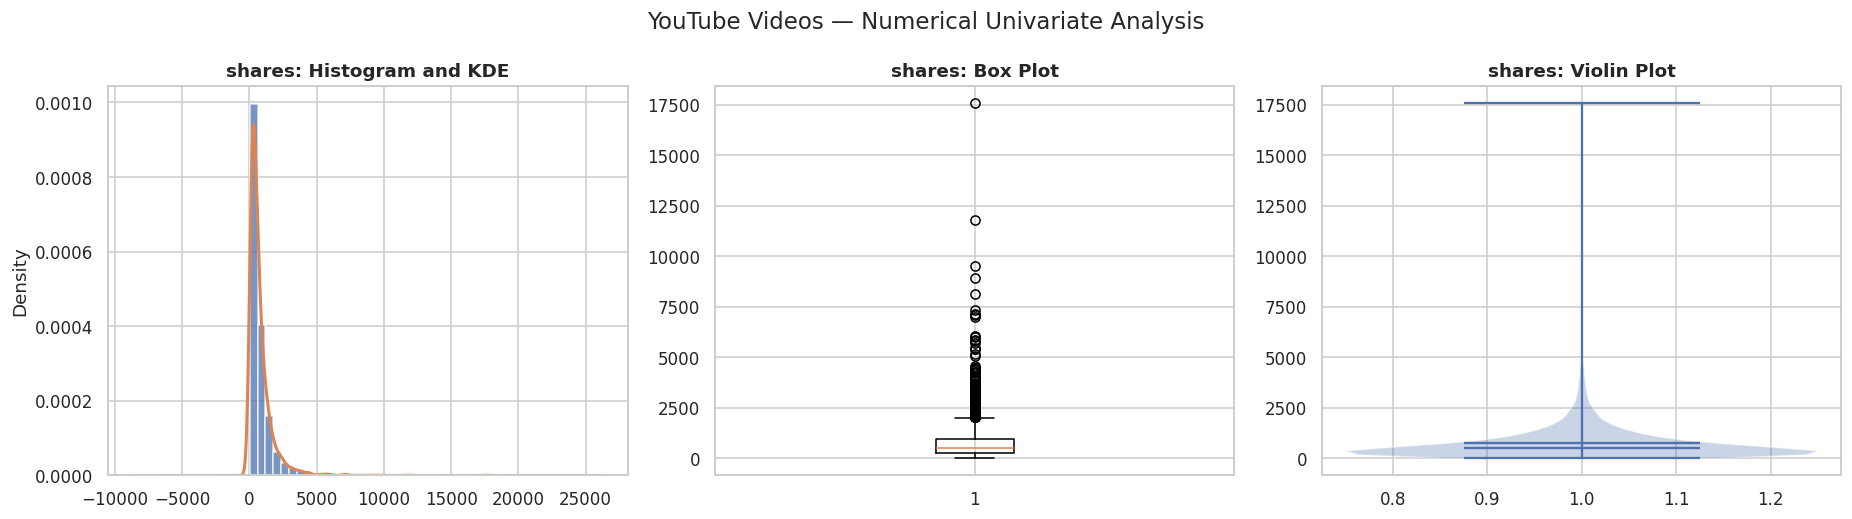

shares: skew=5.360, std=954.970, IQR=710.250


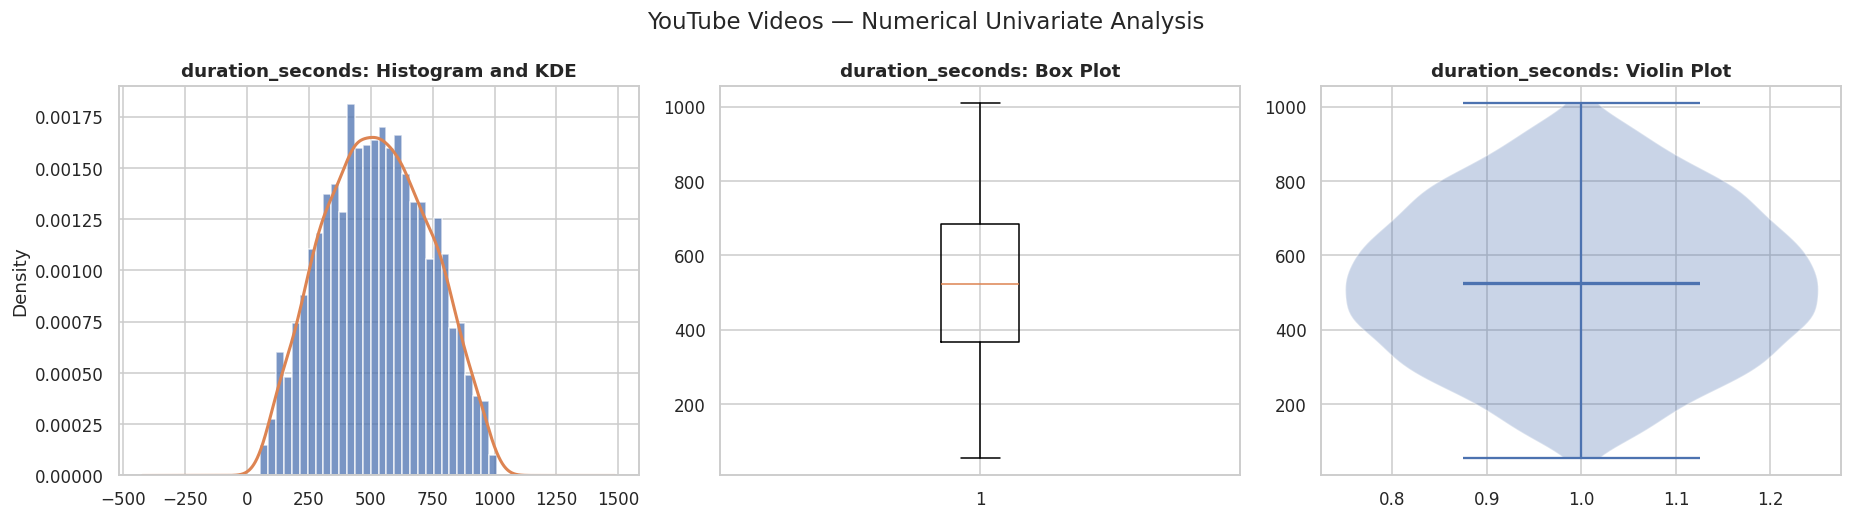

duration_seconds: skew=0.037, std=209.097, IQR=316.000


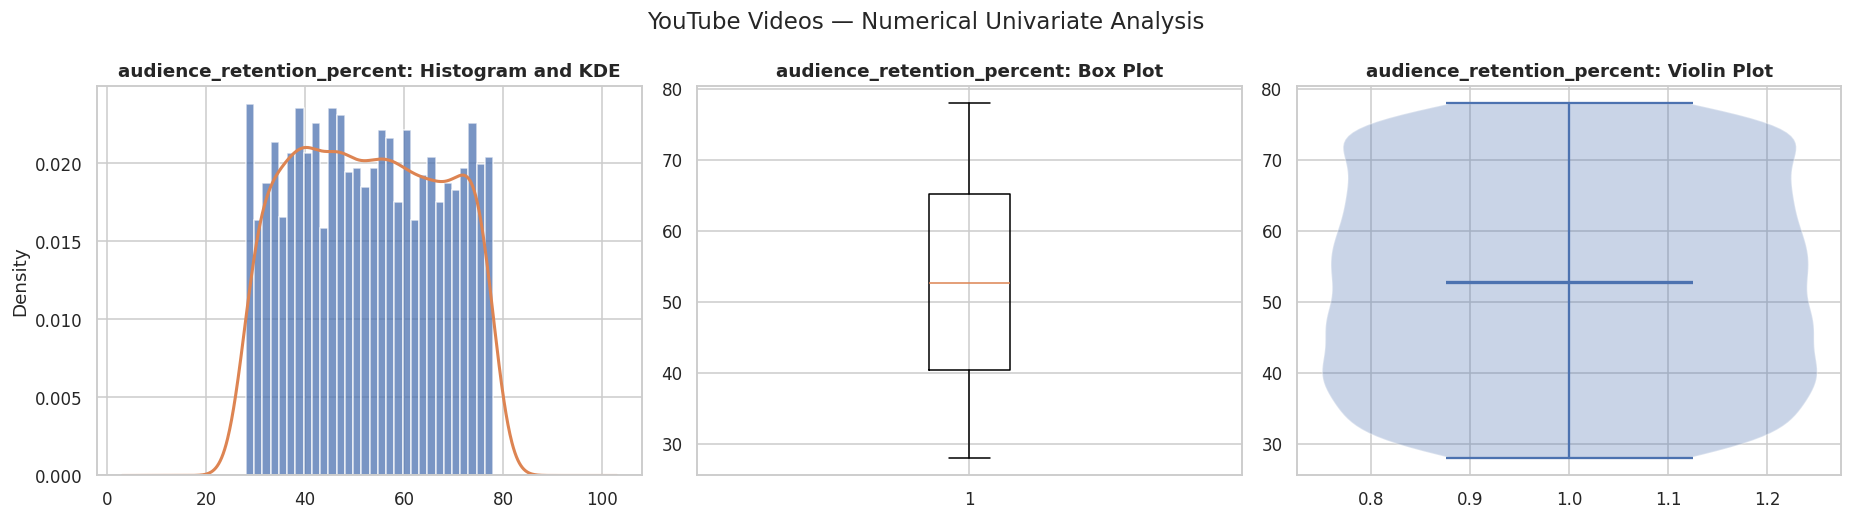

audience_retention_percent: skew=0.032, std=14.396, IQR=24.825


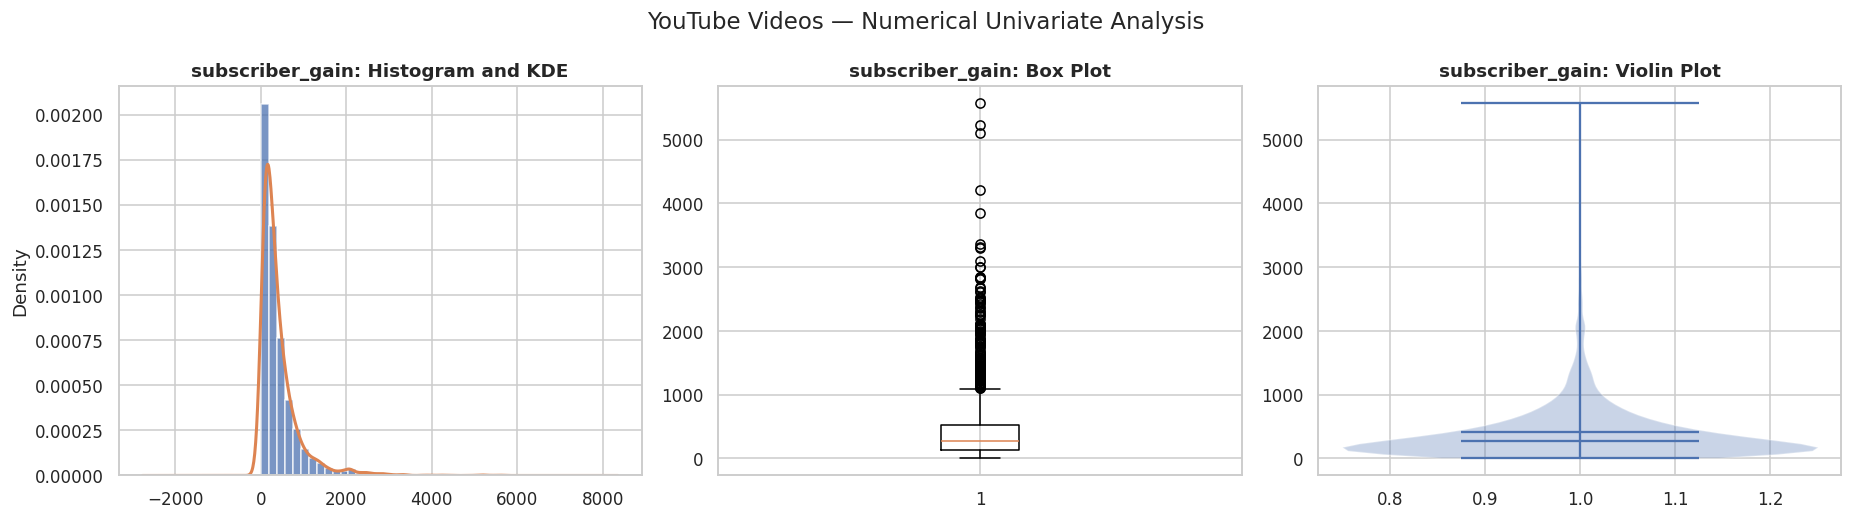

subscriber_gain: skew=3.526, std=487.969, IQR=387.000


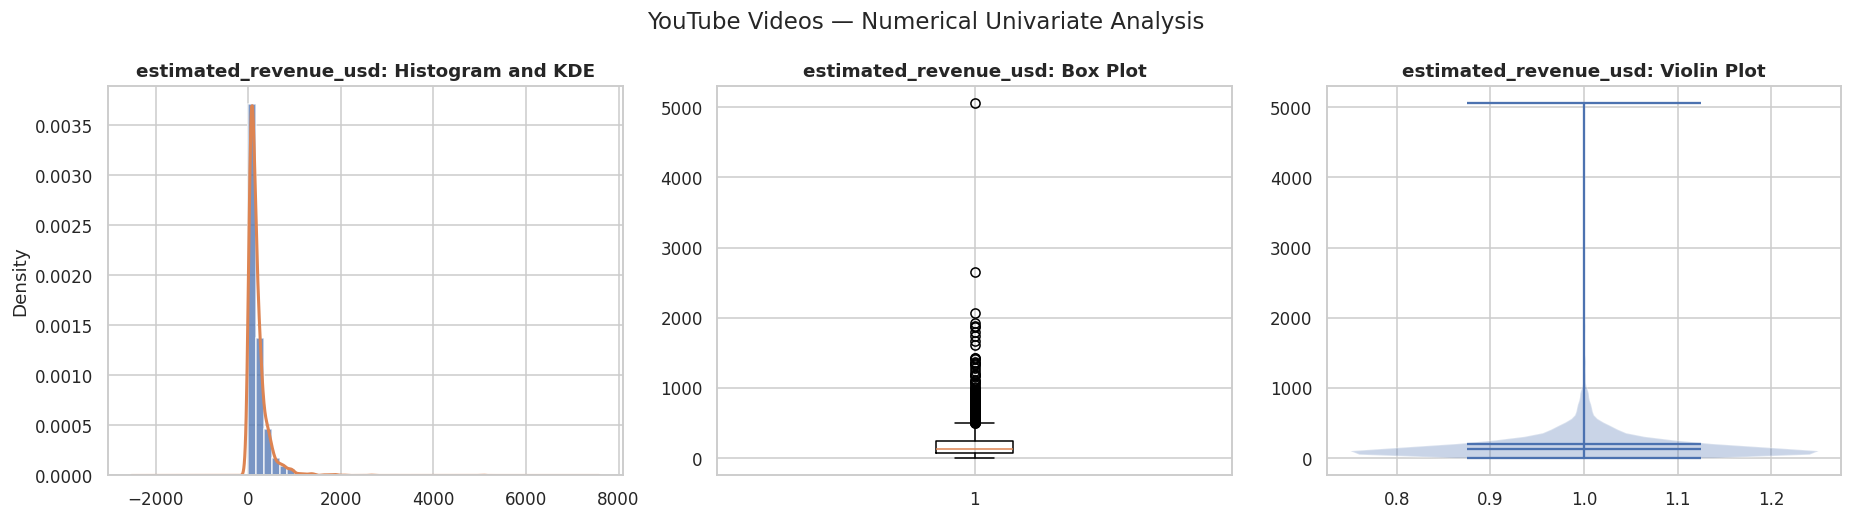

estimated_revenue_usd: skew=6.042, std=239.432, IQR=174.048


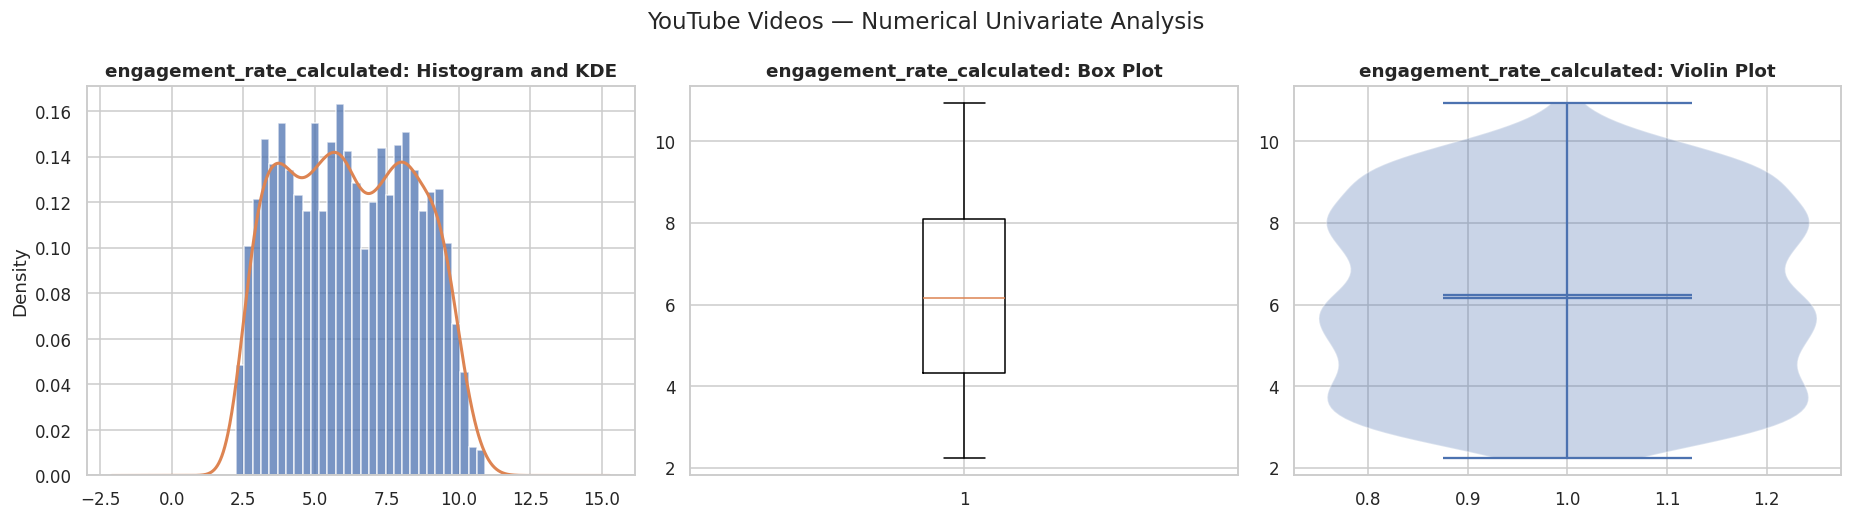

engagement_rate_calculated: skew=0.050, std=2.187, IQR=3.761


,Count,Percentage
media_type,,
Reel,1408,56.320
Image,615,24.600
Carousel,477,19.080


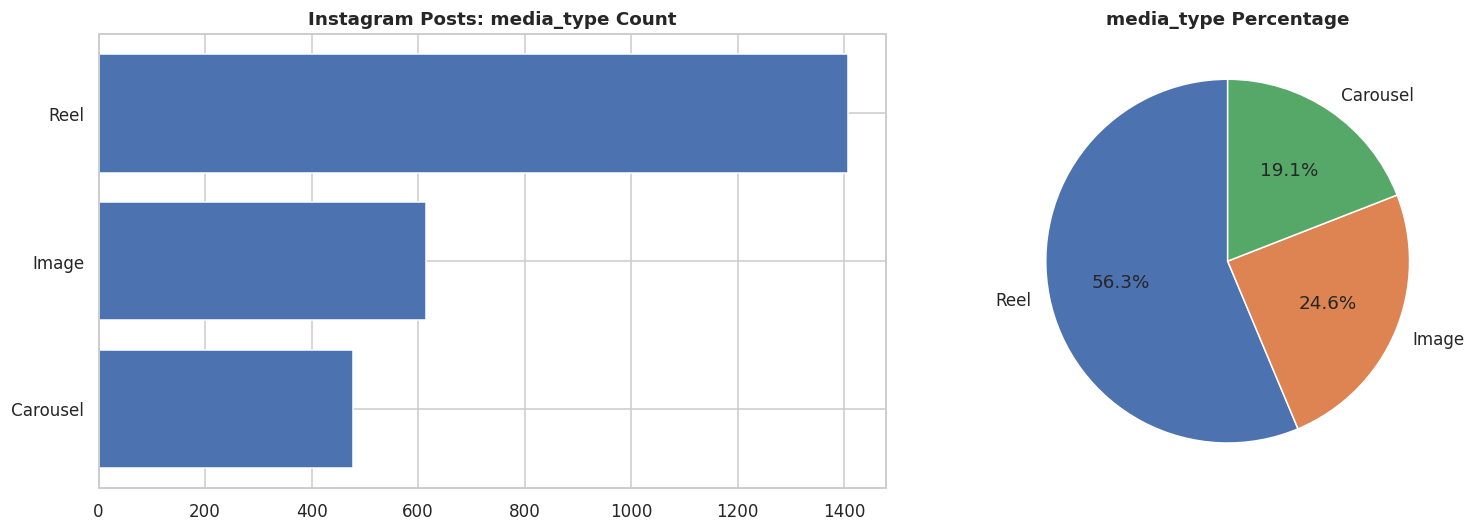

Most frequent: Reel 1408
Least frequent: Carousel 477


,Count,Percentage
campaign,,
Festival,345,13.800
Behind the Scenes,337,13.480
Software Update,326,13.040
Launch,315,12.600
Photography,301,12.040
Community,300,12.000
Giveaway,298,11.920
Feature Highlight,278,11.120


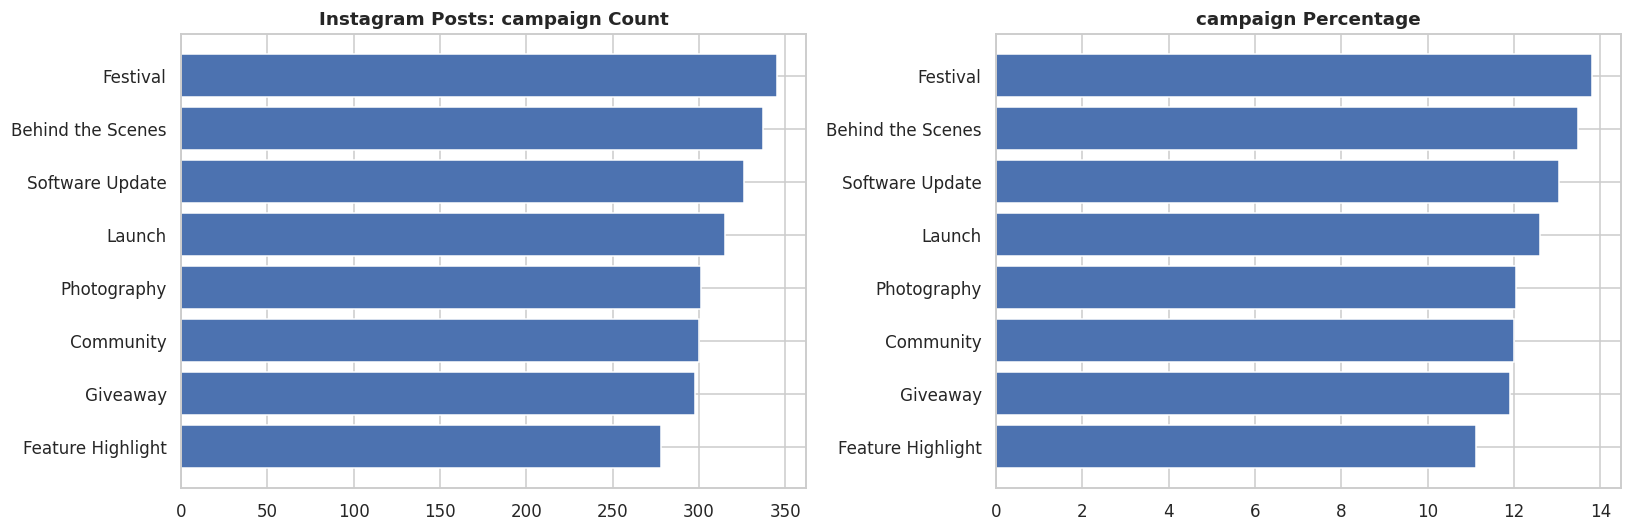

Most frequent: Festival 345
Least frequent: Feature Highlight 278


,Count,Percentage
product,,
Nothing OS,403,16.120
Phone (3),372,14.880
Phone (3a),372,14.880
Accessories,361,14.440
Ear (2),356,14.240
Ear,332,13.280
CMF Phone,304,12.160


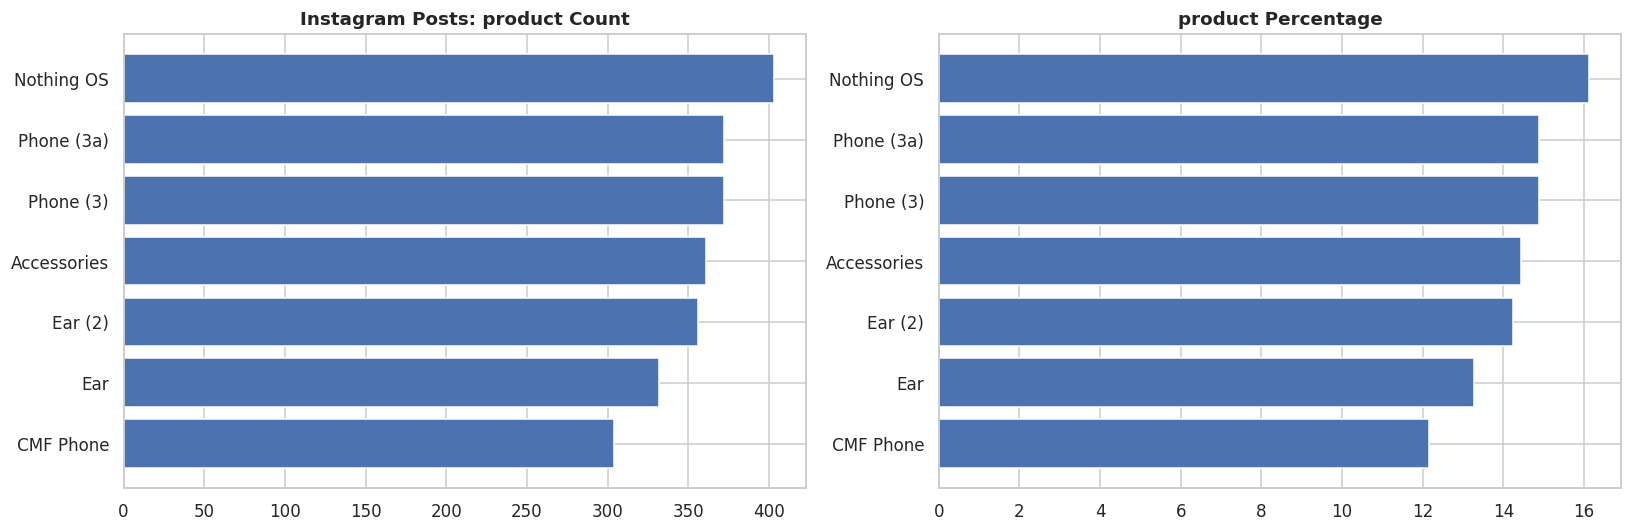

Most frequent: Nothing OS 403
Least frequent: CMF Phone 304


,Count,Percentage
audience_region,,
South,723,28.920
North,567,22.680
West,517,20.680
East,396,15.840
Central,297,11.880


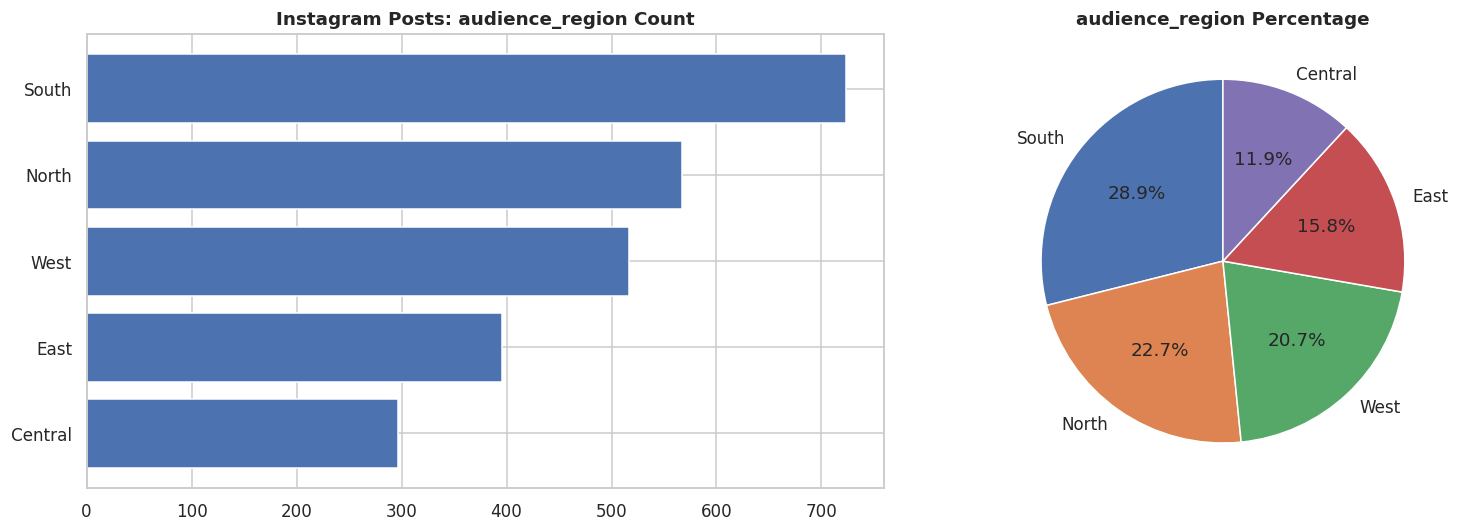

Most frequent: South 723
Least frequent: Central 297


,Count,Percentage
weekday,,
Tuesday,374,14.960
Sunday,369,14.760
Wednesday,365,14.600
Monday,364,14.560
Saturday,350,14.000
Friday,349,13.960
Thursday,329,13.160


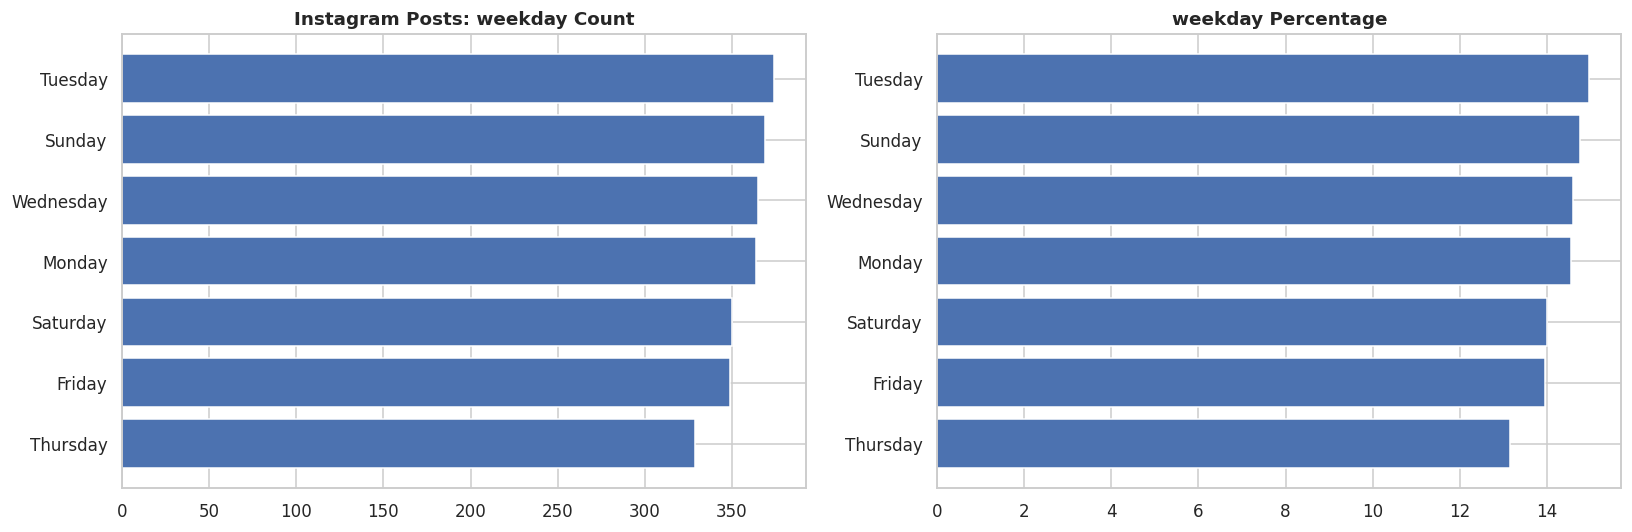

Most frequent: Tuesday 374
Least frequent: Thursday 329


,Count,Percentage
is_promoted,,
0,2044,81.760
1,456,18.240


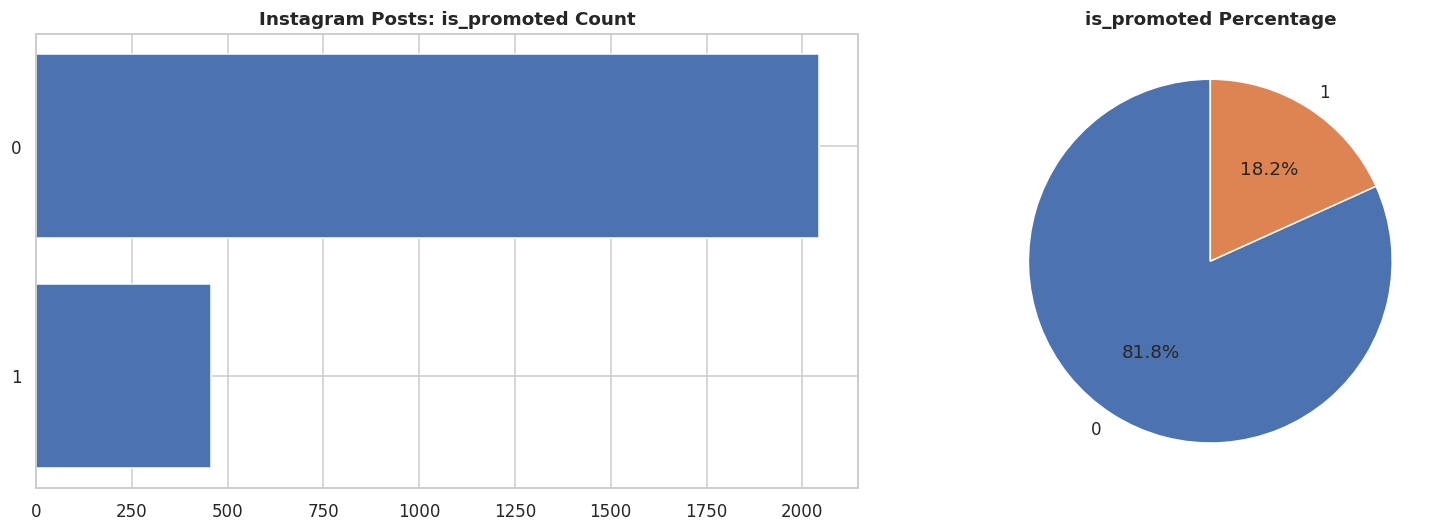

Most frequent: 0 2044
Least frequent: 1 456


,Count,Percentage
category,,
Review,333,13.320
Community,329,13.160
Behind the Scenes,326,13.040
Camera,317,12.680
Launch,316,12.640
Shorts,312,12.480
Software,289,11.560
Tips,278,11.120


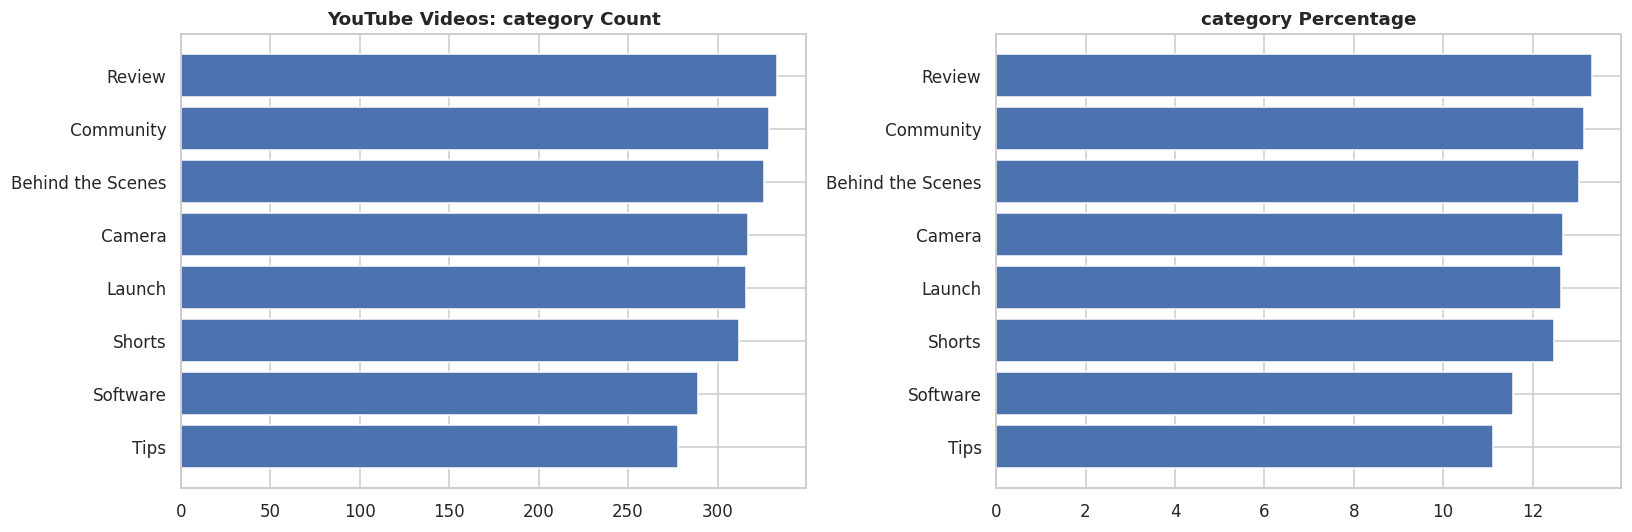

Most frequent: Review 333
Least frequent: Tips 278


,Count,Percentage
product,,
Nothing OS,448,17.920
Ear (2),427,17.080
Accessories,424,16.960
Phone (3a),411,16.440
CMF Phone,399,15.960
Phone (3),391,15.640


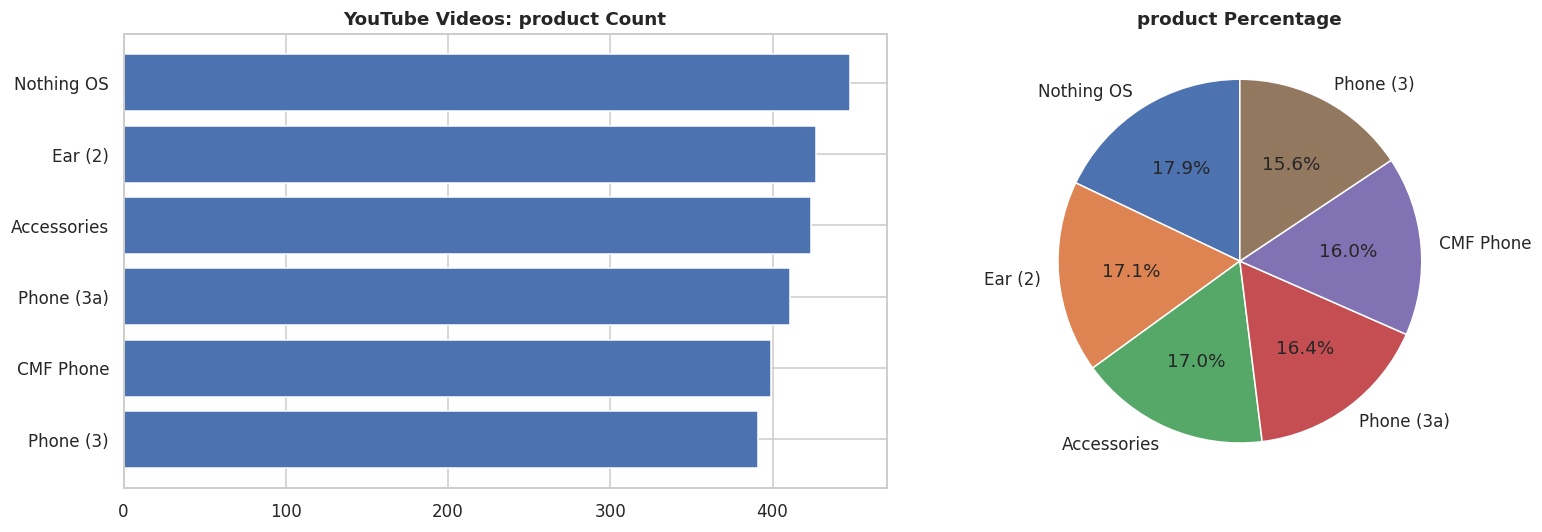

Most frequent: Nothing OS 448
Least frequent: Phone (3) 391


,Count,Percentage
traffic_source,,
Suggested,522,20.880
Notifications,520,20.800
External,518,20.720
Browse,498,19.920
Search,442,17.680


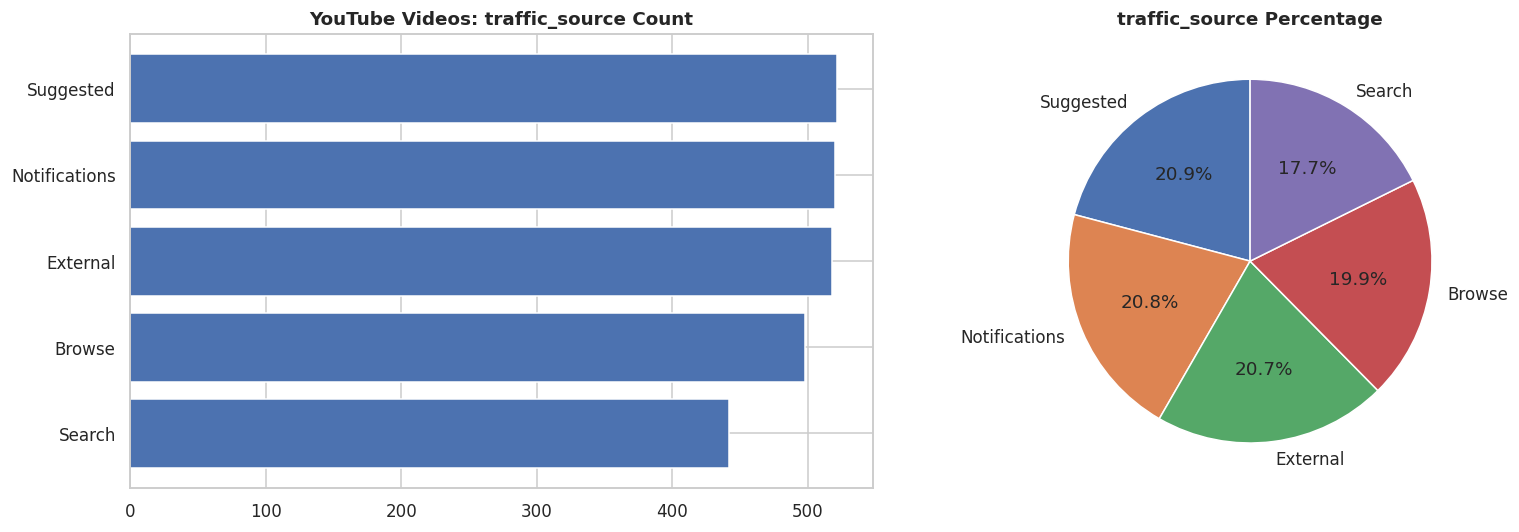

Most frequent: Suggested 522
Least frequent: Search 442


,Count,Percentage
device,,
Tablet,641,25.640
Mobile,635,25.400
Desktop,614,24.560
TV,610,24.400


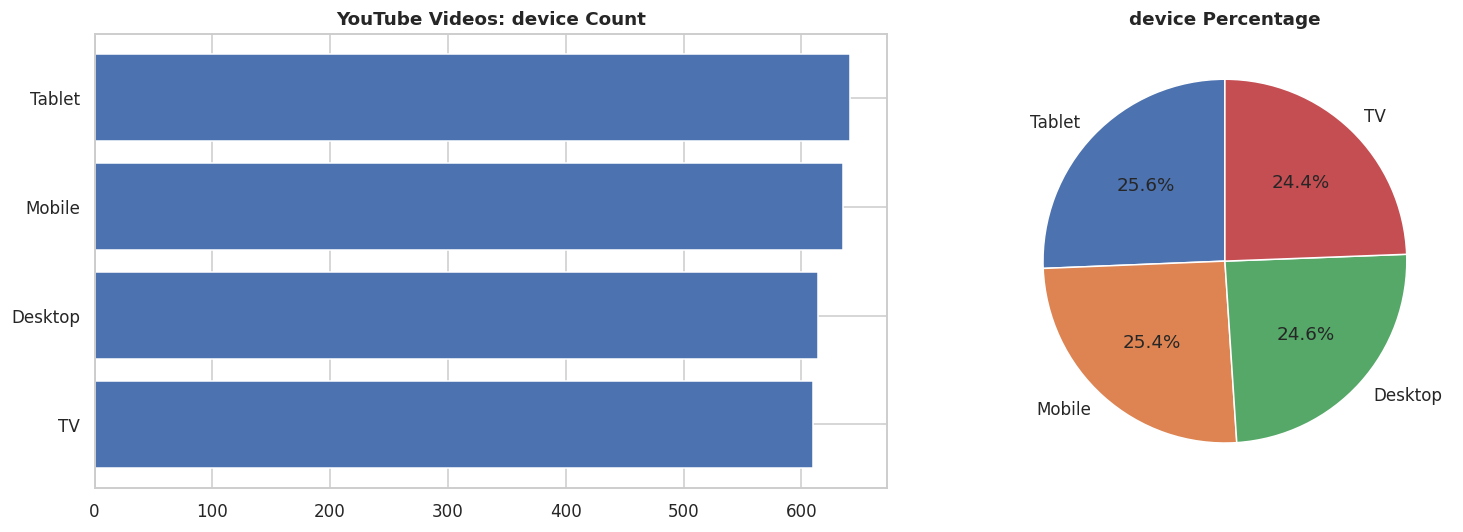

Most frequent: Tablet 641
Least frequent: TV 610


,Count,Percentage
country,,
Singapore,516,20.640
UK,510,20.400
India,499,19.960
USA,493,19.720
UAE,482,19.280


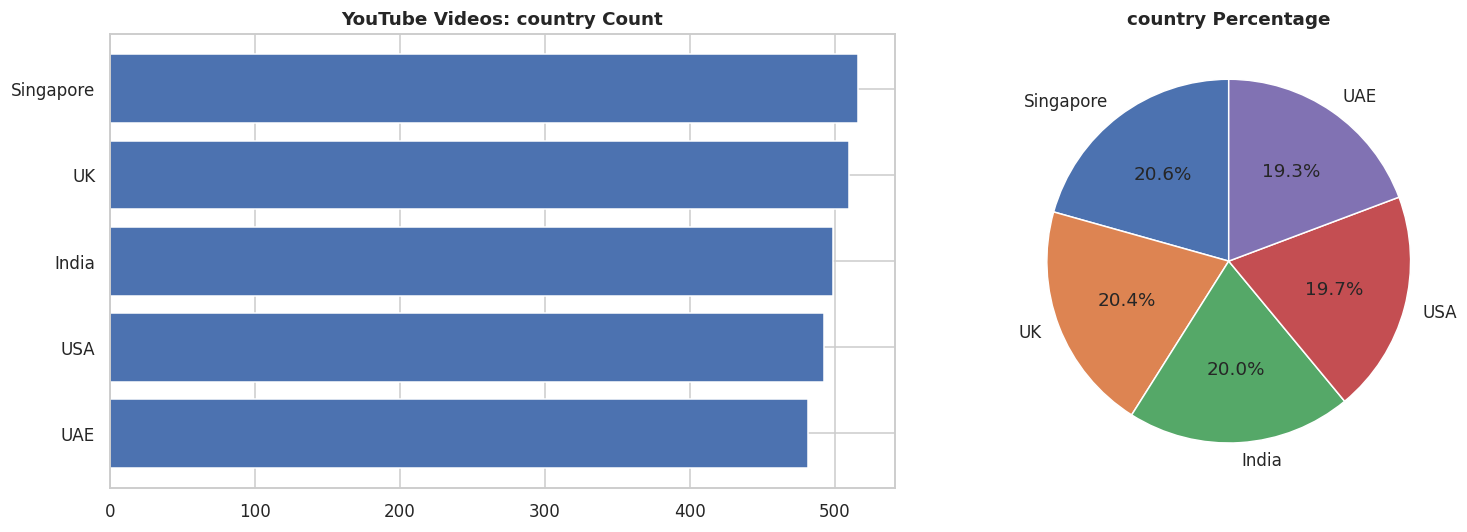

Most frequent: Singapore 516
Least frequent: UAE 482


,Count,Percentage
weekday,,
Wednesday,371,14.840
Saturday,370,14.800
Monday,368,14.720
Friday,360,14.400
Sunday,360,14.400
Tuesday,359,14.360
Thursday,312,12.480


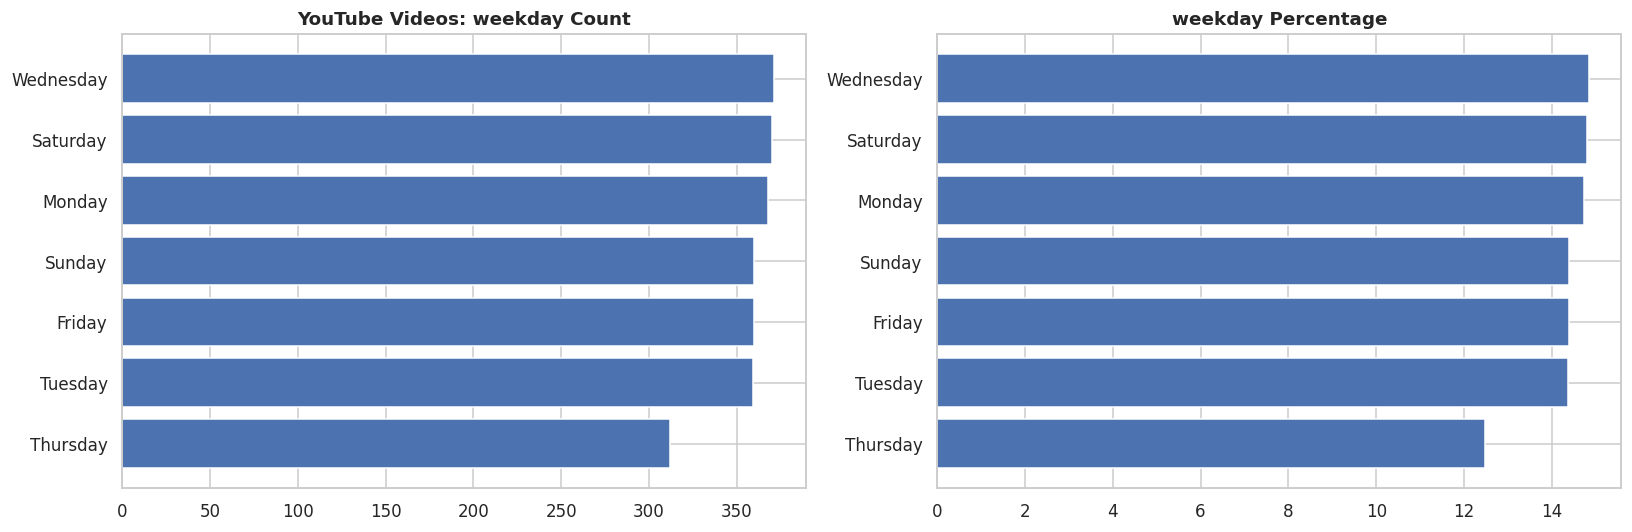

Most frequent: Wednesday 371
Least frequent: Thursday 312


,Count,Percentage
sentiment,,
Positive,1899,63.300
Neutral,624,20.800
Negative,477,15.900


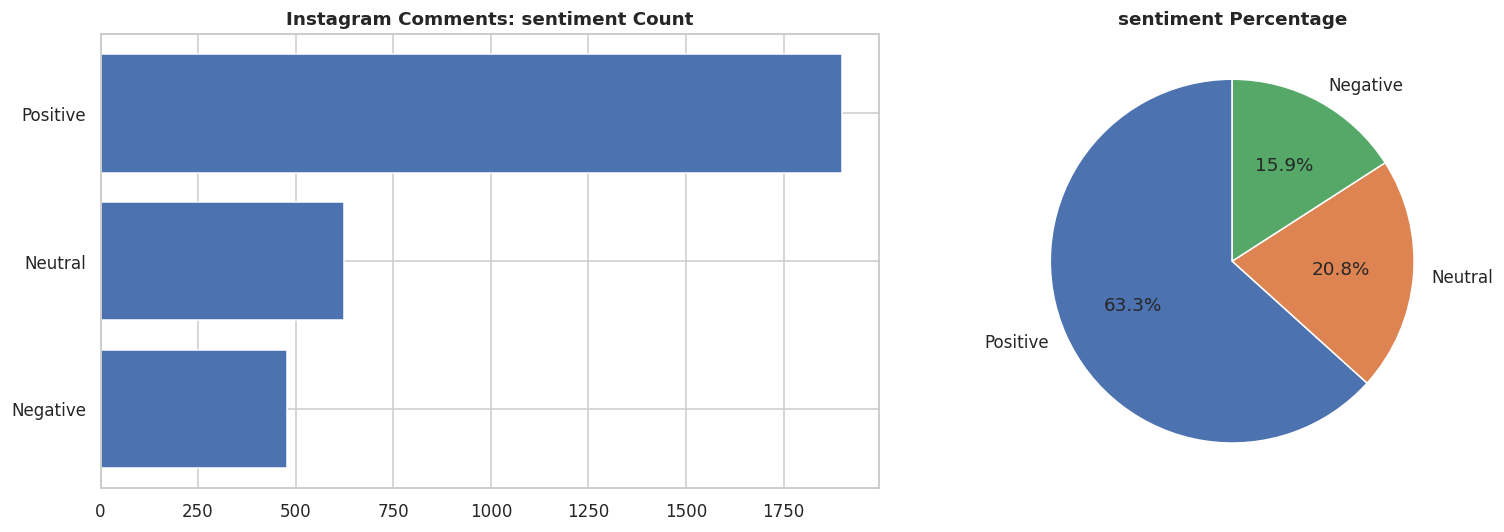

Most frequent: Positive 1899
Least frequent: Negative 477


,Count,Percentage
emotion,,
Curious,614,20.470
Excited,614,20.470
Neutral,605,20.170
Frustrated,593,19.770
Happy,574,19.130


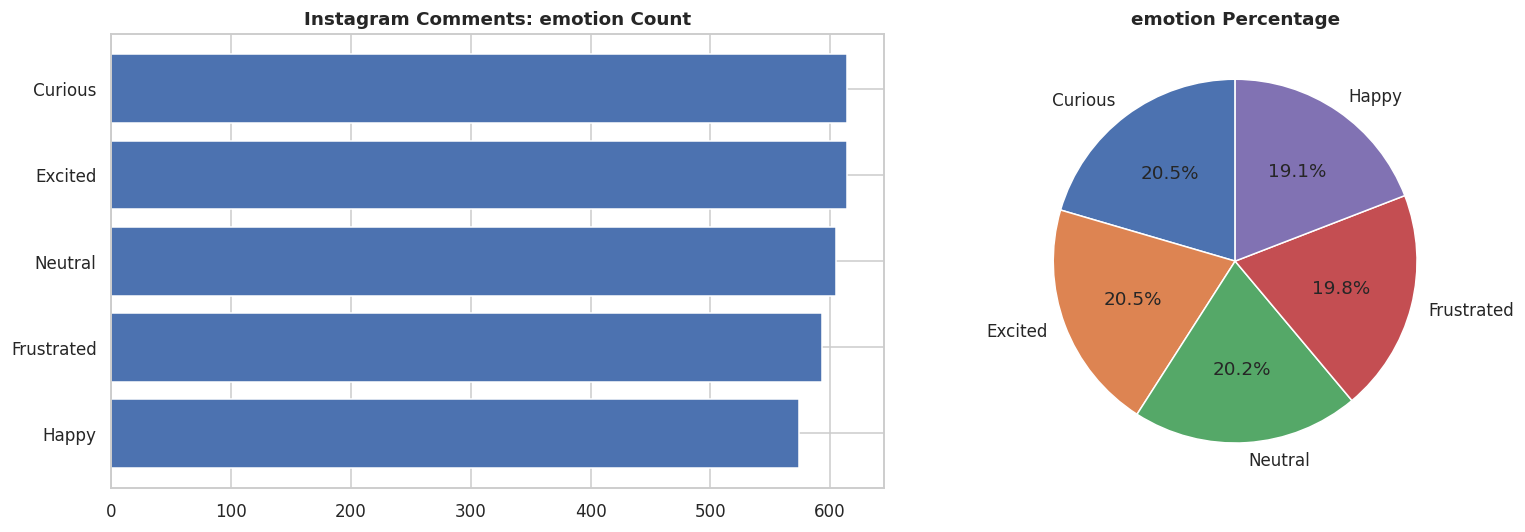

Most frequent: Curious 614
Least frequent: Happy 574


,Count,Percentage
topic,,
Camera,367,12.230
Price,362,12.070
Performance,353,11.770
Design,340,11.330
Delivery,330,11.000
Audio,322,10.730
Battery,314,10.470
Software,312,10.400
Availability,300,10.000


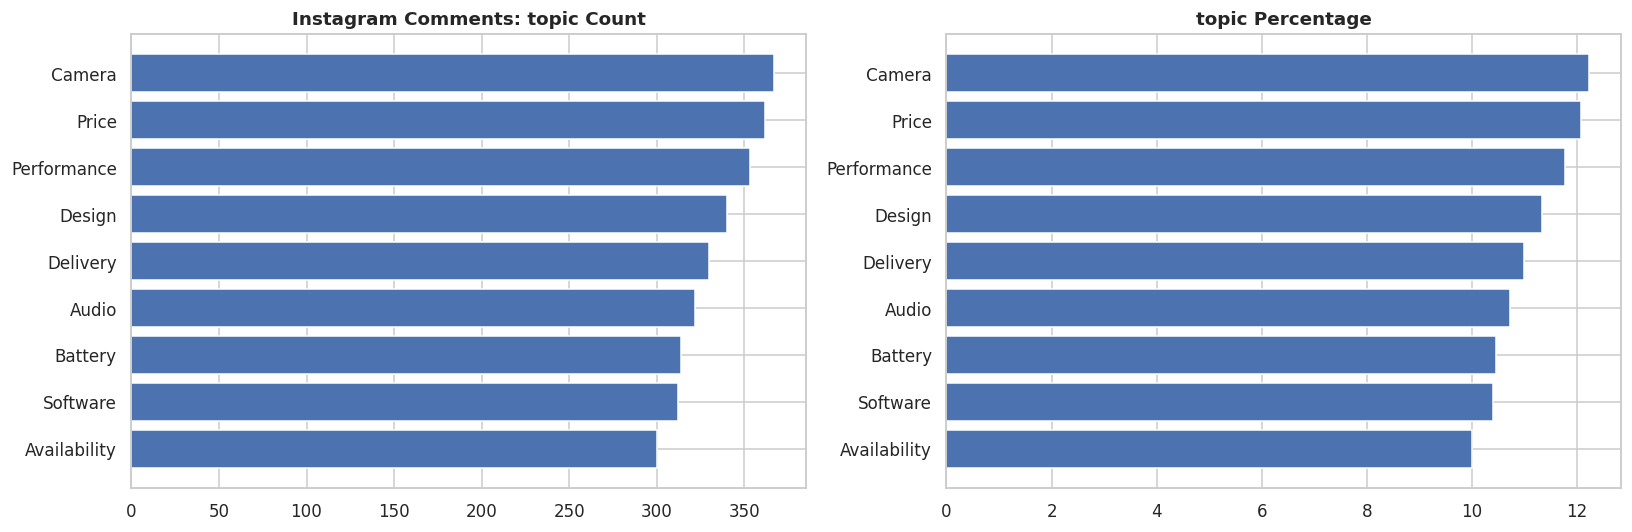

Most frequent: Camera 367
Least frequent: Availability 300


,Count,Percentage
purchase_intent,,
Medium,1285,42.830
Low,1030,34.330
High,685,22.830


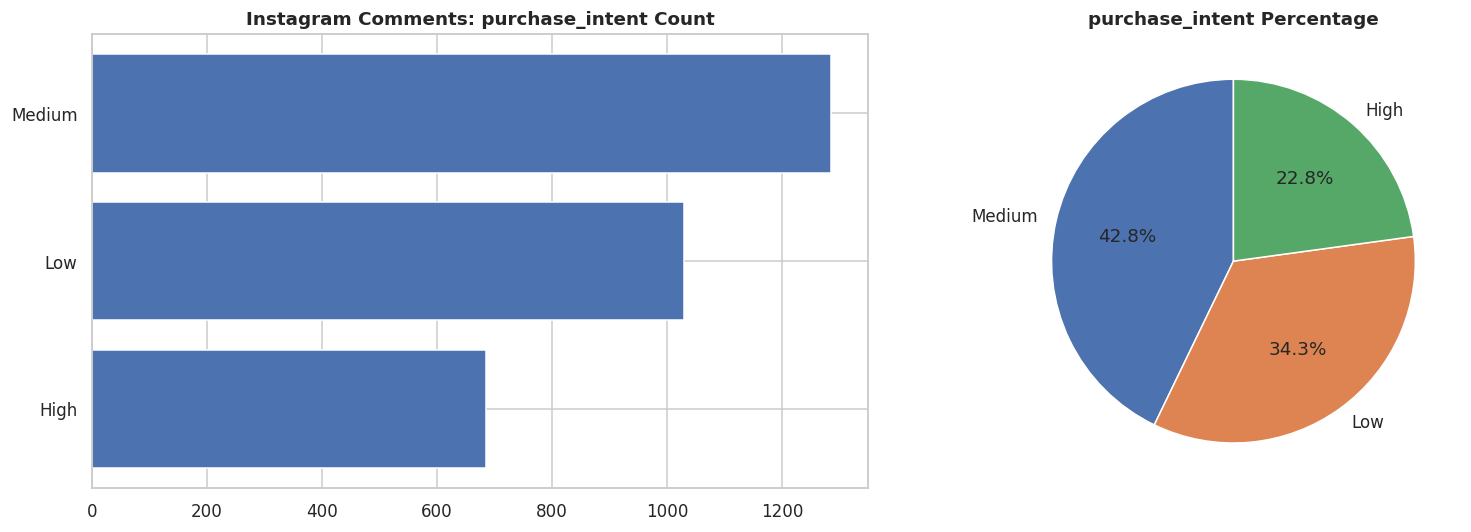

Most frequent: Medium 1285
Least frequent: High 685


,Count,Percentage
region,,
West,630,21.000
North,613,20.430
South,598,19.930
Central,582,19.400
East,577,19.230


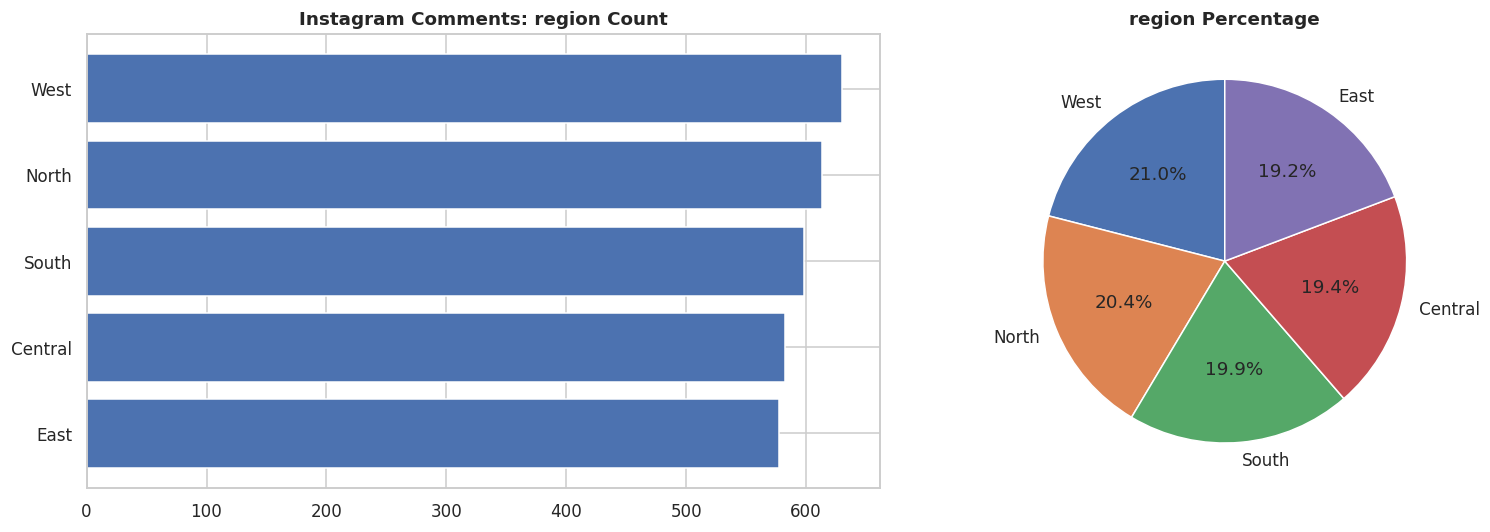

Most frequent: West 630
Least frequent: East 577


,Count,Percentage
complaint_category,,
Not Applicable,2141,71.370
Battery,241,8.030
Pricing,231,7.700
Software,215,7.170
Delivery,172,5.730


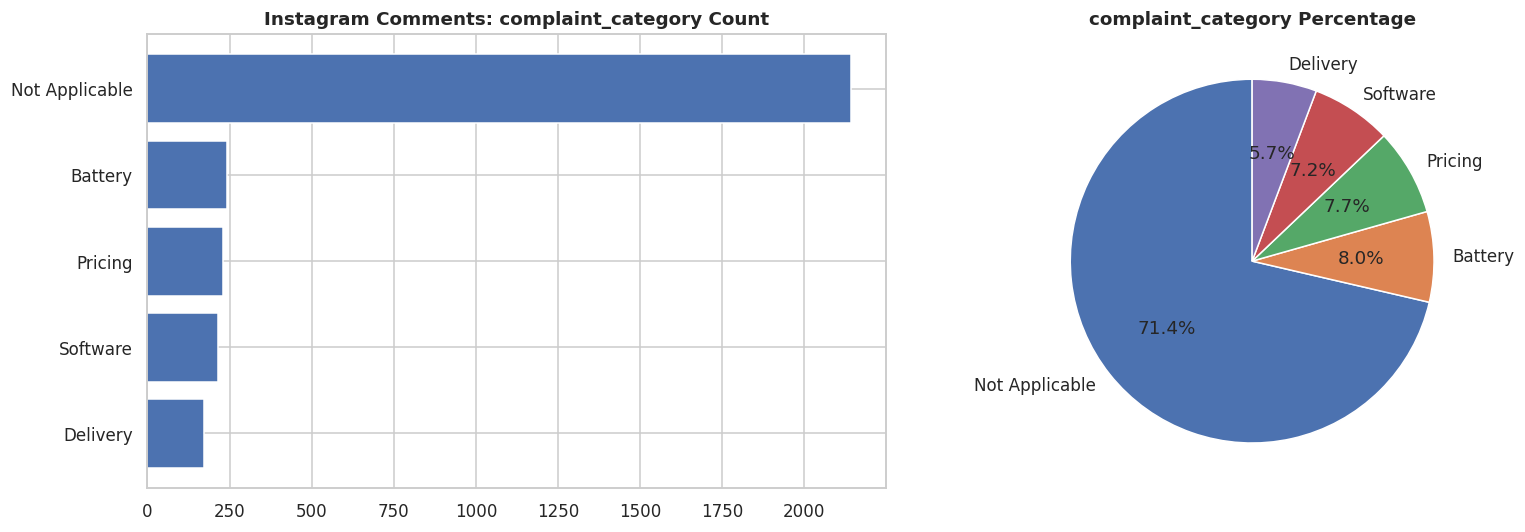

Most frequent: Not Applicable 2141
Least frequent: Delivery 172


In [10]:
def numerical_univariate(df, columns, name):
    for c in [x for x in columns if x in df.columns]:
        v = df[c].dropna()
        fig, axes = plt.subplots(1,3,figsize=(17,4.8))
        axes[0].hist(v, bins=30, density=True, alpha=0.75)
        if v.nunique() > 1:
            v.plot(kind='kde', ax=axes[0], linewidth=2)
        axes[0].set_title(f'{c}: Histogram and KDE')
        axes[1].boxplot(v)
        axes[1].set_title(f'{c}: Box Plot')
        axes[2].violinplot(v, showmeans=True, showmedians=True)
        axes[2].set_title(f'{c}: Violin Plot')
        fig.suptitle(f'{name} — Numerical Univariate Analysis', fontsize=15)
        plt.tight_layout()
        plt.show()
        print(f'{c}: skew={v.skew():.3f}, std={v.std():.3f}, IQR={(v.quantile(.75)-v.quantile(.25)):.3f}')

def categorical_univariate(df, columns, name):
    for c in [x for x in columns if x in df.columns]:
        counts = df[c].value_counts(dropna=False)
        pct = counts / counts.sum() * 100
        display(pd.DataFrame({'Count': counts, 'Percentage': pct.round(2)}))
        fig, axes = plt.subplots(1,2,figsize=(15,5))
        p = counts.head(15).sort_values()
        axes[0].barh(p.index.astype(str), p.values)
        axes[0].set_title(f'{name}: {c} Count')
        if len(counts) <= 6:
            axes[1].pie(counts.values, labels=counts.index.astype(str), autopct='%1.1f%%', startangle=90)
            axes[1].set_title(f'{c} Percentage')
        else:
            q = pct.head(15).sort_values()
            axes[1].barh(q.index.astype(str), q.values)
            axes[1].set_title(f'{c} Percentage')
        plt.tight_layout()
        plt.show()
        print('Most frequent:', counts.index[0], int(counts.iloc[0]))
        print('Least frequent:', counts.index[-1], int(counts.iloc[-1]))

numerical_univariate(instagram_posts, ['reach','impressions','likes','comments','shares','saves','engagement_rate_calculated','viral_score'], 'Instagram Posts')
numerical_univariate(youtube, ['views','likes','comments','shares','duration_seconds','audience_retention_percent','subscriber_gain','estimated_revenue_usd','engagement_rate_calculated'], 'YouTube Videos')
categorical_univariate(instagram_posts, ['media_type','campaign','product','audience_region','weekday','is_promoted'], 'Instagram Posts')
categorical_univariate(youtube, ['category','product','traffic_source','device','country','weekday'], 'YouTube Videos')
categorical_univariate(instagram_comments, ['sentiment','emotion','topic','purchase_intent','region','complaint_category'], 'Instagram Comments')

## **11. Bivariate Analysis**

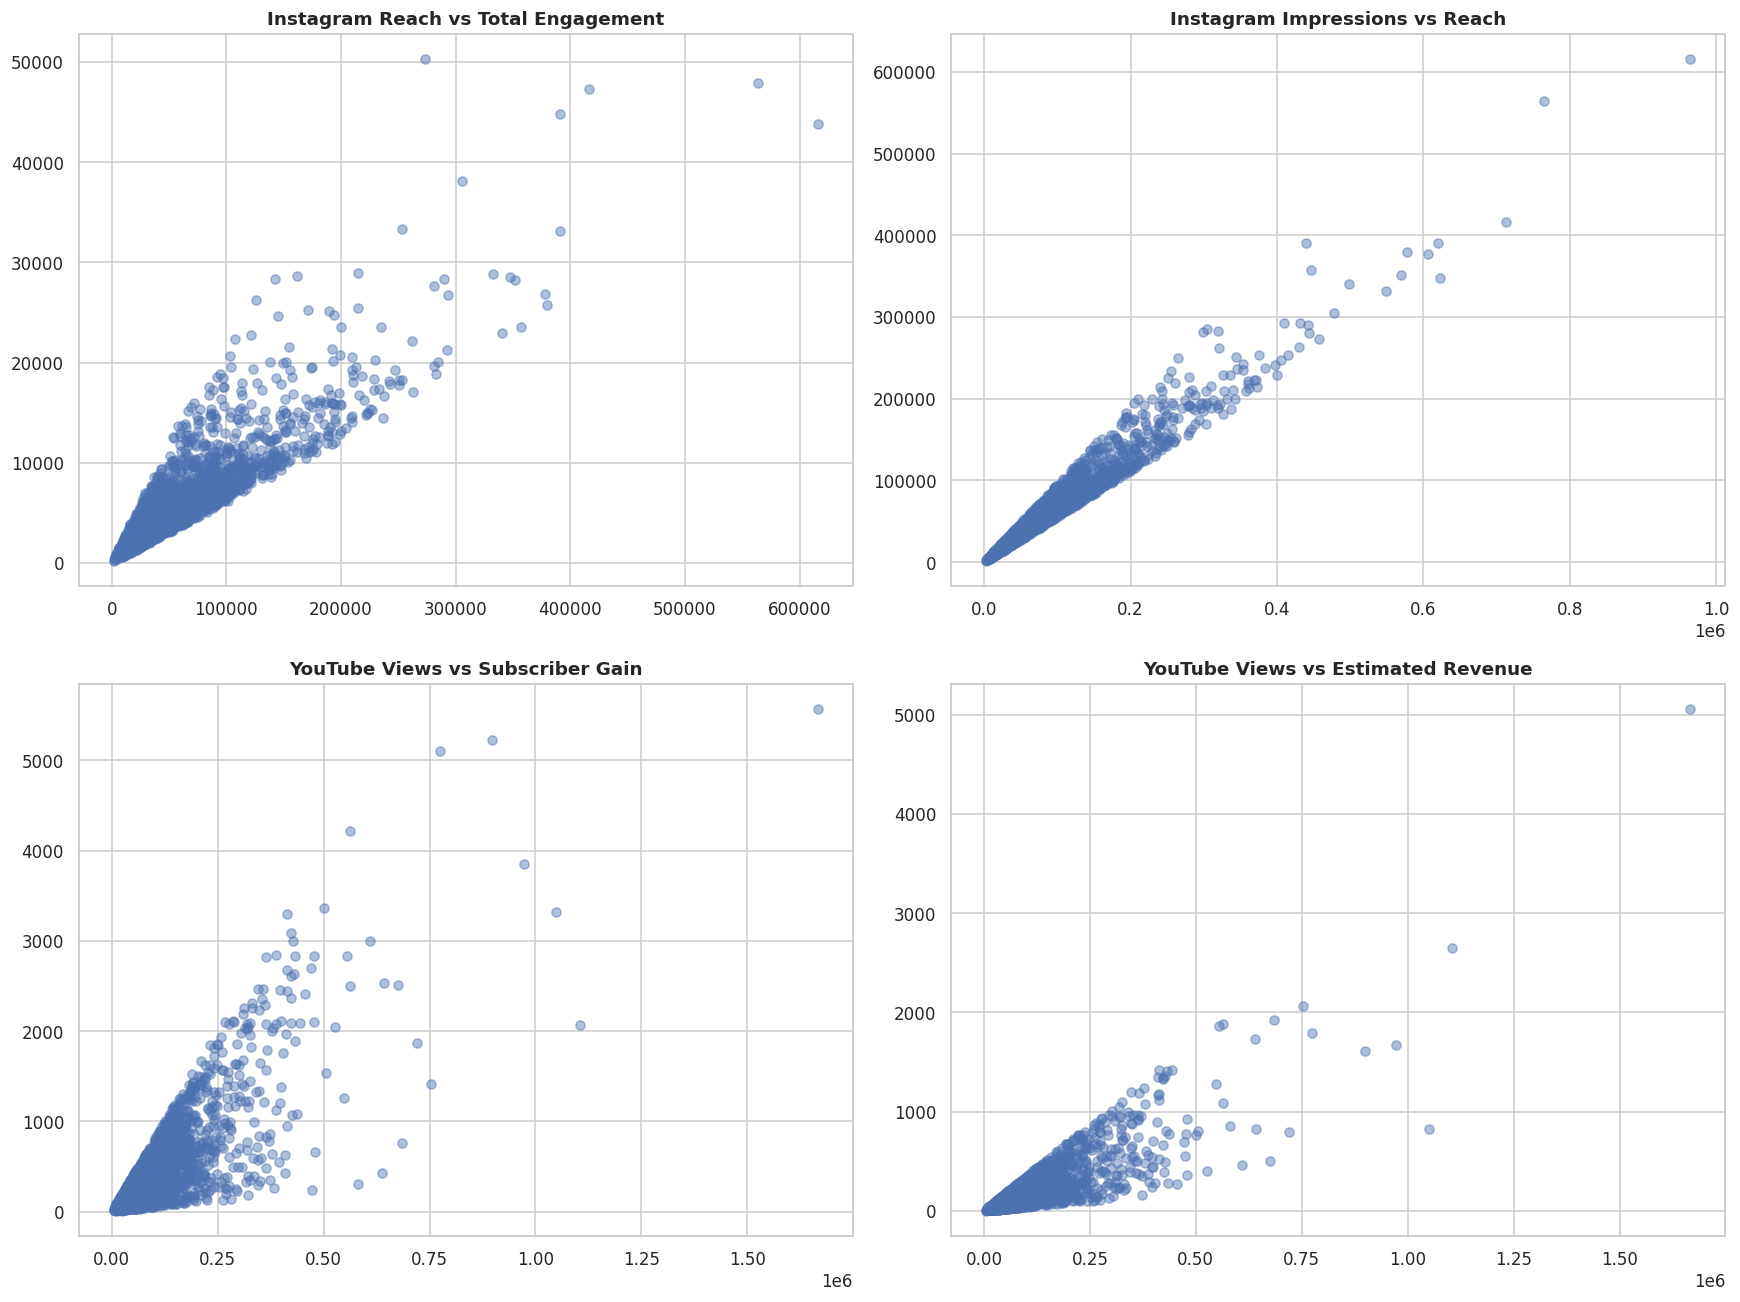

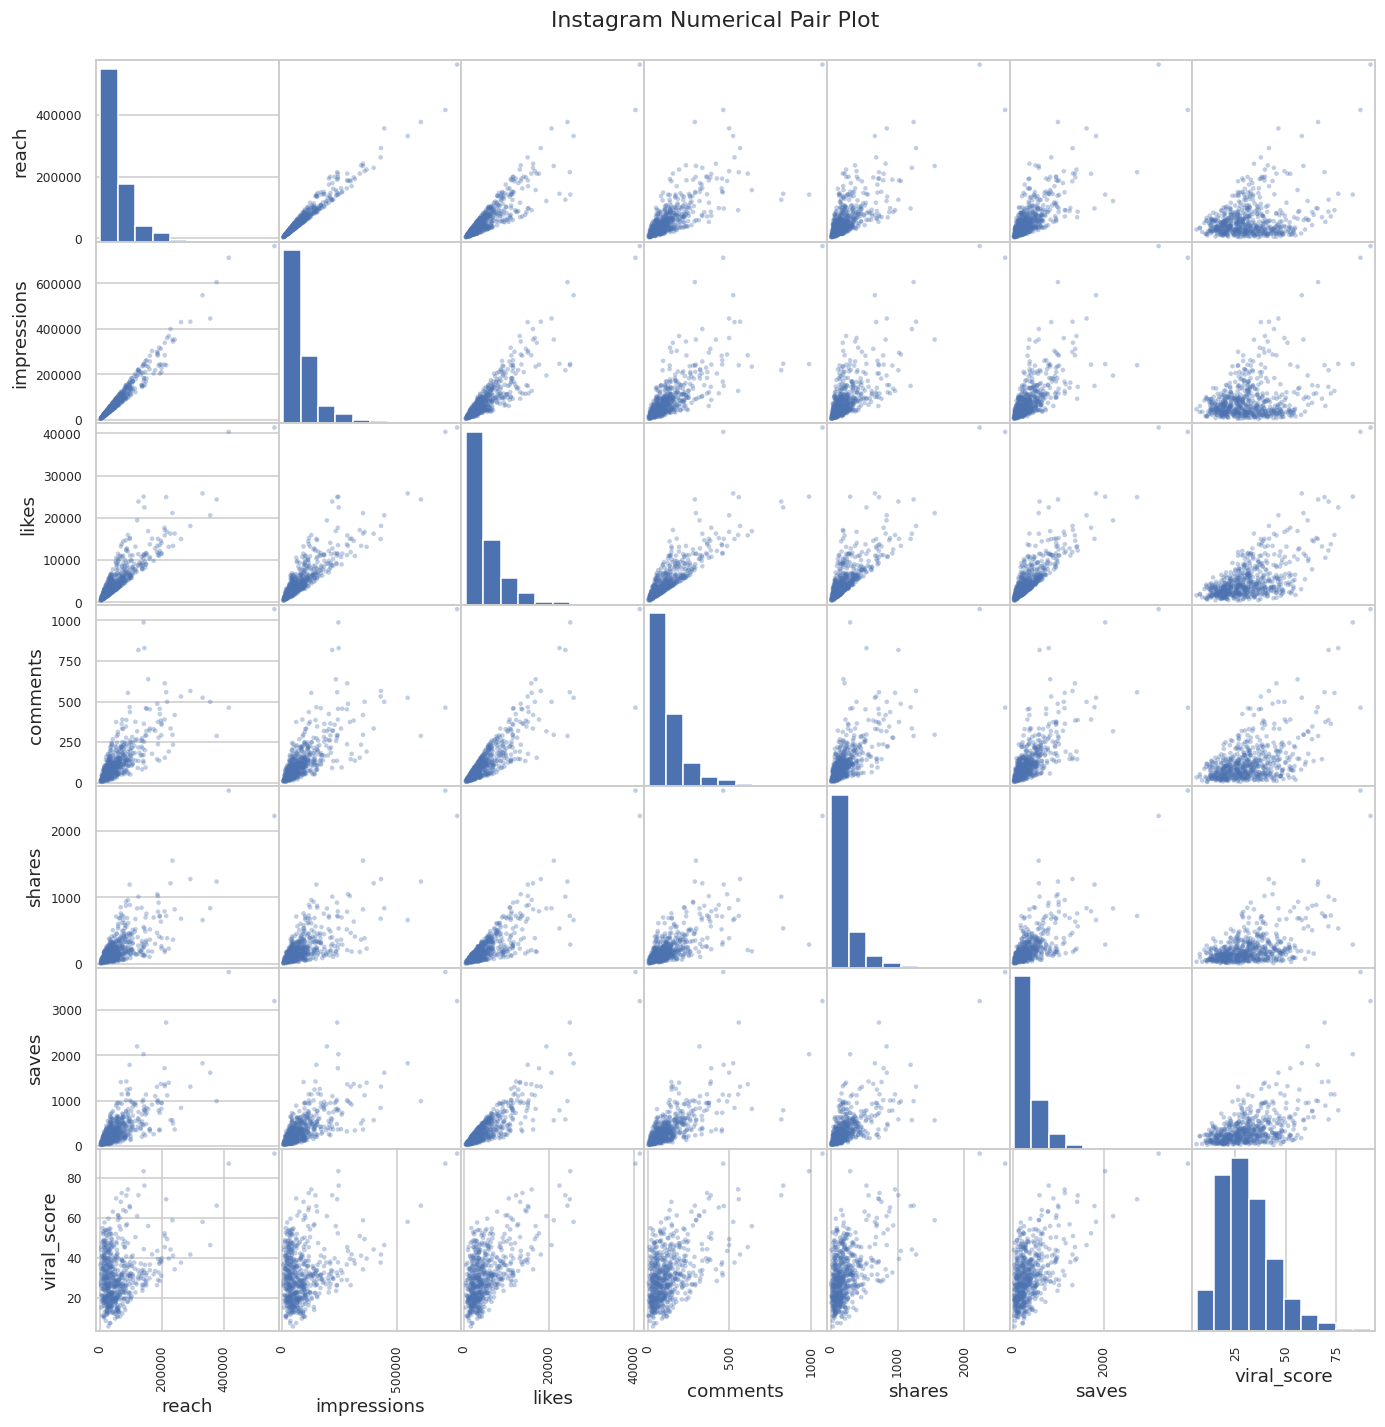

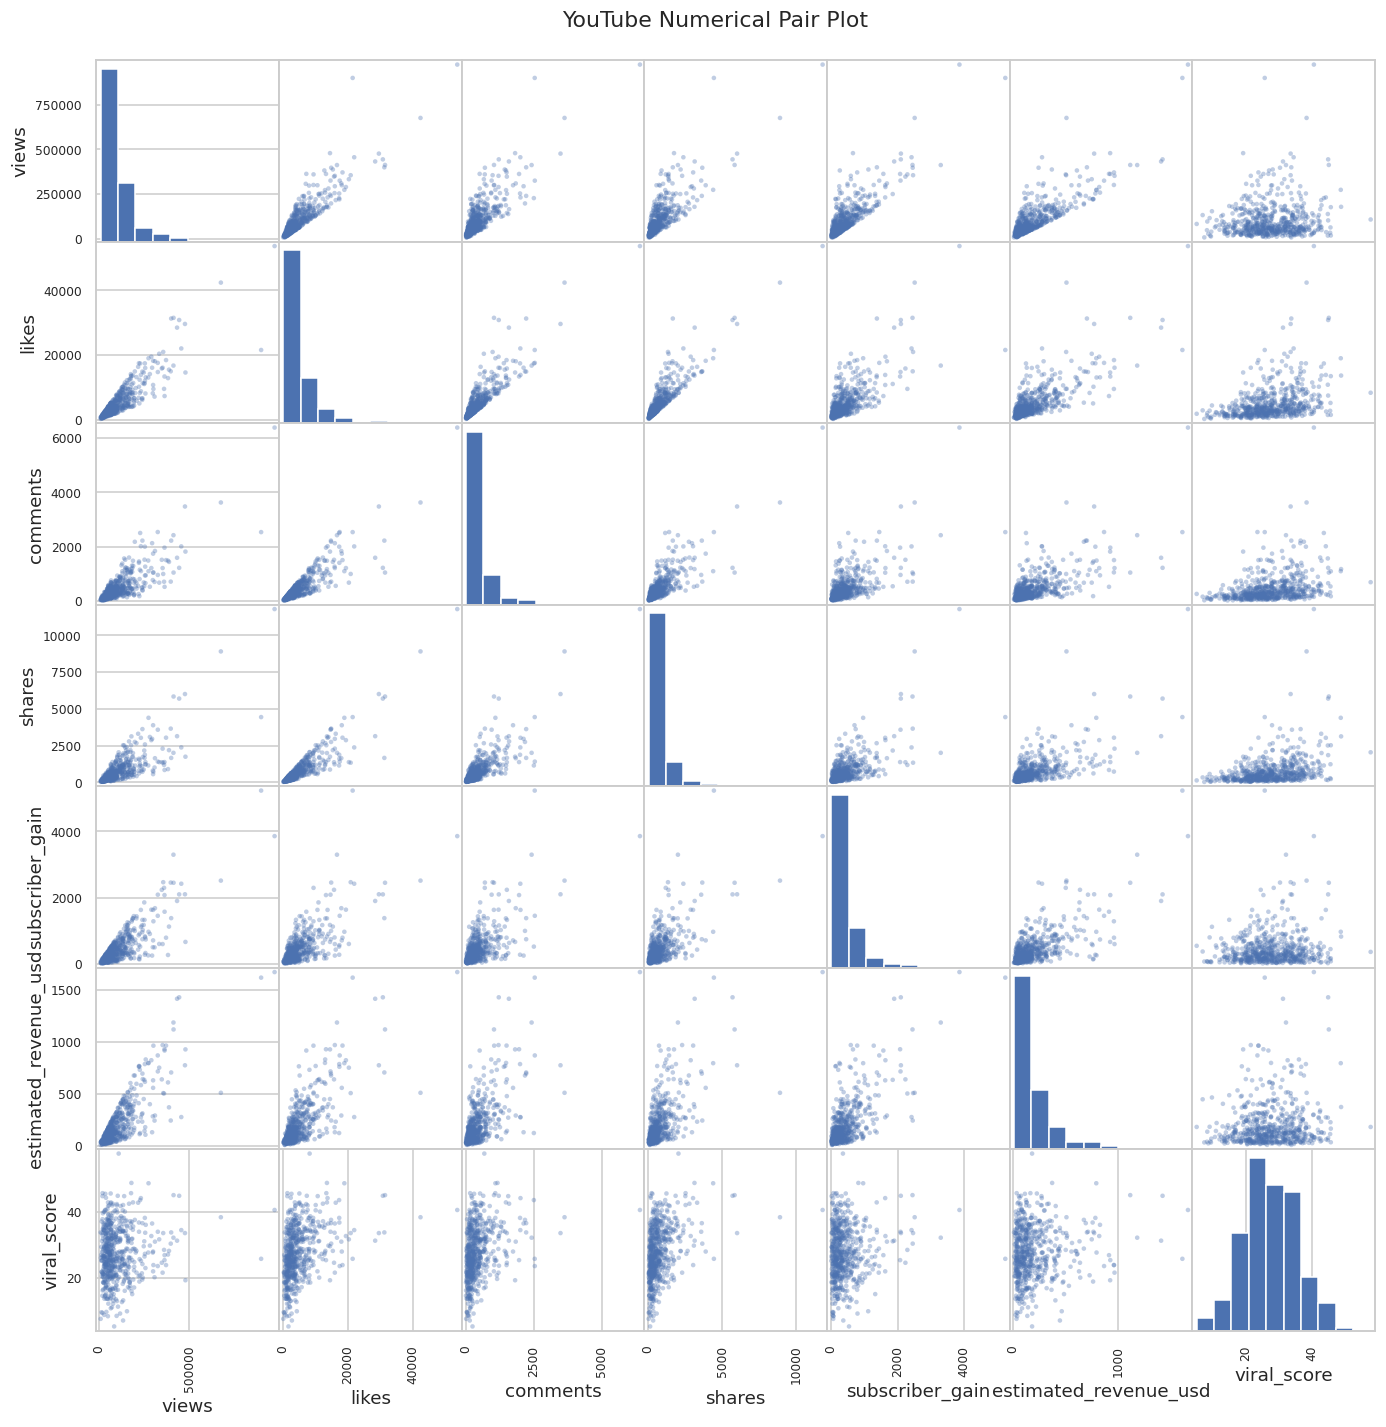

,count,mean,median
media_type,,,
Carousel,477,11.523,10.022
Image,615,11.295,9.887
Reel,1408,11.164,9.767


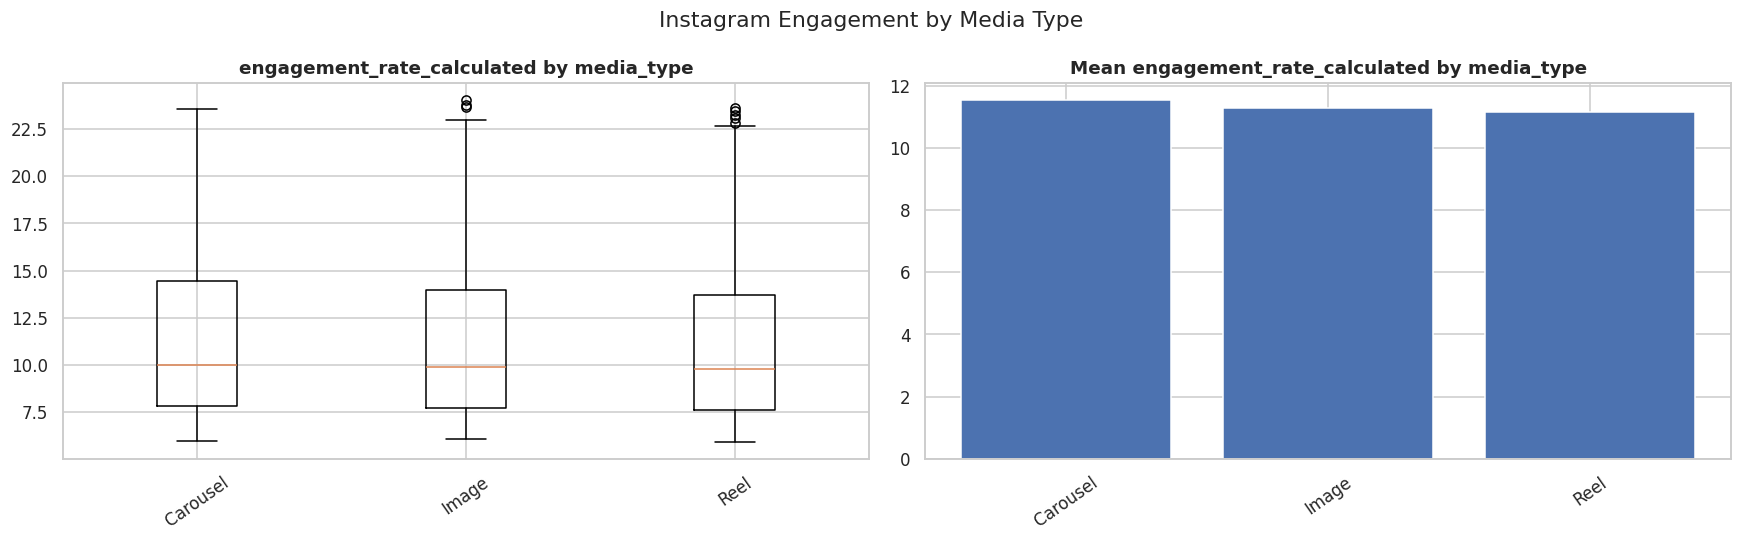

,count,mean,median
campaign,,,
Software Update,326,31.868,29.300
Giveaway,298,31.231,29.550
Photography,301,30.993,29.400
Feature Highlight,278,30.867,29.200
Community,300,30.515,29.300
Festival,345,30.296,28.300
Launch,315,29.800,28.500
Behind the Scenes,337,29.236,27.600


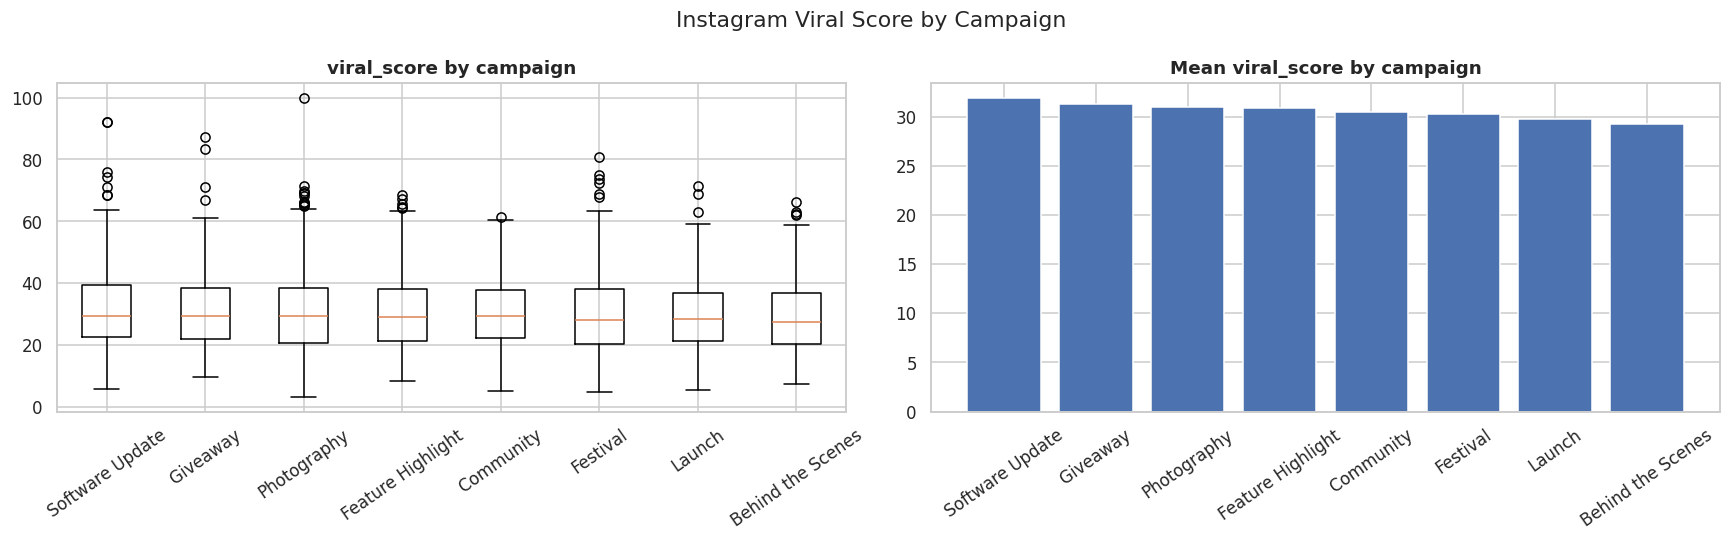

,count,mean,median
category,,,
Tips,278,"113,358.209","75,081.500"
Launch,316,"104,701.696","75,398.500"
Shorts,312,"102,125.032","70,517.500"
Review,333,"101,991.634","73,513.000"
Software,289,"100,937.896","72,454.000"
Community,329,"99,567.255","71,271.000"
Camera,317,"97,431.858","64,485.000"
Behind the Scenes,326,"96,029.558","69,575.500"


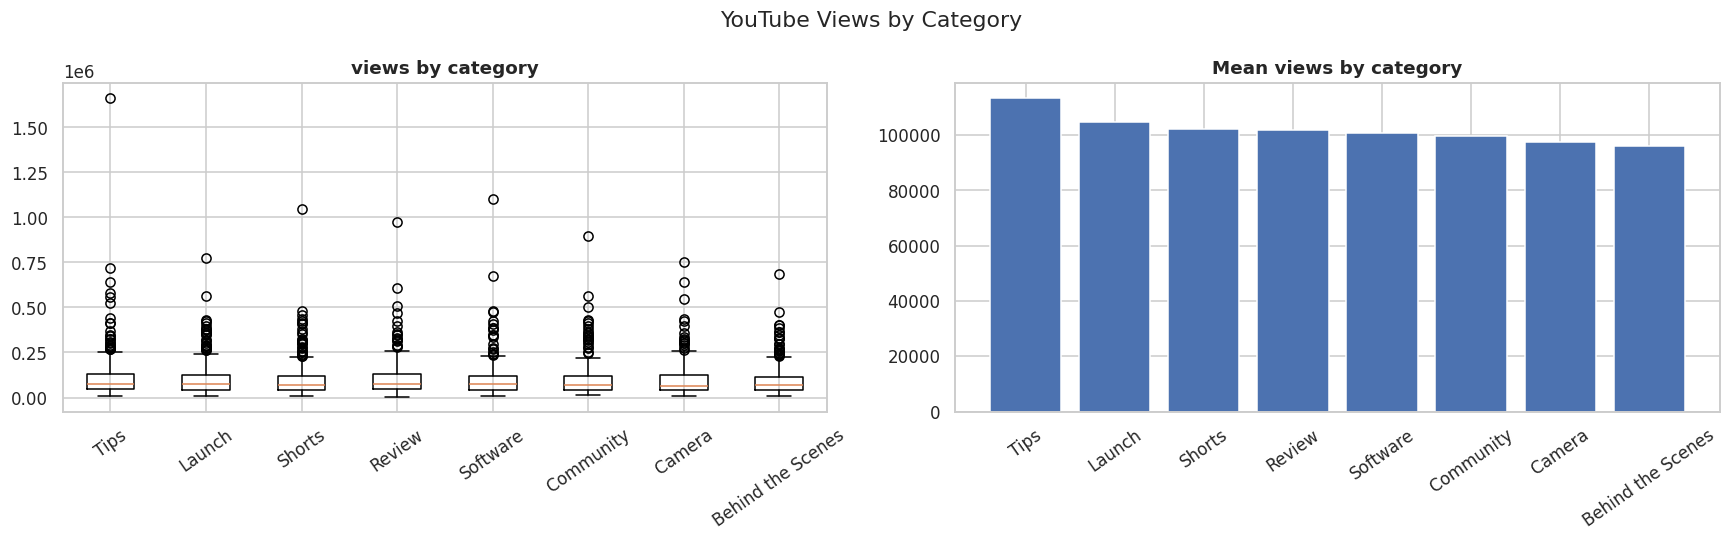

,count,mean,median
traffic_source,,,
Browse,498,430.586,266.500
External,518,428.359,289.000
Suggested,522,415.513,271.500
Search,442,407.869,262.000
Notifications,520,407.563,270.500


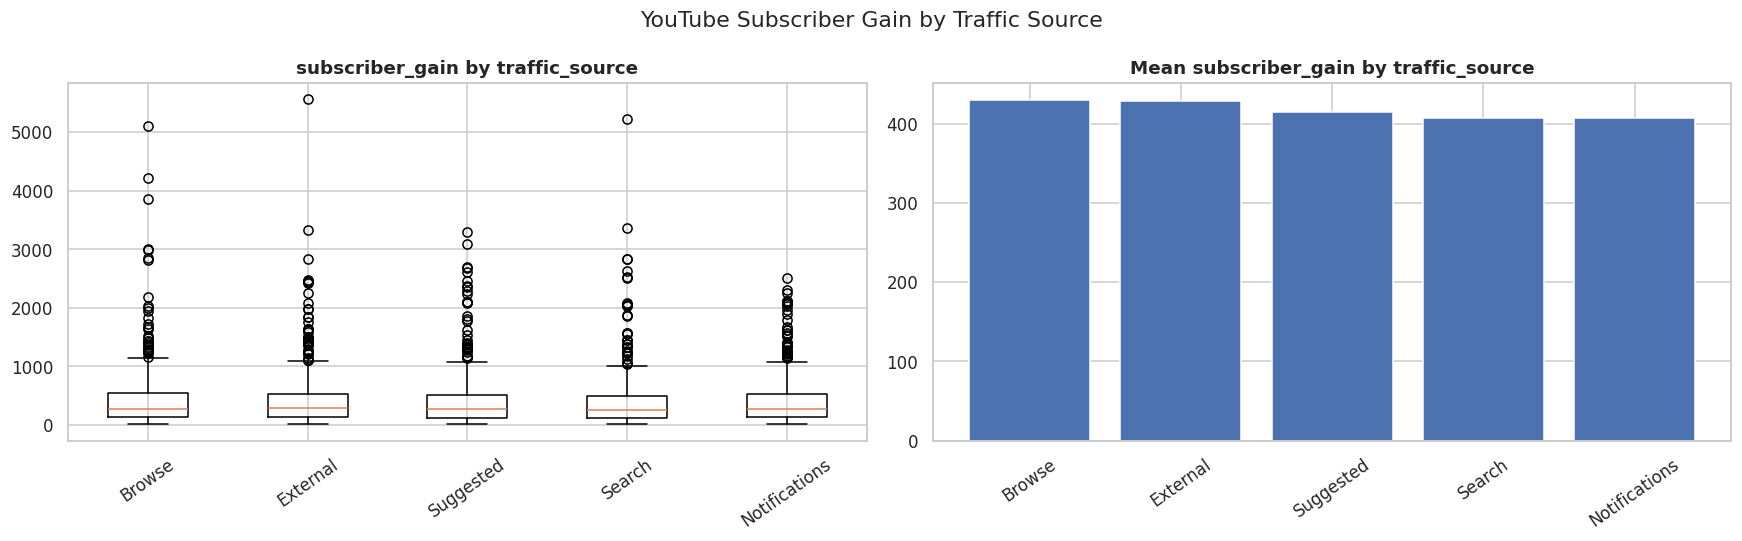

campaign,Behind the Scenes,Community,Feature Highlight,Festival,Giveaway,Launch,Photography,Software Update
media_type,,,,,,,,
Carousel,62,58,53,68,57,66,56,57
Image,97,61,63,81,81,77,64,91
Reel,178,181,162,196,160,172,181,178


campaign,Behind the Scenes,Community,Feature Highlight,Festival,Giveaway,Launch,Photography,Software Update
media_type,,,,,,,,
Carousel,13.000,12.160,11.110,14.260,11.950,13.840,11.740,11.950
Image,15.770,9.920,10.240,13.170,13.170,12.520,10.410,14.800
Reel,12.640,12.860,11.510,13.920,11.360,12.220,12.860,12.640


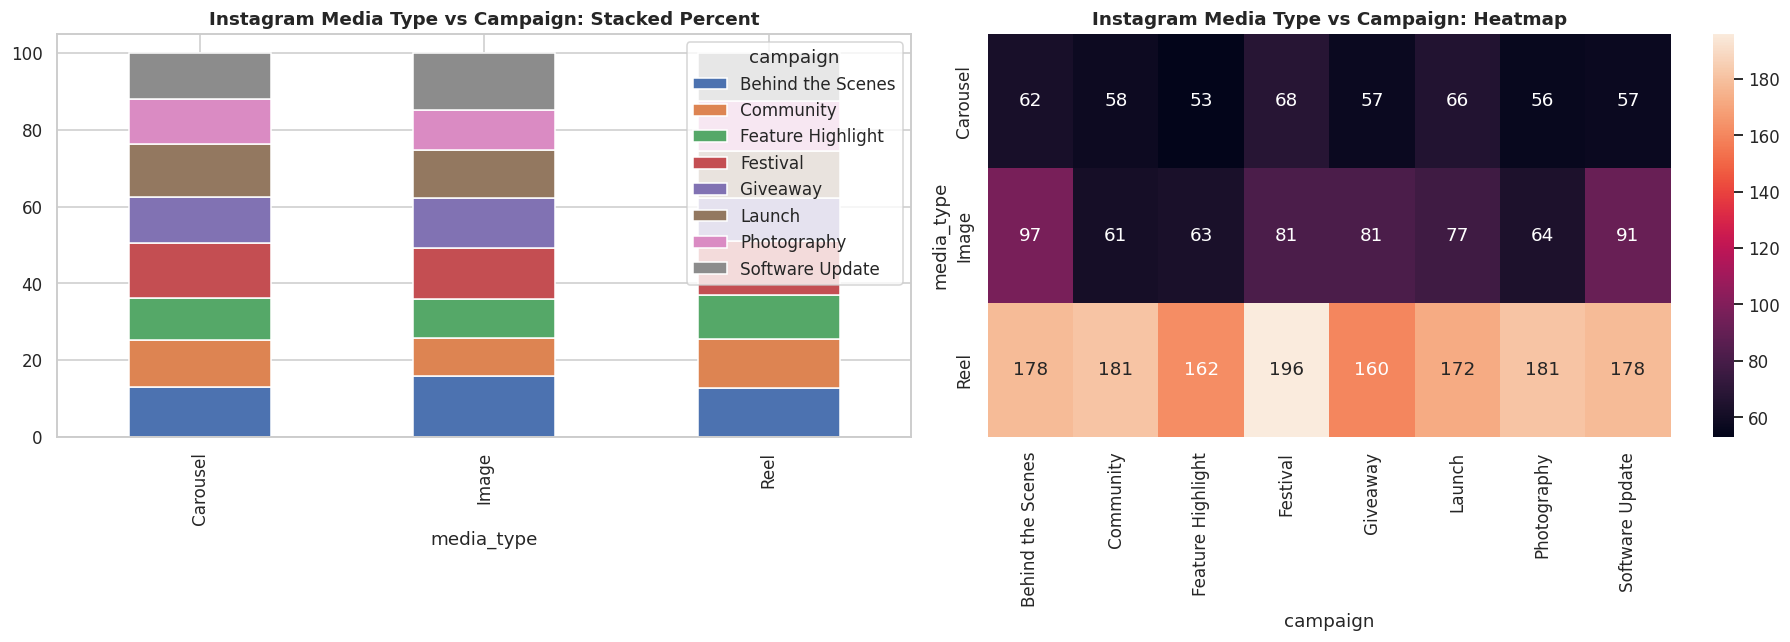

traffic_source,Browse,External,Notifications,Search,Suggested
category,,,,,
Behind the Scenes,75,65,61,62,63
Camera,58,58,89,51,61
Community,53,67,68,67,74
Launch,61,84,50,54,67
Review,78,65,62,60,68
Shorts,70,61,57,53,71
Software,49,65,64,48,63
Tips,54,53,69,47,55


traffic_source,Browse,External,Notifications,Search,Suggested
category,,,,,
Behind the Scenes,23.010,19.940,18.710,19.020,19.330
Camera,18.300,18.300,28.080,16.090,19.240
Community,16.110,20.360,20.670,20.360,22.490
Launch,19.300,26.580,15.820,17.090,21.200
Review,23.420,19.520,18.620,18.020,20.420
Shorts,22.440,19.550,18.270,16.990,22.760
Software,16.960,22.490,22.150,16.610,21.800
Tips,19.420,19.060,24.820,16.910,19.780


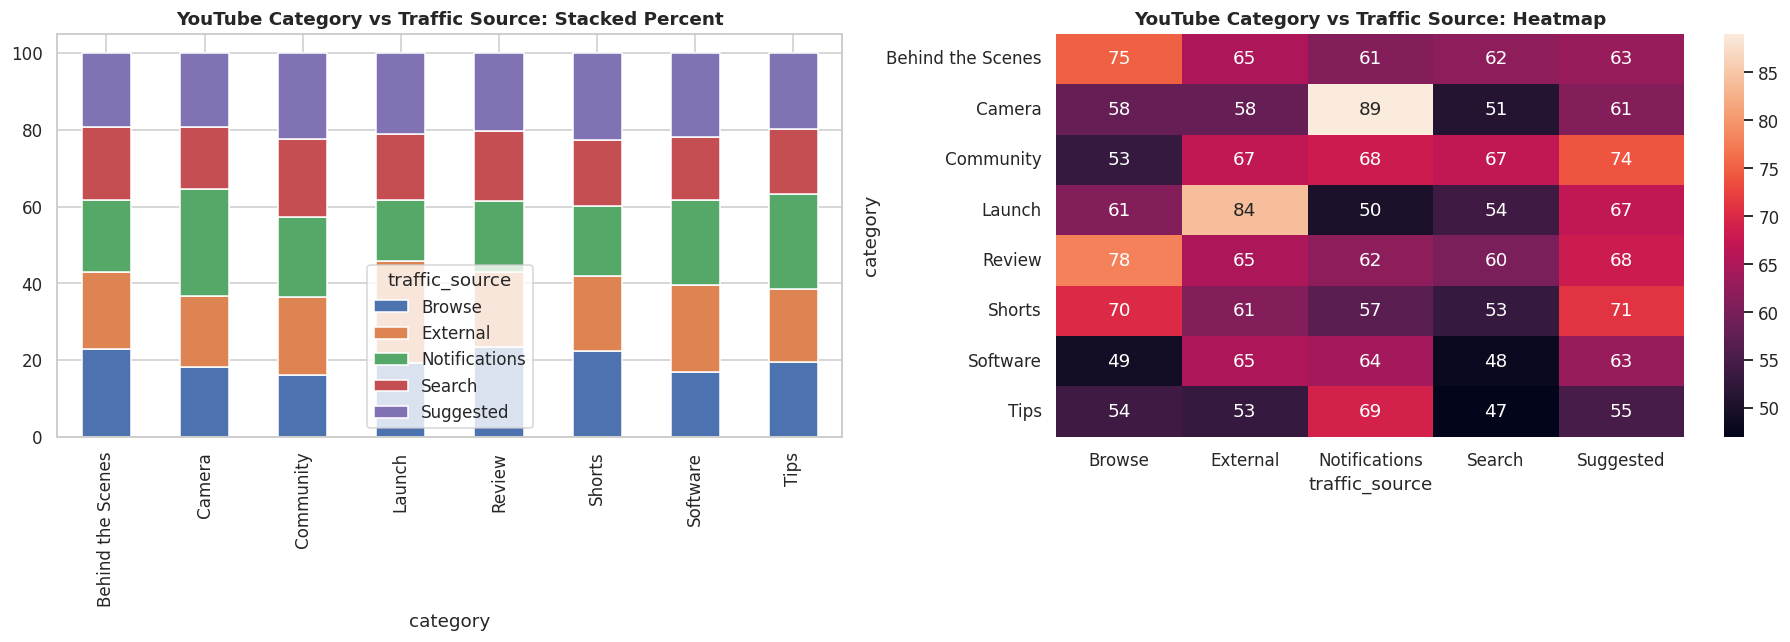

purchase_intent,High,Low,Medium
sentiment,,,
Negative,98,163,216
Neutral,156,207,261
Positive,431,660,808


purchase_intent,High,Low,Medium
sentiment,,,
Negative,20.550,34.170,45.280
Neutral,25.000,33.170,41.830
Positive,22.700,34.760,42.550


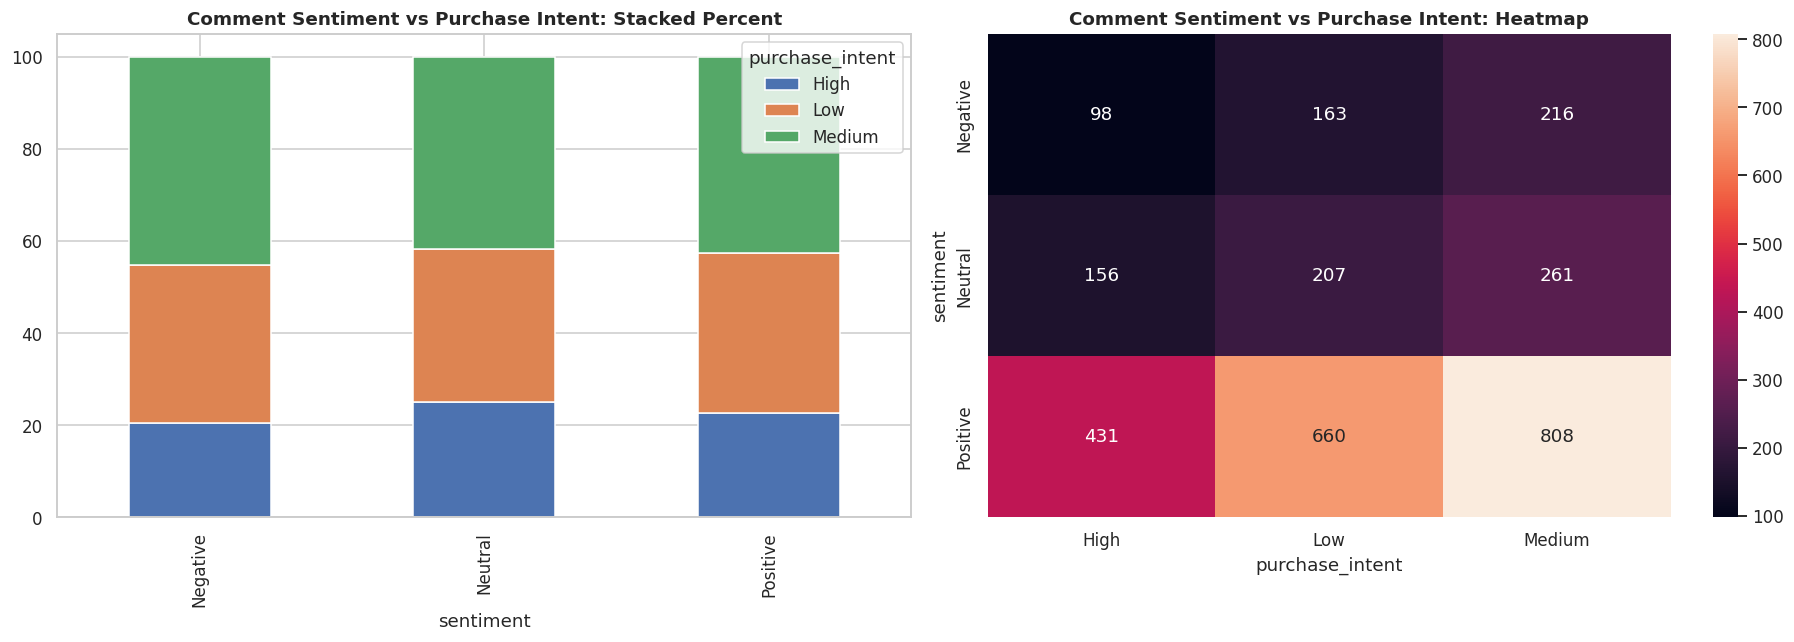

In [11]:
fig, axes = plt.subplots(2,2,figsize=(16,12))
axes[0,0].scatter(instagram_posts['reach'], instagram_posts['total_engagement'], alpha=.45)
axes[0,0].set_title('Instagram Reach vs Total Engagement')
axes[0,1].scatter(instagram_posts['impressions'], instagram_posts['reach'], alpha=.45)
axes[0,1].set_title('Instagram Impressions vs Reach')
axes[1,0].scatter(youtube['views'], youtube['subscriber_gain'], alpha=.45)
axes[1,0].set_title('YouTube Views vs Subscriber Gain')
axes[1,1].scatter(youtube['views'], youtube['estimated_revenue_usd'], alpha=.45)
axes[1,1].set_title('YouTube Views vs Estimated Revenue')
plt.tight_layout(); plt.show()

if RUN_HEAVY_PLOTS:
    instagram_pair_sample = instagram_posts[['reach','impressions','likes','comments','shares','saves','viral_score']].sample(min(600,len(instagram_posts)), random_state=RANDOM_SEED)
    pd.plotting.scatter_matrix(instagram_pair_sample, figsize=(15,15), diagonal='hist', alpha=0.35)
    plt.suptitle('Instagram Numerical Pair Plot', y=0.91)
    plt.show()

    youtube_pair_sample = youtube[['views','likes','comments','shares','subscriber_gain','estimated_revenue_usd','viral_score']].sample(min(600,len(youtube)), random_state=RANDOM_SEED)
    pd.plotting.scatter_matrix(youtube_pair_sample, figsize=(15,15), diagonal='hist', alpha=0.35)
    plt.suptitle('YouTube Numerical Pair Plot', y=0.91)
    plt.show()

def grouped_metric(df, category, metric, title):
    grouped = df.groupby(category, dropna=False)[metric].agg(['count','mean','median']).sort_values('mean', ascending=False)
    display(grouped)
    groups = [df.loc[df[category] == value, metric].dropna().values for value in grouped.index]
    fig, axes = plt.subplots(1,2,figsize=(16,5))
    axes[0].boxplot(groups, labels=grouped.index.astype(str))
    axes[0].set_title(f'{metric} by {category}')
    axes[0].tick_params(axis='x', rotation=35)
    axes[1].bar(grouped.index.astype(str), grouped['mean'])
    axes[1].set_title(f'Mean {metric} by {category}')
    axes[1].tick_params(axis='x', rotation=35)
    fig.suptitle(title); plt.tight_layout(); plt.show()

grouped_metric(instagram_posts, 'media_type', 'engagement_rate_calculated', 'Instagram Engagement by Media Type')
grouped_metric(instagram_posts, 'campaign', 'viral_score', 'Instagram Viral Score by Campaign')
grouped_metric(youtube, 'category', 'views', 'YouTube Views by Category')
grouped_metric(youtube, 'traffic_source', 'subscriber_gain', 'YouTube Subscriber Gain by Traffic Source')

def cat_relationship(df, row, column, title):
    table = pd.crosstab(df[row], df[column])
    pct = pd.crosstab(df[row], df[column], normalize='index') * 100
    display(table); display(pct.round(2))
    fig, axes = plt.subplots(1,2,figsize=(17,6))
    pct.plot(kind='bar', stacked=True, ax=axes[0])
    axes[0].set_title(title + ': Stacked Percent')
    sns.heatmap(table, annot=True, fmt='d', ax=axes[1])
    axes[1].set_title(title + ': Heatmap')
    plt.tight_layout(); plt.show()

cat_relationship(instagram_posts, 'media_type', 'campaign', 'Instagram Media Type vs Campaign')
cat_relationship(youtube, 'category', 'traffic_source', 'YouTube Category vs Traffic Source')
cat_relationship(instagram_comments, 'sentiment', 'purchase_intent', 'Comment Sentiment vs Purchase Intent')

## **12. Pearson, Spearman, and Multicollinearity Analysis**

In [ ]:
def correlation_analysis(df, columns, name):
    selected = df[[c for c in columns if c in df.columns]].select_dtypes(include=np.number)
    pearson = selected.corr('pearson')
    spearman = selected.corr('spearman')
    display(pearson.round(3)); display(spearman.round(3))
    fig, axes = plt.subplots(1,2,figsize=(20,8))
    sns.heatmap(pearson, annot=True, fmt='.2f', center=0, ax=axes[0]); axes[0].set_title(name + ': Pearson')
    sns.heatmap(spearman, annot=True, fmt='.2f', center=0, ax=axes[1]); axes[1].set_title(name + ': Spearman')
    plt.tight_layout(); plt.show()
    pairs = []
    for i, a in enumerate(pearson.columns):
        for b in pearson.columns[i+1:]:
            pairs.append((a,b,pearson.loc[a,b]))
    strong_pos = sorted([p for p in pairs if p[2] >= .70], key=lambda x:x[2], reverse=True)
    strong_neg = sorted([p for p in pairs if p[2] <= -.70], key=lambda x:x[2])
    weak = sorted([p for p in pairs if abs(p[2]) <= .20], key=lambda x:abs(x[2]))[:10]
    print('Strong positive correlations:'); display(pd.DataFrame(strong_pos, columns=['Feature_1','Feature_2','Correlation']))
    print('Strong negative correlations:'); display(pd.DataFrame(strong_neg, columns=['Feature_1','Feature_2','Correlation']))
    print('Weak correlation examples:'); display(pd.DataFrame(weak, columns=['Feature_1','Feature_2','Correlation']))
    return pearson, spearman

instagram_pearson, instagram_spearman = correlation_analysis(instagram_posts, ['reach','impressions','likes','comments','shares','saves','total_engagement','engagement_rate_calculated','viral_score','sentiment_score','posting_hour'], 'Instagram Posts')
youtube_pearson, youtube_spearman = correlation_analysis(youtube, ['duration_seconds','views','likes','comments','shares','watch_time_seconds','average_view_duration','audience_retention_percent','click_through_rate','subscriber_gain','estimated_revenue_usd','seo_score','total_engagement','engagement_rate_calculated','viral_score'], 'YouTube Videos')

print('Multicollinearity note: derived totals and their component metrics should not all be entered into an unregularized linear model. Exposure, watch time, engagement, subscribers, and revenue may also move together because of common scale effects.')

,reach,impressions,likes,comments,shares,saves,total_engagement,engagement_rate_calculated,viral_score,sentiment_score,posting_hour
reach,1.000,0.977,0.889,0.761,0.754,0.761,0.888,-0.319,0.283,0.002,-0.011
impressions,0.977,1.000,0.876,0.740,0.741,0.760,0.876,-0.305,0.284,-0.003,-0.015
likes,0.889,0.876,1.000,0.861,0.843,0.852,0.999,0.017,0.579,-0.002,-0.018
comments,0.761,0.740,0.861,1.000,0.709,0.716,0.864,0.020,0.504,0.022,-0.009
shares,0.754,0.741,0.843,0.709,1.000,0.716,0.856,0.042,0.512,0.005,-0.028
saves,0.761,0.760,0.852,0.716,0.716,1.000,0.870,0.038,0.501,-0.001,-0.016
total_engagement,0.888,0.876,0.999,0.864,0.856,0.870,1.000,0.020,0.580,-0.001,-0.019
engagement_rate_calculated,-0.319,-0.305,0.017,0.020,0.042,0.038,0.020,1.000,0.716,-0.010,-0.015
viral_score,0.283,0.284,0.579,0.504,0.512,0.501,0.580,0.716,1.000,-0.006,-0.010
sentiment_score,0.002,-0.003,-0.002,0.022,0.005,-0.001,-0.001,-0.010,-0.006,1.000,0.015


,reach,impressions,likes,comments,shares,saves,total_engagement,engagement_rate_calculated,viral_score,sentiment_score,posting_hour
reach,1.000,0.982,0.894,0.767,0.709,0.748,0.892,-0.412,0.100,0.019,0.005
impressions,0.982,1.000,0.879,0.754,0.697,0.739,0.878,-0.403,0.097,0.024,0.003
likes,0.894,0.879,1.000,0.854,0.803,0.836,0.999,0.007,0.455,0.012,-0.000
comments,0.767,0.754,0.854,1.000,0.689,0.719,0.859,0.015,0.396,0.021,0.004
shares,0.709,0.697,0.803,0.689,1.000,0.681,0.816,0.056,0.406,0.023,-0.006
saves,0.748,0.739,0.836,0.719,0.681,1.000,0.854,0.047,0.411,0.022,0.010
total_engagement,0.892,0.878,0.999,0.859,0.816,0.854,1.000,0.011,0.458,0.014,0.000
engagement_rate_calculated,-0.412,-0.403,0.007,0.015,0.056,0.047,0.011,1.000,0.706,-0.009,-0.015
viral_score,0.100,0.097,0.455,0.396,0.406,0.411,0.458,0.706,1.000,-0.000,-0.007
sentiment_score,0.019,0.024,0.012,0.021,0.023,0.022,0.014,-0.009,-0.000,1.000,0.012


## **13. Outlier Detection: IQR, Z-Score, and Box Plots**

In [ ]:
def outlier_report(df, columns):
    rows = []
    for c in columns:
        if c not in df.columns: continue
        v = df[c].dropna()
        if v.empty: continue
        q1, q3 = v.quantile([.25,.75]); iqr = q3-q1
        lower, upper = q1-1.5*iqr, q3+1.5*iqr
        iqr_mask = (df[c] < lower) | (df[c] > upper)
        idx = df[c].dropna().index
        z = pd.Series(np.abs(zscore(df.loc[idx,c], nan_policy='omit')), index=idx)
        z_mask = pd.Series(False, index=df.index); z_mask.loc[idx] = z > 3
        rows.append({'Feature':c,'IQR_Lower':lower,'IQR_Upper':upper,'IQR_Count':int(iqr_mask.sum()),'IQR_Percentage':round(iqr_mask.mean()*100,3),'Z_Count':int(z_mask.sum()),'Z_Percentage':round(z_mask.mean()*100,3)})
    return pd.DataFrame(rows).sort_values('IQR_Percentage', ascending=False)

instagram_outliers = outlier_report(instagram_posts, ['reach','impressions','likes','comments','shares','saves','total_engagement','engagement_rate_calculated','viral_score'])
youtube_outliers = outlier_report(youtube, ['views','likes','comments','shares','duration_seconds','watch_time_seconds','subscriber_gain','estimated_revenue_usd','engagement_rate_calculated','viral_score'])
print('Instagram outliers:'); display(instagram_outliers)
print('YouTube outliers:'); display(youtube_outliers)
fig, axes = plt.subplots(1,2,figsize=(16,6))
instagram_posts[['reach','impressions','total_engagement']].boxplot(ax=axes[0], grid=False); axes[0].set_title('Instagram Outliers')
youtube[['views','subscriber_gain','estimated_revenue_usd']].boxplot(ax=axes[1], grid=False); axes[1].set_title('YouTube Outliers')
plt.tight_layout(); plt.show()

print('Recommendation: keep valid viral-content outliers, remove only confirmed errors, use log transformation for skewed counts, Robust Scaling for scale-sensitive models, and calculate caps using training data only.')

## **14. Data Transformation and Scaling**

In [ ]:
transform = youtube[['views','likes','comments','shares','subscriber_gain','estimated_revenue_usd']].copy()
for c in transform.columns:
    transform['log1p_' + c] = np.log1p(transform[c].clip(lower=0))

fig, axes = plt.subplots(1,2,figsize=(15,5))
axes[0].hist(youtube['views'], bins=35); axes[0].set_title('Original YouTube Views')
axes[1].hist(transform['log1p_views'], bins=35); axes[1].set_title('Log-Transformed Views')
plt.tight_layout(); plt.show()

columns = ['views','likes','comments','shares','subscriber_gain','estimated_revenue_usd']
X = youtube[columns].fillna(youtube[columns].median())
minmax = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=['minmax_' + c for c in columns])
standard = pd.DataFrame(StandardScaler().fit_transform(X), columns=['standard_' + c for c in columns])
robust = pd.DataFrame(RobustScaler().fit_transform(X), columns=['robust_' + c for c in columns])
display(pd.concat([X.head(10).reset_index(drop=True), minmax.head(10), standard.head(10), robust.head(10)], axis=1))
print('Log1p handles strong right skew; square root handles moderate count skew; Min-Max maps to 0-1; Standardization gives zero mean/unit variance; Robust Scaling uses median/IQR and is less affected by outliers.')

## **15. Normality, QQ Plots, and Shapiro-Wilk Tests**

In [ ]:
def normality_table(df):
    rows = []
    for c in df.select_dtypes(include=np.number).columns:
        v = df[c].dropna()
        if len(v) < 3 or v.nunique() < 3:
            rows.append({'Feature':c,'Sample_Size':len(v),'Skewness':v.skew() if len(v) else np.nan,'Kurtosis':v.kurtosis() if len(v) else np.nan,'Shapiro_Statistic':np.nan,'Shapiro_P_Value':np.nan,'Normal_At_5_Percent':'Not testable'})
            continue
        sample = v.sample(min(5000,len(v)), random_state=RANDOM_SEED)
        stat, p = shapiro(sample)
        rows.append({'Feature':c,'Sample_Size':len(v),'Skewness':v.skew(),'Kurtosis':v.kurtosis(),'Shapiro_Statistic':stat,'Shapiro_P_Value':p,'Normal_At_5_Percent':'Yes' if p >= .05 else 'No'})
    return pd.DataFrame(rows).sort_values('Shapiro_P_Value')

def qq_all(df, name, per_page=9):
    columns = df.select_dtypes(include=np.number).columns.tolist()
    for start in range(0,len(columns),per_page):
        current = columns[start:start+per_page]
        rows = ceil(len(current)/3)
        fig, axes = plt.subplots(rows,3,figsize=(16,rows*4.4)); axes = np.array(axes).reshape(-1)
        for ax,c in zip(axes,current):
            v = df[c].dropna()
            if len(v) >= 3 and v.nunique() >= 3:
                sample = v.sample(min(2000,len(v)), random_state=RANDOM_SEED)
                probplot(sample, dist='norm', plot=ax); ax.set_title('QQ Plot: ' + c)
            else:
                ax.axis('off')
        for ax in axes[len(current):]: ax.axis('off')
        fig.suptitle(name + ' — QQ Plots', fontsize=16); plt.tight_layout(); plt.show()

instagram_normality = normality_table(instagram_posts)
youtube_normality = normality_table(youtube)
print('Instagram normality:'); display(instagram_normality)
print('YouTube normality:'); display(youtube_normality)
if RUN_HEAVY_PLOTS:
    qq_all(instagram_posts, 'Instagram Posts')
    qq_all(youtube, 'YouTube Videos')
print('For large samples, Shapiro-Wilk is highly sensitive. Interpret p-values with histograms, skewness, kurtosis, and QQ plots. Social-media count variables are commonly right-skewed rather than normal.')

## **16. Class-Imbalance Analysis**

In [ ]:
def class_imbalance(df, target, name):
    counts = df[target].value_counts(dropna=False)
    pct = counts / counts.sum() * 100
    ratio = counts.max() / counts.min() if counts.min() > 0 else np.inf
    print(name, 'target:', target)
    display(pd.DataFrame({'Count':counts,'Percentage':pct.round(3)}))
    print('Imbalance ratio:', round(ratio,3))
    plt.figure(figsize=(8,5)); plt.bar(counts.index.astype(str), counts.values); plt.title(f'{name}: {target} Class Distribution'); plt.xticks(rotation=25); plt.tight_layout(); plt.show()
    print('Use stratified splitting. When needed, apply class weights, Random Oversampling, Random Undersampling, or SMOTE to the training set only.')

class_imbalance(instagram_comments, 'sentiment', 'Instagram Comments')
class_imbalance(instagram_comments, 'purchase_intent', 'Instagram Comments')
class_imbalance(social_content, 'sentiment', 'Combined Social Content')

## **17. Location Analysis**

In [ ]:
def location_summary(df, location, engagement, name):
    summary = df.groupby(location, dropna=False).agg(Content_Count=(location,'size'),Average_Engagement=(engagement,'mean'),Total_Engagement=(engagement,'sum')).sort_values('Total_Engagement', ascending=False)
    display(summary)
    fig, axes = plt.subplots(1,2,figsize=(16,5))
    a = summary['Content_Count'].sort_values(); axes[0].barh(a.index.astype(str),a.values); axes[0].set_title(name + ': Content by Location')
    b = summary['Average_Engagement'].sort_values(); axes[1].barh(b.index.astype(str),b.values); axes[1].set_title(name + ': Average Engagement')
    plt.tight_layout(); plt.show()
    return summary

instagram_region_summary = location_summary(instagram_posts,'audience_region','total_engagement','Instagram')
comment_region_summary = location_summary(instagram_comments,'region','likes','Comments')
youtube_country_summary = location_summary(youtube,'country','total_engagement','YouTube')
print('Top Instagram location names:'); display(instagram_posts.groupby('location_name').agg(Posts=('post_id','count'),Average_Engagement=('total_engagement','mean')).sort_values('Posts',ascending=False).head(15))
print('Top YouTube location names:'); display(youtube.groupby('location_name').agg(Videos=('video_id','count'),Average_Engagement=('total_engagement','mean')).sort_values('Videos',ascending=False).head(15))

country_map = youtube.groupby('country',as_index=False).agg(Videos=('video_id','count'),Total_Views=('views','sum'),Average_Engagement_Rate=('engagement_rate_calculated','mean'))
fig = px.choropleth(country_map, locations='country', locationmode='country names', color='Total_Views', hover_name='country', hover_data=['Videos','Average_Engagement_Rate'], title='YouTube Total Views by Country')
fig.show()

heat = pd.pivot_table(instagram_posts,index='audience_region',columns='weekday',values='total_engagement',aggfunc='mean')
plt.figure(figsize=(12,5)); sns.heatmap(heat,annot=True,fmt='.0f'); plt.title('Instagram Average Engagement: Region x Weekday'); plt.tight_layout(); plt.show()
print('Latitude/longitude is not present, so a true point-level geo scatter or density map cannot be created. Country choropleth and categorical regional heatmaps are used instead.')

## **18. Text, Word, Hashtag, Mention, and Sentiment Analysis**

In [ ]:
CUSTOM_STOPWORDS = set(STOPWORDS).union({'nothing','phone','india','video','post','https','www','com','youtube','instagram','one','get','new'})

def tokens(series):
    text = ' '.join(series.fillna('').astype(str).tolist()).lower()
    words = re.findall(r"[a-zA-Z][a-zA-Z']{2,}", text)
    return [w for w in words if w not in CUSTOM_STOPWORDS]

def text_analysis(series, title):
    text = series.fillna('').astype(str)
    stats_frame = pd.DataFrame({'Word_Count':text.str.split().str.len(),'Character_Count':text.str.len()})
    display(stats_frame.describe().T)
    fig, axes = plt.subplots(1,2,figsize=(15,5))
    axes[0].hist(stats_frame['Word_Count'],bins=30); axes[0].set_title(title + ': Word Count')
    axes[1].hist(stats_frame['Character_Count'],bins=30); axes[1].set_title(title + ': Character Count')
    plt.tight_layout(); plt.show()
    freq = pd.DataFrame(Counter(tokens(series)).most_common(25),columns=['Word','Frequency'])
    display(freq)
    plt.figure(figsize=(10,7)); p=freq.sort_values('Frequency'); plt.barh(p['Word'],p['Frequency']); plt.title(title + ': Most Frequent Words'); plt.tight_layout(); plt.show()
    if WORDCLOUD_AVAILABLE and len(tokens(series)):
        cloud = WordCloud(width=1200,height=600,background_color='white',stopwords=CUSTOM_STOPWORDS,random_state=RANDOM_SEED).generate(' '.join(tokens(series)))
        plt.figure(figsize=(15,7)); plt.imshow(cloud,interpolation='bilinear'); plt.axis('off'); plt.title(title + ': Word Cloud'); plt.show()

text_analysis(instagram_posts['caption_clean'],'Instagram Captions')
text_analysis(instagram_comments['comment_text_clean'],'Instagram Comments')
text_analysis(youtube['combined_text'],'YouTube Text')

def split_values(series):
    output=[]
    for entry in series.fillna('').astype(str):
        output.extend([p.strip().lstrip('#@').lower() for p in re.split(r'[,\s]+',entry) if p.strip()])
    return Counter(output)

top_hashtags = pd.DataFrame(split_values(instagram_posts['hashtags']).most_common(25),columns=['Hashtag','Frequency'])
top_mentions = pd.DataFrame(split_values(instagram_posts['mentions']).most_common(25),columns=['Mentioned_Account','Frequency'])
display(top_hashtags); display(top_mentions)
fig, axes = plt.subplots(1,2,figsize=(17,7))
a=top_hashtags.head(15).sort_values('Frequency'); axes[0].barh(a['Hashtag'],a['Frequency']); axes[0].set_title('Most Common Hashtags')
b=top_mentions.head(15).sort_values('Frequency'); axes[1].barh(b['Mentioned_Account'],b['Frequency']); axes[1].set_title('Most Mentioned Accounts')
plt.tight_layout(); plt.show()

sent = instagram_comments['sentiment'].value_counts(); display(pd.DataFrame({'Count':sent,'Percentage':(sent/sent.sum()*100).round(2)}))
plt.figure(figsize=(8,5)); plt.bar(sent.index.astype(str),sent.values); plt.title('Comment Sentiment Distribution'); plt.tight_layout(); plt.show()
print('Top positive comments:'); display(instagram_comments[instagram_comments['sentiment']=='Positive'].nlargest(10,'likes')[['comment_text_clean','likes','emotion','topic','purchase_intent']])
print('Top negative comments:'); display(instagram_comments[instagram_comments['sentiment']=='Negative'].nlargest(10,'likes')[['comment_text_clean','likes','emotion','topic','complaint_category']])

positive_words={'good','great','love','best','amazing','excellent','beautiful','awesome','fast','improved','sharp','happy'}
negative_words={'bad','poor','worst','hate','problem','issue','slow','missing','expensive','broken','fail','disappointed'}
def lexicon_sentiment(text):
    w=re.findall(r"[a-zA-Z']+",str(text).lower()); score=sum(x in positive_words for x in w)-sum(x in negative_words for x in w)
    return 'Positive' if score>0 else 'Negative' if score<0 else 'Neutral'
youtube['approx_text_sentiment']=youtube['combined_text'].fillna('').map(lexicon_sentiment)
display(youtube['approx_text_sentiment'].value_counts().rename_axis('Sentiment').to_frame('Video_Count'))
print('YouTube sentiment is a simple lexicon demonstration and should be replaced with a validated domain-specific NLP model for production use.')

## **19. Hyperlink and Domain Analysis**

In [ ]:
URL_PATTERN = re.compile(r'https?://[^\s)\]>]+')
def extract_urls(text): return URL_PATTERN.findall(str(text))
def domain(url):
    try: return urlparse(url).netloc.lower().replace('www.','')
    except Exception: return 'invalid'

def hyperlink_analysis(df,text_column,url_column,engagement,name):
    x=df.copy(); x['text_urls']=x[text_column].fillna('').map(extract_urls); x['text_url_count']=x['text_urls'].map(len); x['has_text_url']=x['text_url_count']>0; x['primary_domain']=x[url_column].fillna('').map(domain)
    print(name, '- rows with text URLs:', int(x['has_text_url'].sum()), '- percentage:', round(x['has_text_url'].mean()*100,2))
    all_urls=[u for group in x['text_urls'] for u in group]
    domain_freq=pd.DataFrame(Counter(domain(u) for u in all_urls).most_common(),columns=['Domain','Frequency']); display(domain_freq.head(20))
    summary=x.groupby('primary_domain').agg(Content_Count=(url_column,'count'),Average_Engagement=(engagement,'mean'),Total_Engagement=(engagement,'sum')).sort_values('Total_Engagement',ascending=False); display(summary)
    return x,domain_freq,summary

instagram_link_data,instagram_domains,instagram_domain_summary=hyperlink_analysis(instagram_posts,'caption_original','post_url','total_engagement','Instagram Posts')
youtube_link_data,youtube_domains,youtube_domain_summary=hyperlink_analysis(youtube,'description_original','video_url','total_engagement','YouTube Videos')
comment_link_data,comment_domains,comment_domain_summary=hyperlink_analysis(instagram_comments,'comment_text_clean','post_url','likes','Instagram Comments')

## **20. Engagement, Top Content, Best Hour, Best Day, Location, and Hashtag Performance**

In [ ]:
def engagement_stats(df,column,name):
    v=df[column]
    display(pd.DataFrame({'Metric':['Total','Mean','Median','Standard Deviation','Minimum','Maximum','Q1','Q3','IQR'],'Value':[v.sum(),v.mean(),v.median(),v.std(),v.min(),v.max(),v.quantile(.25),v.quantile(.75),v.quantile(.75)-v.quantile(.25)]}))
    print(name)

engagement_stats(instagram_posts,'total_engagement','Instagram Engagement Statistics')
engagement_stats(youtube,'total_engagement','YouTube Engagement Statistics')
print('Top Instagram posts:'); display(instagram_posts.nlargest(15,'total_engagement')[['post_id','media_type','campaign','product','caption_clean','reach','likes','comments','shares','saves','total_engagement','engagement_rate_calculated','posting_hour','weekday']])
print('Top YouTube videos:'); display(youtube.nlargest(15,'total_engagement')[['video_id','title','category','product','views','likes','comments','shares','total_engagement','subscriber_gain','estimated_revenue_usd','upload_hour','weekday']])

instagram_hour=instagram_posts.groupby('posting_hour').agg(Posts=('post_id','count'),Average_Engagement=('total_engagement','mean'),Average_Rate=('engagement_rate_calculated','mean'))
youtube_hour=youtube.groupby('upload_hour').agg(Videos=('video_id','count'),Average_Engagement=('total_engagement','mean'),Average_Views=('views','mean'))
instagram_day=instagram_posts.groupby('weekday').agg(Posts=('post_id','count'),Average_Engagement=('total_engagement','mean'),Average_Rate=('engagement_rate_calculated','mean')).sort_values('Average_Engagement',ascending=False)
youtube_day=youtube.groupby('weekday').agg(Videos=('video_id','count'),Average_Engagement=('total_engagement','mean'),Average_Views=('views','mean')).sort_values('Average_Engagement',ascending=False)
display(instagram_hour.sort_values('Average_Engagement',ascending=False)); display(youtube_hour.sort_values('Average_Engagement',ascending=False)); display(instagram_day); display(youtube_day)
fig,axes=plt.subplots(2,2,figsize=(17,11))
axes[0,0].plot(instagram_hour.index,instagram_hour['Average_Engagement'],marker='o'); axes[0,0].set_title('Instagram Engagement by Hour')
axes[0,1].plot(youtube_hour.index,youtube_hour['Average_Engagement'],marker='o'); axes[0,1].set_title('YouTube Engagement by Hour')
a=instagram_day.sort_values('Average_Engagement'); axes[1,0].barh(a.index.astype(str),a['Average_Engagement']); axes[1,0].set_title('Instagram Engagement by Day')
b=youtube_day.sort_values('Average_Engagement'); axes[1,1].barh(b.index.astype(str),b['Average_Engagement']); axes[1,1].set_title('YouTube Engagement by Day')
plt.tight_layout(); plt.show()

rows=[]
for _,r in instagram_posts.iterrows():
    for h in re.split(r'[,\s]+',str(r.get('hashtags',''))):
        h=h.strip().lstrip('#').lower()
        if h: rows.append({'hashtag':h,'engagement':r['total_engagement']})
hashtag_engagement=pd.DataFrame(rows)
if not hashtag_engagement.empty:
    hashtag_performance=hashtag_engagement.groupby('hashtag').agg(Uses=('engagement','count'),Average_Engagement=('engagement','mean'),Total_Engagement=('engagement','sum')).query('Uses >= 3').sort_values('Average_Engagement',ascending=False)
    display(hashtag_performance.head(25))

## **21. Statistical Hypothesis Tests**

In [ ]:
ALPHA=.05
promoted=instagram_posts.loc[instagram_posts['is_promoted']==True,'engagement_rate_calculated'].dropna()
organic=instagram_posts.loc[instagram_posts['is_promoted']==False,'engagement_rate_calculated'].dropna()
if len(promoted)>=2 and len(organic)>=2:
    t,p=stats.ttest_ind(promoted,organic,equal_var=False)
    print("Welch's t-test: promoted vs non-promoted Instagram engagement")
    print('t=',round(t,4),'p=',round(p,6),'Conclusion:', 'Reject H0' if p<ALPHA else 'Fail to reject H0')

groups=[g['views'].dropna().values for _,g in youtube.groupby('category') if len(g)>=2]
f,p=stats.f_oneway(*groups)
print('\nOne-way ANOVA: YouTube views across categories')
print('F=',round(f,4),'p=',round(p,6),'Conclusion:', 'Reject H0' if p<ALPHA else 'Fail to reject H0')

table=pd.crosstab(instagram_comments['sentiment'],instagram_comments['purchase_intent'])
chi,p,dof,expected=stats.chi2_contingency(table)
print('\nChi-square: comment sentiment vs purchase intent')
print('Chi-square=',round(chi,4),'p=',round(p,6),'dof=',dof,'Conclusion:', 'Reject H0' if p<ALPHA else 'Fail to reject H0')
display(table)

## **22. Visual Dashboard**

In [ ]:
platform_summary=instagram_youtube_combined.groupby('platform').agg(Content_Count=('content_id','count'),Total_Exposure=('views_or_reach','sum'),Total_Engagement=('total_engagement','sum'),Average_Engagement_Rate=('engagement_rate_pct','mean'),Average_Viral_Score=('viral_score','mean'))
display(platform_summary)
product_summary=instagram_youtube_combined.groupby(['platform','product']).agg(Content_Count=('content_id','count'),Total_Engagement=('total_engagement','sum'),Average_Engagement_Rate=('engagement_rate_pct','mean')).reset_index()
fig,axes=plt.subplots(2,3,figsize=(19,12))
axes[0,0].bar(platform_summary.index,platform_summary['Content_Count']); axes[0,0].set_title('Content Count')
axes[0,1].bar(platform_summary.index,platform_summary['Total_Exposure']); axes[0,1].set_title('Total Reach/Views')
axes[0,2].bar(platform_summary.index,platform_summary['Total_Engagement']); axes[0,2].set_title('Total Engagement')
axes[1,0].bar(platform_summary.index,platform_summary['Average_Engagement_Rate']); axes[1,0].set_title('Average Engagement Rate')
axes[1,1].bar(platform_summary.index,platform_summary['Average_Viral_Score']); axes[1,1].set_title('Average Viral Score')
pivot=product_summary.pivot(index='product',columns='platform',values='Average_Engagement_Rate').fillna(0); pivot.plot(kind='bar',ax=axes[1,2]); axes[1,2].set_title('Engagement Rate by Product and Platform'); axes[1,2].tick_params(axis='x',rotation=35)
fig.suptitle('Nothing Social Media EDA Dashboard',fontsize=20,fontweight='bold'); plt.tight_layout(); plt.show()

sample=instagram_youtube_combined.sample(min(1500,len(instagram_youtube_combined)),random_state=RANDOM_SEED)
fig=px.scatter(sample,x='views_or_reach',y='total_engagement',color='platform',size='viral_score',hover_data=['content_id','content_type','product','engagement_rate_pct','weekday'],log_x=True,log_y=True,title='Interactive Exposure vs Engagement')
fig.show()

## **23. Automatically Generated Key Insights**

In [ ]:
best_ig_media=instagram_posts.groupby('media_type')['engagement_rate_calculated'].mean().idxmax()
best_ig_campaign=instagram_posts.groupby('campaign')['total_engagement'].mean().idxmax()
best_ig_hour=instagram_hour['Average_Engagement'].idxmax()
best_ig_day=instagram_day['Average_Engagement'].idxmax()
top_ig_region=instagram_region_summary['Total_Engagement'].idxmax()
best_yt_category=youtube.groupby('category')['views'].mean().idxmax()
best_yt_source=youtube.groupby('traffic_source')['subscriber_gain'].mean().idxmax()
best_yt_hour=youtube_hour['Average_Engagement'].idxmax()
best_yt_day=youtube_day['Average_Engagement'].idxmax()
top_yt_country=youtube_country_summary['Total_Engagement'].idxmax()
top_topic=instagram_comments['topic'].value_counts().idxmax()
negative_share=(instagram_comments['sentiment']=='Negative').mean()*100
high_intent=(instagram_comments['purchase_intent']=='High').mean()*100

insights=[
    f'Instagram contains {len(instagram_posts):,} posts and YouTube contains {len(youtube):,} videos.',
    f'Best Instagram media type by average calculated engagement rate: {best_ig_media}.',
    f'Best Instagram campaign by average total engagement: {best_ig_campaign}.',
    f'Best Instagram posting hour: approximately {best_ig_hour}:00.',
    f'Best Instagram weekday: {best_ig_day}.',
    f'Instagram region with highest total engagement: {top_ig_region}.',
    f'YouTube category with highest average views: {best_yt_category}.',
    f'YouTube traffic source with highest average subscriber gain: {best_yt_source}.',
    f'Best YouTube upload hour: approximately {best_yt_hour}:00.',
    f'Best YouTube weekday: {best_yt_day}.',
    f'YouTube country with highest total engagement: {top_yt_country}.',
    f'Most frequent comment topic: {top_topic}.',
    f'Negative comments: {negative_share:.2f}%.',
    f'High purchase-intent comments: {high_intent:.2f}%.',
    'Count metrics are right-skewed and contain valid viral-content outliers.',
    'Completely missing fields should be marked Unknown or excluded rather than statistically invented.',
    'Correlation among exposure, engagement, subscribers, and revenue does not prove causation.'
]
for item in insights: print('•',item)

## **24. Recommendations**

### Data Cleaning
- Maintain a formal data dictionary and metric formula for every platform.
- Reconcile duplicated fields such as `likes` and `likes_count`.
- Mark fully unavailable information as `Unknown`; do not convert it to zero.
- Validate dates, hours, rates, probabilities, and non-negative count fields.
- Review future synthetic timestamps.

### Feature Engineering and Selection
- Retain audited calculated engagement-rate features.
- Use per-1,000-view/reach metrics for fair comparison.
- Add rolling 7-day and 30-day metrics for chronological analysis.
- Avoid using component engagement counts and their exact total together in unregularized linear models.
- Exclude identifiers and raw URLs from most predictive models.

### Model Building
- Use time-based splits for forecasting and stratified splits for classification.
- Apply SMOTE or oversampling only to training data.
- Compare interpretable baselines with tree-based models.
- Use SHAP or permutation importance.

### Additional Data Collection
- Ad spend, clicks, conversions, and attributed revenue
- Exact latitude and longitude
- Follower growth before and after each post
- Comment response time and resolution outcome
- Full audience-retention curves
- Creative attributes such as colour, face presence, product visibility, and audio type

### Business Actions
- Test schedules around the strongest hours and weekdays.
- Adapt high-performing formats separately for Instagram and YouTube.
- Prioritize topics combining engagement and high purchase intent.
- Monitor negative topics and complaint categories after launches.
- Optimize YouTube metadata for traffic sources linked to subscriber growth.
- Evaluate reach, engagement quality, clicks, conversion, and revenue together.

## **25. Conclusion**

The uploaded Nothing datasets are rich enough for descriptive, behavioural, text, location, and engagement analysis. Data quality is generally strong, but structural missingness, fully unavailable fields, duplicated source metrics, and future synthetic timestamps require documented handling.

After cleaning, the data is ready for EDA. Machine-learning use requires a clearly defined target, removal of leakage and redundant variables, transformation of skewed metrics, time-aware or stratified validation, and class balancing only within training data.

Recommended next analyses include content-performance prediction, sentiment and purchase-intent classification, launch-response monitoring, campaign ROI modelling, and posting-time optimization.

## **26. Export Cleaned and Engineered Data**

In [ ]:
output_dir=Path('/content') if Path('/content').exists() else Path('/mnt/data')
output_dir.mkdir(parents=True,exist_ok=True)
exports={
    'Instagram Posts':output_dir/'nothing_instagram_posts_cleaned.csv',
    'Instagram Comments':output_dir/'nothing_instagram_comments_cleaned.csv',
    'YouTube Videos':output_dir/'nothing_youtube_videos_cleaned.csv',
    'Instagram YouTube Combined':output_dir/'nothing_instagram_youtube_combined.csv',
    'Social Content':output_dir/'nothing_social_content_cleaned.csv',
    'Instagram Outliers':output_dir/'instagram_outlier_report.csv',
    'YouTube Outliers':output_dir/'youtube_outlier_report.csv',
    'Instagram Normality':output_dir/'instagram_normality_report.csv',
    'YouTube Normality':output_dir/'youtube_normality_report.csv'
}
instagram_posts.to_csv(exports['Instagram Posts'],index=False)
instagram_comments.to_csv(exports['Instagram Comments'],index=False)
youtube.to_csv(exports['YouTube Videos'],index=False)
instagram_youtube_combined.to_csv(exports['Instagram YouTube Combined'],index=False)
social_content.to_csv(exports['Social Content'],index=False)
instagram_outliers.to_csv(exports['Instagram Outliers'],index=False)
youtube_outliers.to_csv(exports['YouTube Outliers'],index=False)
instagram_normality.to_csv(exports['Instagram Normality'],index=False)
youtube_normality.to_csv(exports['YouTube Normality'],index=False)
for name,path in exports.items(): print(name,':',path)
print('In Google Colab, use files.download(str(path)) to download any exported file.')